# Determinación de parámetros mediante física


## Inicialización

Librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# import emcee  # el posterior es 1D: se evalua en una grilla, no hace falta MCMC

## Circulo

In [2]:
def choice_circle_points(N, R=1, r0=0, theta0=0, distribution='uniform', seed=None, returns='cartesian'):
    """
    Generate N points on a circle of radius R, centered at (r0, theta0) in polar coordinates.
    
    Parameters:
    - N: Number of points to generate.
    - R: Radius of the circle (default is 1).
    - r0: Radial offset (default is 0).
    - theta0: Angular offset in radians (default is 0).
    - distribution: Type of distribution ('uniform' or 'normal').
    - seed: Random seed for reproducibility (default is None).
    - returns: Type of return values ('cartesian' or 'polar').
    
    Returns:
    - If returns='cartesian': A tuple of arrays (x, y) representing the Cartesian coordinates of the points.
    - If returns='polar': A tuple of arrays (r, theta) representing the polar coordinates of the points.
    """
    
    if seed is not None:
        np.random.seed(seed)
    
    if distribution == 'uniform':
        theta = np.random.uniform(0, 2 * np.pi, N)
        r = np.full(N, R)
    elif distribution == 'normal':
        theta = np.random.normal(theta0, 0.1, N)  # Small spread around theta0
        r = np.random.normal(R, 0.1, N)  # Small spread around R
    else:
        raise ValueError("Invalid distribution type. Choose 'uniform' or 'normal'.")

    # order theta
    theta = np.sort(theta)
    
    # Apply offsets
    r += r0
    theta += theta0
    
    if returns == 'cartesian':
        x = r * np.cos(theta)
        y = r * np.sin(theta)
        return x, y
    elif returns == 'polar':
        return r, theta
    else:
        raise ValueError("Invalid return type. Choose 'cartesian' or 'polar'.")

In [3]:
def plot_circle(R, r0=0, theta0=0, color='k', linewidth=0.5, label=None):
    thetas = np.linspace(0, 2 * np.pi, 100)
    r = np.full_like(thetas, R)
    x = r * np.cos(thetas) + r0 * np.cos(theta0)
    y = r * np.sin(thetas) + r0 * np.sin(theta0)
    plt.plot(x, y, '-', c=color, linewidth=linewidth, label=label)

(np.float64(-1.0994713695023444),
 np.float64(1.0999748271191592),
 np.float64(-1.0998615404412626),
 np.float64(1.0998615404412626))

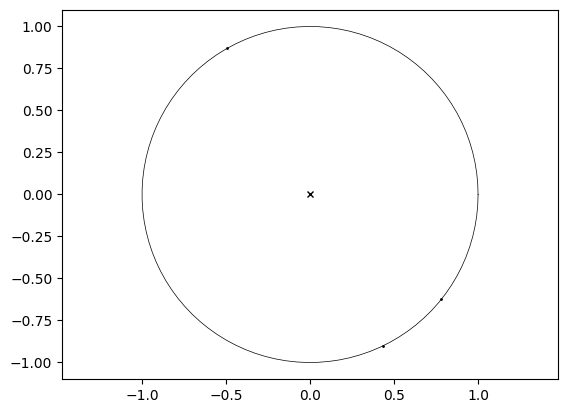

In [4]:
plot_circle(1)
plt.plot(*choice_circle_points(3, R=1, distribution='uniform', seed=6, returns='cartesian'), 'ok', markersize=1)
plt.plot(0,0, 'xk', markersize=5)
plt.axis('equal')

Asumamos que tienen una distribución de error cualquiera, en este caso, gaussiana isotrópica

In [5]:

def plot_error(sigma, r0=0, theta0=0, color='gray', linewidth=0.2, label=None):
    thetas = np.linspace(0, 2 * np.pi, 100)
    r = np.full_like(thetas, 2.54*sigma)
    x = r * np.cos(thetas) + r0 * np.cos(theta0)
    y = r * np.sin(thetas) + r0 * np.sin(theta0)
    plt.plot(x, y, '-', c=color, linewidth=linewidth, label=label)

(np.float64(-1.0994713695023444),
 np.float64(1.0999748271191592),
 np.float64(-1.1299144067048257),
 np.float64(1.1012926293109562))

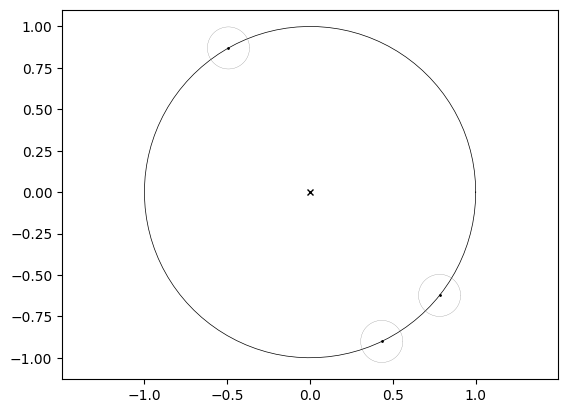

In [6]:
sigma_proper = 0.05

choiced_points_cartesian = choice_circle_points(3, R=1, distribution='uniform', seed=6, returns='cartesian')
choiced_points_polar = choice_circle_points(3, R=1, distribution='uniform', seed=6, returns='polar')
plot_circle(1)
plt.plot(*choiced_points_cartesian, 'ok', markersize=1)

for r, theta in zip(*choiced_points_polar):
    plot_error(sigma_proper, r0=r, theta0=theta)

plt.plot(0,0, 'xk', markersize=5)
plt.axis('equal')

In [7]:
def distribution_gaussian_isotropic(x, y, sigma, x0=0, y0=0):
    """
    Calculate the value of a 2D isotropic Gaussian distribution at point (x, y).

    Parameters:
    - x: x-coordinate
    - y: y-coordinate
    - sigma: standard deviation of the Gaussian
    - x0, y0: center of the Gaussian

    Returns:
    - Value of the Gaussian distribution at (x, y)
    """
    return (1 / (2 * np.pi * sigma**2)) * np.exp(-((x - x0)**2 + (y - y0)**2) / (2 * sigma**2))

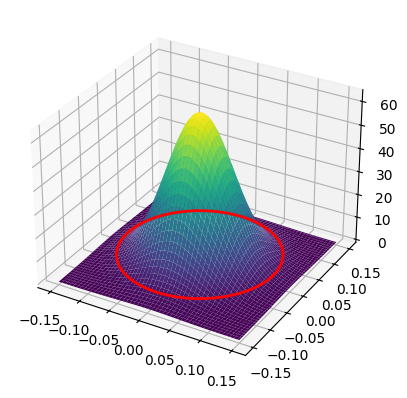

In [8]:
# plot en 3D de la distribución gaussiana isotrópica
abs_x = 3 * sigma_proper
abs_y = 3 * sigma_proper
x = np.linspace(-abs_x, abs_x, 100)
y = np.linspace(-abs_y, abs_y, 100)
X, Y = np.meshgrid(x, y)
Z = distribution_gaussian_isotropic(X, Y, sigma_proper)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, cmap='viridis')

# anillo donde está 2.45*sigma_proper (95% de confianza) a la altura de la distribución gaussiana isotrópica
# se eleva levemente sobre la superficie para evitar que plot_surface lo tape (z-order de mplot3d)
theta = np.linspace(0, 2 * np.pi, 100)
x_circle = 2.45 * sigma_proper * np.cos(theta)
y_circle = 2.45 * sigma_proper * np.sin(theta)
z_circle = distribution_gaussian_isotropic(x_circle, y_circle, sigma_proper) + Z.max() * 0.01
ax.plot(x_circle, y_circle, z_circle, color='r', linewidth=2, zorder=10)

For a circular Keplerian orbit,

$$
P = 2\pi \sqrt{\frac{a^3}{GM}}
$$

Taking

$$
a=1,\qquad G=1,\qquad M=1
$$

the orbital period is

$$
P = 2\pi
$$

The angular velocity is related to the period by

$$
\omega = \frac{2\pi}{P}
$$

therefore,

$$
\omega = 1
$$

For an angular displacement $\Delta\theta$,

$$
\Delta\theta = \omega,\Delta t
$$

and hence,

$$
\Delta t = \frac{\Delta\theta}{\omega}
$$


In [9]:
ts = np.linspace(0, 2 * np.pi, 100)
xs_obs, ys_obs, ts_obs = np.zeros((3,3))
theta_obs = np.zeros(3)
seed = 6
for point in range(3):
    x, y = choiced_points_cartesian[0][point], choiced_points_cartesian[1][point]
    t = np.arctan2(y, x) 
    t = t if t >= 0 else t + 2 * np.pi
    xs_obs[point] = np.random.normal(x, sigma_proper)
    ys_obs[point] = np.random.normal(y, sigma_proper)
    ts_obs[point] = t
    theta_obs[point] = np.arctan2(ys_obs[point], xs_obs[point])
    theta_obs[point] = theta_obs[point] if theta_obs[point] >= 0 else theta_obs[point] + 2 * np.pi

r_obs = np.sqrt(xs_obs**2 + ys_obs**2)

(np.float64(-1.0994713695023444),
 np.float64(1.0999748271191592),
 np.float64(-1.1823453626659064),
 np.float64(1.2279815491078172))

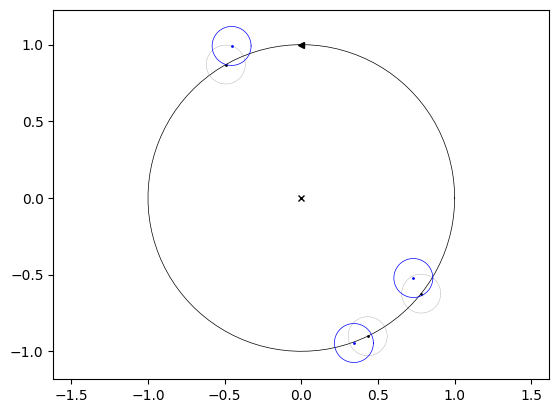

In [10]:
sigma_proper = 0.05

choiced_points_cartesian = choice_circle_points(3, R=1, distribution='uniform', seed=6, returns='cartesian')
choiced_points_polar = choice_circle_points(3, R=1, distribution='uniform', seed=6, returns='polar')
plot_circle(1)
plt.plot(*choiced_points_cartesian, 'ok', markersize=1)

for r, theta in zip(*choiced_points_polar):
    plot_error(sigma_proper, r0=r, theta0=theta)

plt.plot(xs_obs, ys_obs, 'ob', markersize=1)
for r, theta in zip(r_obs, theta_obs):
    plot_error(sigma_proper, r0=r, theta0=theta, color='blue', linewidth=0.5)

# start
plt.plot(0,1, '<k', markersize=5)

plt.plot(0,0, 'xk', markersize=5)
plt.axis('equal')

En este sentido, la distribución de probabilidad, theta y r es:
$$
p_{R,\Theta}(r,\theta)
=
\frac{r}{2\pi\sigma^2}
\exp\left[
-\frac{
r^2+r_0^2-2rr_0\cos(\theta-\theta_0)
}{
2\sigma^2
}
\right],
\qquad
r\geq 0.
$$

In [11]:
def distribution_gaussian_isotropic_polares(r, theta, r0=0, theta0=0, sigma=1):
    """
    Calculate the value of a 2D isotropic Gaussian distribution in polar coordinates.
    
    Parameters:
    - r: radial coordinate
    - theta: angular coordinate (not used in calculation since it's isotropic)
    - sigma: standard deviation of the Gaussian
    
    Returns:
    - Value of the Gaussian distribution at (r, theta)
    """
    return (1 / (2 * np.pi * sigma**2)) * np.exp(-(r**2 + r0**2 - 2 * r * r0 * np.cos(theta - theta0)) / (2 * sigma**2))

For a circular orbit,

$$
L_z = \rho^2\dot{\theta}
$$

Since

$$
\rho = a
$$

and

$$
\dot{\theta} = \omega = \sqrt{\frac{GM}{a^3}},
$$

then

$$
L_z = a^2\sqrt{\frac{GM}{a^3}}
$$

Therefore,

$$
L_z = \sqrt{GMa}.
$$

Taking

$$
G=M=1,
$$

we obtain

$$
L_z = \sqrt{a}.
$$




De este modo, podemos tener un estimador para $L_z$ a partir de las distribuciones de probabilidad de $x$ y $y$, que asu vez derivan de las distribuciones de probabilidad de $r$ y $\theta$.

La probabilidad de $a$ en general, será resultado de la probabilidad marginal de $r$. Podría ser analítica o en general, numérica. 

$$
\begin{align*}
& x = a \cos(\theta) \\
& y = a \sin(\theta)
\end{align*}
$$

Dado que:
$$
dx dy = |J| da d\theta
$$

y el jacobiano es:

$$
\begin{align*}
J &= \begin{bmatrix}
\frac{\partial x}{\partial a} & \frac{\partial x}{\partial \theta} \\
\frac{\partial y}{\partial a} & \frac{\partial y}{\partial \theta}
\end{bmatrix}\\
&=
\begin{bmatrix}
\cos(\theta) & -a \sin(\theta) \\
\sin(\theta) & a \cos(\theta)
\end{bmatrix}\\
|J|&=
\begin{vmatrix}
\cos(\theta) & -a \sin(\theta) \\
\sin(\theta) & a \cos(\theta)
\end{vmatrix}\\
&= a \cos^2(\theta) + a \sin^2(\theta)\\
&= a (\cos^2(\theta) + \sin^2(\theta))\\
&= a
\end{align*}
$$

entonces

$dx \, dy = a \, da \, d\theta$

como $dP = p_{x,y}(x,y) dx dy$ y $dP = p_{a,\theta}(a,\theta) da d\theta$, entonces:

$$
p_{x,y}(x,y) dx dy = p_{a,\theta}(a,\theta) da d\theta
$$

pero $dx \, dy = a \, da \, d\theta$, entonces:

$$
p_{x,y}(x,y) a \, da \, d\theta = p_{a,\theta}(a,\theta) da d\theta
$$

Así;
$$
a p_{x,y}(x,y) = p_{a,\theta}(a,\theta)
$$

Si sabemos expresar $x$ y $y$ en términos de $a$ y $\theta$, entonces podemos obtener la distribución de probabilidad de $a$ y $\theta$ a partir de la distribución de probabilidad de $x$ y $y$.

$$
p_{a,\theta}(a,\theta) = a p_{x,y}(a \cos(\theta), a \sin(\theta))
$$

Así:

$$
p(a) = a \int_0^{2\pi} p_{x,y}(a \cos(\theta), a \sin(\theta)) d\theta
$$

In [12]:
import numpy as np
from scipy.integrate import quad

def get_distribution_a(distribution, *args):
    return lambda a: a * quad(
        lambda theta: distribution(
            a * np.cos(theta),
            a * np.sin(theta),
            *args
        ),
        0,
        2 * np.pi
    )[0]

In [13]:
a_distributions = [
    get_distribution_a(distribution_gaussian_isotropic, sigma_proper, xs_obs[i], ys_obs[i]) for i in range(3)
]

In [14]:
as_ = np.linspace(0, 2, 500)
a_distributions_values = [np.array([a_distributions[i](a) for a in as_]) for i in range(3)]

# likelihood_func = lambda a: a_distributions[0](a) * a_distributions[1](a) * a_distributions[2](a)

def likelihood_func(a, a_distributions=a_distributions):
    product = lambda a: np.prod([a_distributions[i](a) for i in range(3)])
    return np.array([product(a_) for a_ in a])

likelihood = likelihood_func(as_)

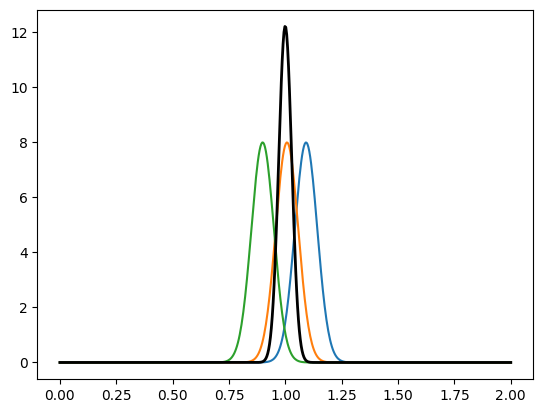

In [15]:
for i in range(3):
    plt.plot(as_, a_distributions_values[i], label=f'Observation {i+1}')

plt.plot(as_, likelihood, label='Likelihood', color='k', linewidth=2)

In [16]:
def prior(a):
    """Prior por defecto: constante (uniforme) sobre la grilla de a."""
    return np.ones_like(a)


def posterior_func(a, prior=prior, likelihood=likelihood_func):
    """posterior(a) = prior(a) * likelihood(a) / norma, con norma = int prior*likelihood da."""
    unnormalized = prior(a) * likelihood(a)
    return unnormalized / np.trapezoid(unnormalized, a)


# --- Version MCMC (innecesaria: el parametro es 1D) -------------------------
# def log_prior(a):
#     if 0 < a < 2:
#         return 0.0  # log(1) = 0
#     return -np.inf  # log(0) = -inf
#
# def log_likelihood(a):
#     L = likelihood_func(np.array([a]))
#     if L <= 0:
#         return -np.inf
#     return np.log(L[0])
#
# def log_probability(theta):
#     a = theta[0]
#     lp = log_prior(a)
#     if not np.isfinite(lp):
#         return -np.inf
#     return lp + log_likelihood(a)

In [17]:
posterior_a = posterior_func(as_)

# --- Version MCMC (innecesaria: el parametro es 1D) -------------------------
# import emcee
#
# ndim = 1
# nwalkers = 32
# a_initial = 1.0
#
# initial_positions = (
#     a_initial
#     + 0.01 * np.random.randn(nwalkers, ndim)
# )
#
# sampler = emcee.EnsembleSampler(
#     nwalkers,
#     ndim,
#     log_probability
# )
#
# sampler.run_mcmc(
#     initial_positions,
#     5000,
#     progress=True
# )

In [18]:
from scipy.integrate import cumulative_trapezoid


def grid_quantiles(a, posterior_values, q):
    """Cuantiles de un posterior tabulado: se invierte la CDF acumulada por trapecios."""
    cdf = cumulative_trapezoid(posterior_values, a, initial=0.0)
    cdf /= cdf[-1]
    return np.interp(q, cdf, a)


# samples_a = sampler.get_chain(
#     discard=1000,
#     flat=True
# )[:, 0]

In [19]:
a_low, a_median, a_high = grid_quantiles(as_, posterior_a, [0.16, 0.50, 0.84])

pd.DataFrame(
    {
        'quantile': [0.16, 0.50, 0.84],
        'a': [a_low, a_median, a_high],
    }
)

,quantile,a
0,0.16,0.970694
1,0.50,0.999472
2,0.84,1.028276


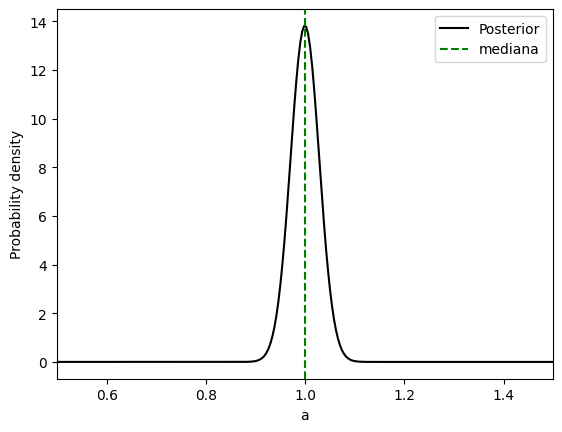

In [20]:
plt.plot(as_, posterior_a, 'k', label='Posterior')
plt.axvline(a_median, color='g', linestyle='--', label='mediana')
plt.xlabel("a")
plt.ylabel("Probability density")
plt.xlim(a_median - 10 * sigma_proper, a_median + 10 * sigma_proper)
plt.legend()

plt.show()

In [21]:
# Lz = sqrt(a): cambio de variable, p_Lz(Lz) = p_a(a) |da/dLz| = p_a(Lz^2) * 2 Lz
Lz_grid = np.sqrt(as_)
posterior_Lz = posterior_a * 2 * Lz_grid

# la transformacion es monotona: los cuantiles se transforman igual
median_Lz = np.sqrt(a_median)

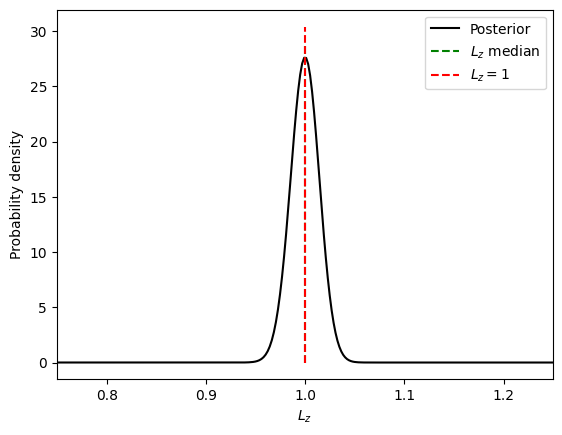

In [22]:
plt.plot(Lz_grid, posterior_Lz, 'k', label='Posterior')
plt.xlabel(r"$L_z$")
plt.ylabel("Probability density")
plt.xlim(median_Lz - 5 * sigma_proper, median_Lz + 5 * sigma_proper)

plt.vlines(median_Lz, ymin=0, ymax=plt.gca().get_ylim()[1], color='g', linestyle='--', label=r"$L_z$ median")
plt.vlines(np.sqrt(1), ymin=0, ymax=plt.gca().get_ylim()[1], color='r', linestyle='--', label=r"$L_z = 1$")

plt.legend()
plt.show()

Pipeline completo:
1. 

In [23]:
import numpy as np
from scipy.integrate import quad

def get_distribution_a(distribution, *args):
    return lambda a: a * quad(
        lambda theta: distribution(
            a * np.cos(theta),
            a * np.sin(theta),
            *args
        ),
        0,
        2 * np.pi
    )[0]

### Marginal analítica de $a$ para una gaussiana isotrópica

Con $x = a\cos\theta$, $y = a\sin\theta$ y centro $(x_0, y_0) = (r_0\cos\theta_0,\, r_0\sin\theta_0)$,

$$
(a\cos\theta - x_0)^2 + (a\sin\theta - y_0)^2 = a^2 + r_0^2 - 2 a r_0 \cos(\theta-\theta_0)
$$

por lo que

$$
p(a) = a \int_0^{2\pi} \frac{1}{2\pi\sigma^2}
\exp\left[-\frac{a^2 + r_0^2 - 2 a r_0\cos(\theta-\theta_0)}{2\sigma^2}\right] d\theta .
$$

La única dependencia angular es $\cos(\theta-\theta_0)$, y

$$
\int_0^{2\pi} e^{z\cos(\theta-\theta_0)}\, d\theta = 2\pi I_0(z),
$$

con $I_0$ la función de Bessel modificada de primera especie. Entonces

$$
\boxed{\;p(a) = \frac{a}{\sigma^2}\,
\exp\left[-\frac{a^2+r_0^2}{2\sigma^2}\right] I_0\!\left(\frac{a r_0}{\sigma^2}\right)\;}
$$

que es la distribución de **Rice** con parámetros $\nu = r_0$, $\sigma$. Nota que $\theta_0$ desaparece: la marginal solo depende de la distancia del centro al origen.

**Forma numéricamente estable.** Para $\sigma = 0.05$ y $a \sim r_0 \sim 1$ el argumento es $a r_0/\sigma^2 \approx 400$: $I_0$ desborda y la exponencial hace underflow. Usando la Bessel escalada $\tilde{I}_0(z) = I_0(z)e^{-z}$ (`scipy.special.ive`) los dos efectos se cancelan:

$$
p(a) = \frac{a}{\sigma^2}\, \tilde{I}_0\!\left(\frac{a r_0}{\sigma^2}\right)
\exp\left[-\frac{(a-r_0)^2}{2\sigma^2}\right],
\qquad
\ln p(a) = \ln a - 2\ln\sigma + \ln \tilde{I}_0\!\left(\frac{a r_0}{\sigma^2}\right) - \frac{(a-r_0)^2}{2\sigma^2}.
$$


In [24]:
# Asumamos que tenemos N puntos con distribuciones cualquiera.

from scipy.special import ive


class Distribution:
    def __init__(self, coordinate_system='cartesian'):
        self.coordinate_system = coordinate_system

    def evaluate(self, *args):
        raise NotImplementedError("This method should be implemented in subclasses.")

    def marginal_a(self, a):
        """p(a): distribution marginalized over theta, at radius a."""
        raise NotImplementedError("This method should be implemented in subclasses.")

    def log_marginal_a(self, a):
        raise NotImplementedError("This method should be implemented in subclasses.")


class GaussianIsotropic(Distribution):
    def __init__(self, sigma, x0=0, y0=0):
        super().__init__(coordinate_system='cartesian')
        self.sigma = sigma
        self.x0 = x0
        self.y0 = y0
        self.r0 = np.hypot(x0, y0)

    def evaluate(self, x, y):
        return (1 / (2 * np.pi * self.sigma ** 2)) * np.exp(-((x - self.x0) ** 2 + (y - self.y0) ** 2) / (2 * self.sigma ** 2))

    def marginal_a(self, a):
        """
        Analytic p(a) = a * int_0^2pi evaluate(a cos(theta), a sin(theta)) d(theta).

        Rice distribution with parameters nu = r0, sigma. Written with the
        exponentially scaled Bessel ive(0, z) = I0(z) * exp(-z) so that the
        overflow of I0 cancels the underflow of the exponential.
        """
        a = np.asarray(a, dtype=float)
        z = a * self.r0 / self.sigma ** 2
        return (a / self.sigma ** 2) * ive(0, z) * np.exp(-(a - self.r0) ** 2 / (2 * self.sigma ** 2))

    def log_marginal_a(self, a):
        """log of marginal_a, safe down to the tails where marginal_a underflows to 0."""
        a = np.asarray(a, dtype=float)
        with np.errstate(divide='ignore'):
            log_a = np.log(a)
        z = a * self.r0 / self.sigma ** 2
        return (
            log_a
            - 2 * np.log(self.sigma)
            + np.log(ive(0, z))
            - (a - self.r0) ** 2 / (2 * self.sigma ** 2)
        )


In [25]:
# Usando distibuciones de puntos, hallamos las distribuciones derivadas

# import emcee  # innecesario: el posterior es 1D, se tabula en una grilla de a

from scipy.integrate import cumulative_trapezoid


def constant_prior(a):
    """Prior por defecto: constante (uniforme). Se normaliza junto con el posterior."""
    return np.ones_like(a)


class DerivedDistribution:
    def evaluate(self, *args):
        raise NotImplementedError("This method should be implemented in subclasses.")


class DistributionA(DerivedDistribution):
    def __init__(self, distributions: list[Distribution]):
        super().__init__()
        self.distributions = list(distributions)

    # Version numerica (referencia / distribuciones sin marginal analitica):
    # def marginal(self, distribution, a):
    #     """p(a) for a single point distribution, marginalized over theta."""
    #     return a * quad(
    #         lambda theta: distribution.evaluate(
    #             a * np.cos(theta),
    #             a * np.sin(theta)
    #         ),
    #         0,
    #         2 * np.pi
    #     )[0]

    def marginal(self, distribution, a):
        """p(a) for a single point distribution, marginalized over theta."""
        return distribution.marginal_a(a)

    def evaluate_scalar(self, a):
        """Likelihood at a single value of a."""
        return float(np.prod([self.marginal(d, a) for d in self.distributions]))

    def evaluate(self, a):
        """Likelihood over a scalar or an array of a values (vectorized)."""
        a = np.atleast_1d(np.asarray(a, dtype=float))
        return np.prod([d.marginal_a(a) for d in self.distributions], axis=0)

    def log_evaluate(self, a):
        """log-likelihood over a scalar or an array of a values (vectorized)."""
        a = np.atleast_1d(np.asarray(a, dtype=float))
        return np.sum([d.log_marginal_a(a) for d in self.distributions], axis=0)

    def posterior(self, a, prior=constant_prior):
        """
        posterior(a) = prior(a) * likelihood(a) / norma,  norma = int prior*likelihood da.

        El parametro es unidimensional, asi que basta tabular sobre la grilla `a`
        y normalizar por trapecios (no hace falta muestrear con MCMC).

        El producto se hace en logaritmo y se resta el maximo antes de exponenciar:
        con muchos puntos la verosimilitud hace underflow, y el desplazamiento se
        cancela al normalizar.
        """
        a = np.atleast_1d(np.asarray(a, dtype=float))
        prior_values = np.broadcast_to(
            np.asarray(prior(a), dtype=float), a.shape
        )

        with np.errstate(divide='ignore', invalid='ignore'):
            log_posterior = np.log(prior_values) + self.log_evaluate(a)

        finite = np.isfinite(log_posterior)
        if not finite.any():
            raise ValueError("El posterior es nulo en toda la grilla de a.")

        posterior_values = np.zeros_like(a)
        posterior_values[finite] = np.exp(
            log_posterior[finite] - log_posterior[finite].max()
        )

        return posterior_values / np.trapezoid(posterior_values, a)

    def posterior_quantiles(self, a, q, prior=constant_prior):
        """Cuantiles del posterior tabulado, invirtiendo la CDF acumulada por trapecios."""
        a = np.atleast_1d(np.asarray(a, dtype=float))
        posterior_values = self.posterior(a, prior=prior)
        cdf = cumulative_trapezoid(posterior_values, a, initial=0.0)
        cdf /= cdf[-1]
        return np.interp(q, cdf, a)

    # --- Version MCMC (innecesaria: el parametro es 1D) ---------------------
    # def log_likelihood(self, a):
    #     # sum of logs instead of log of the product: avoids underflow for many points
    #     total = 0.0
    #     for distribution in self.distributions:
    #         total += distribution.log_marginal_a(a)
    #     return total if np.isfinite(total) else -np.inf
    #
    # def log_probability(self, theta, log_prior):
    #     a = theta[0]
    #     lp = log_prior(a)
    #     if not np.isfinite(lp):
    #         return -np.inf
    #     return lp + self.log_likelihood(a)
    #
    # def get_posterior_samples(
    #         self,
    #         log_prior,
    #         a_initial=1.0,
    #         nwalkers=32,
    #         nsteps=5000,
    #         discard=1000,
    #         progress=True,
    #     ):
    #
    #     ndim = 1
    #
    #     initial_positions = (
    #         a_initial
    #         + 0.01 * np.random.randn(nwalkers, ndim)
    #     )
    #
    #     sampler = emcee.EnsembleSampler(
    #         nwalkers,
    #         ndim,
    #         self.log_probability,
    #         args=(log_prior,)
    #     )
    #
    #     sampler.run_mcmc(
    #         initial_positions,
    #         nsteps,
    #         progress=progress
    #     )
    #
    #     self.sampler = sampler
    #
    #     return sampler.get_chain(discard=discard, flat=True)[:, 0]


In [26]:
points = [
    GaussianIsotropic(
        sigma=sigma_proper, 
        x0=xs_obs[i], 
        y0=ys_obs[i]
    ) for i in range(len(xs_obs))
]

distribution_a = DistributionA(points)

In [27]:
# likelihood curve over a grid
likelihood_values = distribution_a.evaluate(as_)

# posterior sobre la grilla: prior * likelihood / norma (prior constante por defecto)
posterior_values = distribution_a.posterior(as_)

a_low, a_median, a_high = distribution_a.posterior_quantiles(as_, [0.16, 0.50, 0.84])

pd.DataFrame(
    {
        'quantile': [0.16, 0.50, 0.84],
        'a': [a_low, a_median, a_high],
        'Lz': np.sqrt([a_low, a_median, a_high]),
    }
)

,quantile,a,Lz
0,0.16,0.970694,0.985238
1,0.50,0.999472,0.999736
2,0.84,1.028276,1.014039


$$
L_z=\sqrt{a}
$$

$$
a=L_z^2
$$

$$
dP=p_a(a)\,da=p_{L_z}(L_z)\,dL_z
$$

$$
p_{L_z}(L_z)\,dL_z=p_a(a)\,da
$$

$$
p_{L_z}(L_z)
=
p_a(a)\left|\frac{da}{dL_z}\right|
$$

$$
\frac{da}{dL_z}
=
\frac{d(L_z^2)}{dL_z}
=
2L_z
$$

$$
p_{L_z}(L_z)
=
p_a(L_z^2)\left|2L_z\right|
$$

$$
\boxed{
p_{L_z}(L_z)
=
2L_z\,p_a(L_z^2)
}
\qquad
(L_z\geq 0)
$$

$$
L_z = \sqrt{a}
$$

$$
p_{L_z}(L_z) = p_a(L_z^2) \left|\frac{da}{dL_z}\right| = 2 L_z p_a(L_z^2)
$$

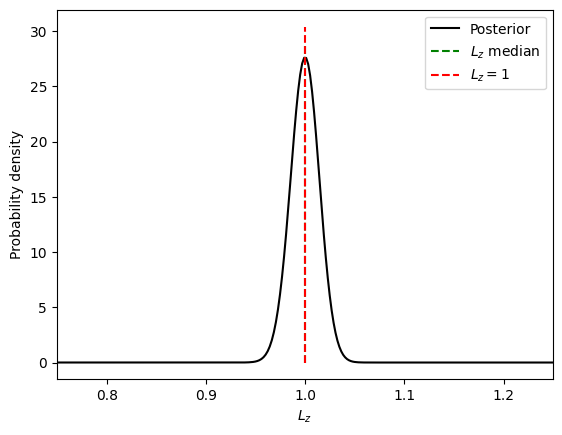

In [28]:
# Lz = sqrt(a): cambio de variable, p_Lz(Lz) = p_a(Lz^2) * |da/dLz| = p_a(a) * 2 Lz
Lz_values = np.sqrt(as_)
posterior_Lz_values = posterior_values * 2 * Lz_values

# la transformacion es monotona: la mediana se transforma directamente
median_Lz = np.sqrt(a_median)

plt.plot(Lz_values, posterior_Lz_values, 'k', label='Posterior')
plt.xlabel(r"$L_z$")
plt.ylabel("Probability density")
plt.xlim(median_Lz - 5 * sigma_proper, median_Lz + 5 * sigma_proper)

plt.vlines(median_Lz, ymin=0, ymax=plt.gca().get_ylim()[1], color='g', linestyle='--', label=r"$L_z$ median")
plt.vlines(np.sqrt(1), ymin=0, ymax=plt.gca().get_ylim()[1], color='r', linestyle='--', label=r"$L_z = 1$")

plt.legend()
plt.show()

# Con sigma_x diff sigma_y

In [29]:
from scipy.special import logsumexp


def get_posterior_Lz(xs, ys, ts, sigma_x, sigma_y):
    """Posterior p(Lz) y su mediana para una orbita circular con G = M = 1."""
    xs = np.asarray(xs, dtype=float)
    ys = np.asarray(ys, dtype=float)
    ts = np.asarray(ts, dtype=float)

    if not (xs.ndim == ys.ndim == ts.ndim == 1 and len(xs) == len(ys) == len(ts)):
        raise ValueError("xs, ys y ts deben ser arreglos unidimensionales de igual longitud.")
    if len(xs) == 0:
        raise ValueError("Se necesita al menos una observacion.")
    if sigma_x <= 0 or sigma_y <= 0:
        raise ValueError("sigma_x y sigma_y deben ser positivos.")

    # Para una orbita circular, a es constante. Como antes, la fase de cada
    # observacion se marginaliza; ts solo identifica observaciones correspondientes.
    a_max = np.max(np.hypot(xs, ys)) + 10 * max(sigma_x, sigma_y)
    a_values = np.linspace(0, a_max, 2000)
    theta_values = np.linspace(0, 2 * np.pi, 2048, endpoint=False)

    log_likelihood = np.zeros_like(a_values)
    with np.errstate(divide='ignore'):
        log_a = np.log(a_values)

    for x0, y0 in zip(xs, ys):
        exponent = -0.5 * (
            ((a_values[:, None] * np.cos(theta_values) - x0) / sigma_x) ** 2
            + ((a_values[:, None] * np.sin(theta_values) - y0) / sigma_y) ** 2
        )
        log_marginal_a = (
            log_a
            - np.log(sigma_x * sigma_y)
            + logsumexp(exponent, axis=1)
            - np.log(len(theta_values))
        )
        log_likelihood += log_marginal_a

    posterior_a = np.exp(log_likelihood - np.max(log_likelihood))
    posterior_a /= np.trapezoid(posterior_a, a_values)

    # Lz = sqrt(a): p_Lz(Lz) = p_a(Lz^2) * 2 Lz.
    Lz_values = np.sqrt(a_values)
    posterior_Lz = posterior_a * 2 * Lz_values
    posterior_Lz /= np.trapezoid(posterior_Lz, Lz_values)

    cdf = cumulative_trapezoid(posterior_Lz, Lz_values, initial=0.0)
    cdf /= cdf[-1]
    median_Lz = float(np.interp(0.5, cdf, Lz_values))

    def p_Lz(Lz):
        Lz = np.asarray(Lz, dtype=float)
        values = np.interp(Lz, Lz_values, posterior_Lz, left=0.0, right=0.0)
        return float(values) if Lz.ndim == 0 else values

    return p_Lz, median_Lz

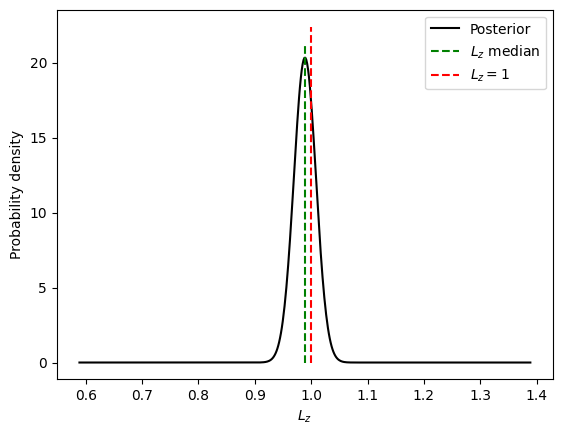

In [30]:
sigma_x = 0.03
sigma_y = 0.08

p_Lz, median_Lz_anisotropic = get_posterior_Lz(
    xs_obs, ys_obs, ts_obs, sigma_x, sigma_y
)

Lz_values = np.linspace(
    max(0, median_Lz_anisotropic - 5 * max(sigma_x, sigma_y)),
    median_Lz_anisotropic + 5 * max(sigma_x, sigma_y),
    500,
)

plt.plot(Lz_values, p_Lz(Lz_values), 'k', label='Posterior')
plt.xlabel(r"$L_z$")
plt.ylabel("Probability density")

plt.vlines(median_Lz_anisotropic, ymin=0, ymax=plt.gca().get_ylim()[1], color='g', linestyle='--', label=r"$L_z$ median")
plt.vlines(np.sqrt(1), ymin=0, ymax=plt.gca().get_ylim()[1], color='r', linestyle='--', label=r"$L_z = 1$")

plt.legend()
plt.show()

# En 3d

In [31]:
from numpy.polynomial.legendre import leggauss


def get_posterior_Lz_3d(xs, ys, zs, ts, sigma_x, sigma_y, sigma_z):
    """Posterior p(Lz) y su mediana para una orbita circular 3D con G = M = 1."""
    xs = np.asarray(xs, dtype=float)
    ys = np.asarray(ys, dtype=float)
    zs = np.asarray(zs, dtype=float)
    ts = np.asarray(ts, dtype=float)

    if not (
        xs.ndim == ys.ndim == zs.ndim == ts.ndim == 1
        and len(xs) == len(ys) == len(zs) == len(ts)
    ):
        raise ValueError("xs, ys, zs y ts deben ser arreglos unidimensionales de igual longitud.")
    if len(xs) == 0:
        raise ValueError("Se necesita al menos una observacion.")
    if sigma_x <= 0 or sigma_y <= 0 or sigma_z <= 0:
        raise ValueError("sigma_x, sigma_y y sigma_z deben ser positivos.")

    # Para una orbita circular, a es constante. La fase y la orientacion de
    # cada observacion se marginalizan sobre una esfera de radio a.
    a_max = np.max(np.sqrt(xs ** 2 + ys ** 2 + zs ** 2)) + 10 * max(sigma_x, sigma_y, sigma_z)
    a_values = np.linspace(0, a_max, 2000)

    mu_values, mu_weights = leggauss(128)
    phi_values = np.linspace(0, 2 * np.pi, 256, endpoint=False)
    sin_theta = np.sqrt(1 - mu_values ** 2)[:, None]
    directions_x = (sin_theta * np.cos(phi_values)).ravel()
    directions_y = (sin_theta * np.sin(phi_values)).ravel()
    directions_z = np.broadcast_to(mu_values[:, None], (len(mu_values), len(phi_values))).ravel()
    log_weights = np.repeat(np.log(mu_weights), len(phi_values)) + np.log(2 * np.pi / len(phi_values))

    log_likelihood = np.zeros_like(a_values)
    with np.errstate(divide='ignore'):
        log_jacobian = 2 * np.log(a_values)

    for x0, y0, z0 in zip(xs, ys, zs):
        log_integral = np.empty_like(a_values)
        for start in range(0, len(a_values), 64):
            stop = min(start + 64, len(a_values))
            a_block = a_values[start:stop, None]
            exponent = -0.5 * (
                ((a_block * directions_x - x0) / sigma_x) ** 2
                + ((a_block * directions_y - y0) / sigma_y) ** 2
                + ((a_block * directions_z - z0) / sigma_z) ** 2
            )
            log_integral[start:stop] = logsumexp(
                exponent + log_weights, axis=1
            )
        log_marginal_a = (
            log_jacobian
            - 1.5 * np.log(2 * np.pi)
            - np.log(sigma_x * sigma_y * sigma_z)
            + log_integral
        )
        log_likelihood += log_marginal_a

    posterior_a = np.exp(log_likelihood - np.max(log_likelihood))
    posterior_a /= np.trapezoid(posterior_a, a_values)

    # Lz = sqrt(a): p_Lz(Lz) = p_a(Lz^2) * 2 Lz.
    Lz_values = np.sqrt(a_values)
    posterior_Lz = posterior_a * 2 * Lz_values
    posterior_Lz /= np.trapezoid(posterior_Lz, Lz_values)

    cdf = cumulative_trapezoid(posterior_Lz, Lz_values, initial=0.0)
    cdf /= cdf[-1]
    median_Lz = float(np.interp(0.5, cdf, Lz_values))

    def p_Lz(Lz):
        Lz = np.asarray(Lz, dtype=float)
        values = np.interp(Lz, Lz_values, posterior_Lz, left=0.0, right=0.0)
        return float(values) if Lz.ndim == 0 else values

    return p_Lz, median_Lz

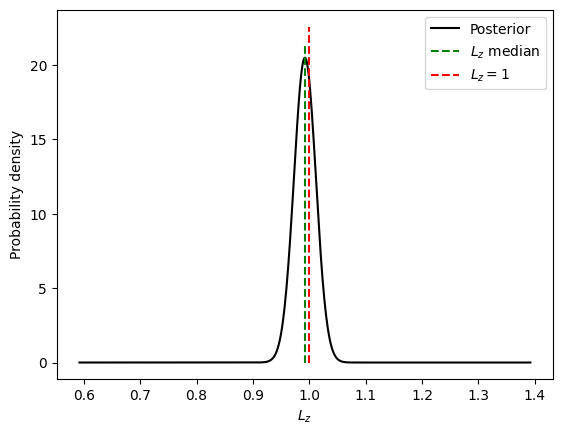

In [32]:
sigma_z = 0.05
rng = np.random.default_rng(seed)
zs_obs = rng.normal(0, sigma_z, len(xs_obs))

p_Lz_3d, median_Lz_3d = get_posterior_Lz_3d(
    xs_obs, ys_obs, zs_obs, ts_obs, sigma_x, sigma_y, sigma_z
)

Lz_values_3d = np.linspace(
    max(0, median_Lz_3d - 5 * max(sigma_x, sigma_y, sigma_z)),
    median_Lz_3d + 5 * max(sigma_x, sigma_y, sigma_z),
    500,
)

plt.plot(Lz_values_3d, p_Lz_3d(Lz_values_3d), 'k', label='Posterior')
plt.xlabel(r"$L_z$")
plt.ylabel("Probability density")

plt.vlines(median_Lz_3d, ymin=0, ymax=plt.gca().get_ylim()[1], color='g', linestyle='--', label=r"$L_z$ median")
plt.vlines(np.sqrt(1), ymin=0, ymax=plt.gca().get_ylim()[1], color='r', linestyle='--', label=r"$L_z = 1$")

plt.legend()
plt.show()

# Cualquier distribución

In [33]:
def get_posterior_Lz_3d_general(probability_xyz, a_values=None):
    """Posterior p(Lz) y su mediana para distribuciones 3D cualesquiera."""
    if a_values is None:
        a_values = np.linspace(0, 2, 2000)
    else:
        a_values = np.asarray(a_values, dtype=float)

    mu_values, mu_weights = leggauss(128)
    phi_values = np.linspace(0, 2 * np.pi, 256, endpoint=False)
    sin_theta = np.sqrt(1 - mu_values ** 2)[:, None]
    directions_x = (sin_theta * np.cos(phi_values)).ravel()
    directions_y = (sin_theta * np.sin(phi_values)).ravel()
    directions_z = np.broadcast_to(mu_values[:, None], (len(mu_values), len(phi_values))).ravel()
    log_weights = np.repeat(np.log(mu_weights), len(phi_values)) + np.log(2 * np.pi / len(phi_values))

    log_likelihood = None
    with np.errstate(divide='ignore'):
        log_jacobian = 2 * np.log(a_values)

    for start in range(0, len(a_values), 32):
        stop = min(start + 32, len(a_values))
        a_block = a_values[start:stop, None]
        if hasattr(probability_xyz, 'marginal_a'):
            marginal_values = np.asarray(
                probability_xyz.marginal_a(a_values[start:stop]), dtype=float
            )
            with np.errstate(divide='ignore'):
                log_marginals = np.log(marginal_values)
        else:
            x = a_block * directions_x
            y = a_block * directions_y
            z = a_block * directions_z
            probability_values = np.asarray(probability_xyz(x, y, z), dtype=float)

            if probability_values.shape == x.shape:
                probability_values = probability_values[None, ...]
            if probability_values.ndim != 3 or probability_values.shape[1:] != x.shape:
                raise ValueError(
                    "probability_xyz debe devolver un arreglo (N, len(a), len(direcciones))."
                )
            if np.any(probability_values < 0) or not np.all(np.isfinite(probability_values)):
                raise ValueError("probability_xyz debe devolver densidades finitas y no negativas.")

            with np.errstate(divide='ignore'):
                log_marginals = (
                    log_jacobian[start:stop]
                    + logsumexp(np.log(probability_values) + log_weights, axis=2)
                )

        if log_likelihood is None:
            log_likelihood = np.empty_like(a_values)
        log_likelihood[start:stop] = np.sum(log_marginals, axis=0)

    finite = np.isfinite(log_likelihood)
    if not finite.any():
        raise ValueError("El posterior es nulo en toda la grilla de a.")

    posterior_a = np.zeros_like(a_values)
    posterior_a[finite] = np.exp(log_likelihood[finite] - log_likelihood[finite].max())
    posterior_a /= np.trapezoid(posterior_a, a_values)

    # Lz = sqrt(a): p_Lz(Lz) = p_a(Lz^2) * 2 Lz.
    Lz_values = np.sqrt(a_values)
    posterior_Lz = posterior_a * 2 * Lz_values
    posterior_Lz /= np.trapezoid(posterior_Lz, Lz_values)

    cdf = cumulative_trapezoid(posterior_Lz, Lz_values, initial=0.0)
    cdf /= cdf[-1]
    median_Lz = float(np.interp(0.5, cdf, Lz_values))

    def p_Lz(Lz):
        Lz = np.asarray(Lz, dtype=float)
        values = np.interp(Lz, Lz_values, posterior_Lz, left=0.0, right=0.0)
        return float(values) if Lz.ndim == 0 else values

    return p_Lz, median_Lz

In [34]:
from scipy.stats import norm, t


def gaussian_probability_xyz(x, y, z):
    return np.array([
        norm.pdf(x, loc=x0, scale=sigma_x)
        * norm.pdf(y, loc=y0, scale=sigma_y)
        * norm.pdf(z, loc=z0, scale=sigma_z)
        for x0, y0, z0 in zip(xs_obs, ys_obs, zs_obs)
    ])


degrees_of_freedom = 3


def student_probability_xyz(x, y, z):
    return np.array([
        t.pdf(x, df=degrees_of_freedom, loc=x0, scale=sigma_x)
        * t.pdf(y, df=degrees_of_freedom, loc=y0, scale=sigma_y)
        * t.pdf(z, df=degrees_of_freedom, loc=z0, scale=sigma_z)
        for x0, y0, z0 in zip(xs_obs, ys_obs, zs_obs)
    ])


p_Lz_gaussian, median_Lz_gaussian = get_posterior_Lz_3d_general(
    gaussian_probability_xyz
)
p_Lz_student, median_Lz_student = get_posterior_Lz_3d_general(
    student_probability_xyz
)

pd.DataFrame(
    {
        'distribution': ['Gaussian specialized', 'Gaussian general', 'Student-t'],
        'median_Lz': [median_Lz_3d, median_Lz_gaussian, median_Lz_student],
    }
)

,distribution,median_Lz
0,Gaussian specialized,0.992169
1,Gaussian general,0.992169
2,Student-t,0.997990


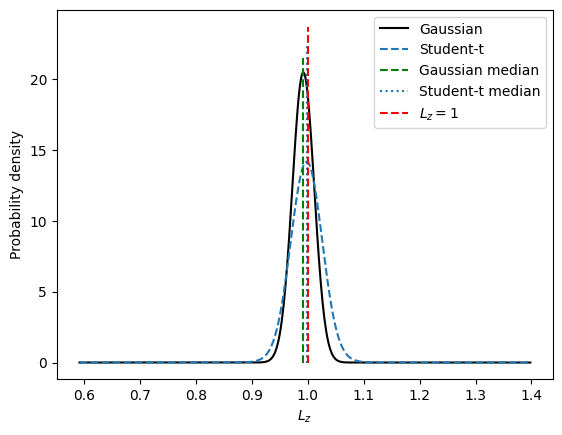

In [35]:
Lz_values_general = np.linspace(
    max(0, min(median_Lz_gaussian, median_Lz_student) - 5 * max(sigma_x, sigma_y, sigma_z)),
    max(median_Lz_gaussian, median_Lz_student) + 5 * max(sigma_x, sigma_y, sigma_z),
    500,
)

plt.plot(Lz_values_general, p_Lz_gaussian(Lz_values_general), 'k', label='Gaussian')
plt.plot(Lz_values_general, p_Lz_student(Lz_values_general), color='tab:blue', linestyle='--', label='Student-t')
plt.xlabel(r"$L_z$")
plt.ylabel("Probability density")

plt.vlines(median_Lz_gaussian, ymin=0, ymax=plt.gca().get_ylim()[1], color='g', linestyle='--', label='Gaussian median')
plt.vlines(median_Lz_student, ymin=0, ymax=plt.gca().get_ylim()[1], color='tab:blue', linestyle=':', label='Student-t median')
plt.vlines(np.sqrt(1), ymin=0, ymax=plt.gca().get_ylim()[1], color='r', linestyle='--', label=r"$L_z = 1$")

plt.legend()
plt.show()

# RA y DEC

Asumamos que tenemos una distacia fija r0 a las estrellas, así evitamos la profundidad

$$
\begin{aligned}
&\text{Sean } \alpha=\mathrm{RA},\qquad \delta=\mathrm{DEC},
\qquad r=r_0=\text{constante},\\[1mm]
&\alpha\sim D_1(\alpha),\qquad
\delta\sim D_2(\delta),
\end{aligned}
$$

$$
p_{\alpha,\delta}(\alpha,\delta)
=
D_1(\alpha)D_2(\delta),
$$

$$
\begin{aligned}
x &= r\cos\delta\cos\alpha,\\
y &= r\cos\delta\sin\alpha,\\
z &= r\sin\delta.
\end{aligned}
$$

$$
\left|
\frac{\partial(x,y,z)}
     {\partial(r,\alpha,\delta)}
\right|
=
\begin{vmatrix}
\cos\delta\cos\alpha
&
-r\cos\delta\sin\alpha
&
-r\sin\delta\cos\alpha
\\
\cos\delta\sin\alpha
&
r\cos\delta\cos\alpha
&
-r\sin\delta\sin\alpha
\\
\sin\delta
&
0
&
r\cos\delta
\end{vmatrix}
=
r^2\cos\delta.
$$

$$
dx\,dy\,dz
=
r^2\cos\delta\;dr\,d\alpha\,d\delta.
$$

$$
\text{Como }r=r_0\text{ es fijo, podemos escribir}
\qquad
p(r,\alpha,\delta)
=
\delta_{\rm D}(r-r_0)\,
D_1(\alpha)D_2(\delta),
$$

$$
p(x,y,z)\,dx\,dy\,dz
=
p(r,\alpha,\delta)\,dr\,d\alpha\,d\delta.
$$

$$
\therefore\qquad
p(x,y,z)
=
\frac{
D_1(\alpha)D_2(\delta)
}{
r^2\cos\delta
}
\,
\delta_{\rm D}(r-r_0).
$$

$$
\begin{aligned}
r &= \sqrt{x^2+y^2+z^2},\\
\alpha &= \operatorname{atan2}(y,x),\\
\delta &=
\operatorname{atan2}\!\left(
z,\sqrt{x^2+y^2}
\right).
\end{aligned}
$$

$$
\boxed{
p(x,y,z)
=
\frac{
D_1\!\left(\operatorname{atan2}(y,x)\right)
D_2\!\left(
\operatorname{atan2}\!\left(z,\sqrt{x^2+y^2}\right)
\right)
}{
\left(x^2+y^2+z^2\right)
\cos\!\left[
\operatorname{atan2}\!\left(z,\sqrt{x^2+y^2}\right)
\right]
}
\,
\delta_{\rm D}\!\left(
\sqrt{x^2+y^2+z^2}-r_0
\right)
}
$$

$$
\text{y usando }
\cos\delta
=
\frac{\sqrt{x^2+y^2}}
     {\sqrt{x^2+y^2+z^2}},
$$

$$
\boxed{
p(x,y,z)
=
\frac{
D_1\!\left(\operatorname{atan2}(y,x)\right)
D_2\!\left(
\operatorname{atan2}\!\left(z,\sqrt{x^2+y^2}\right)
\right)
}{
\sqrt{x^2+y^2+z^2}\,
\sqrt{x^2+y^2}
}
\,
\delta_{\rm D}\!\left(
\sqrt{x^2+y^2+z^2}-r_0
\right)
}
$$

Si en particular, asumimos que $D_1$ y $D_2$ son gaussianas, entonces:

$$
\boxed{
p(x,y,z)
=
\frac{
\delta_{\rm D}\!\left(
\sqrt{x^2+y^2+z^2}-r_0
\right)
}{
2\pi\,\sigma_{\rm RA}\sigma_{\rm DEC}\,
\sqrt{x^2+y^2+z^2}\,
\sqrt{x^2+y^2}
}
\exp\left[
-\frac{1}{2}
\left(
\frac{
\left[\operatorname{atan2}(y,x)-{\rm RA}_0\right]^2
}{
\sigma_{\rm RA}^2
}
+
\frac{
\left[
\operatorname{atan2}\!\left(z,\sqrt{x^2+y^2}\right)-{\rm DEC}_0
\right]^2
}{
\sigma_{\rm DEC}^2
}
\right)
\right]
}
$$

In [36]:
def get_p_xyz_from_RA_DEC(
    RAs, DECs, distances, RA_sigma, DEC_sigma, distance_sigma=0.01
):
    """Densidades p(x, y, z) con errores gaussianos en RA y DEC."""
    RAs = np.asarray(RAs, dtype=float)
    DECs = np.asarray(DECs, dtype=float)
    distances = np.asarray(distances, dtype=float)
    RA_sigma = np.broadcast_to(np.asarray(RA_sigma, dtype=float), RAs.shape)
    DEC_sigma = np.broadcast_to(np.asarray(DEC_sigma, dtype=float), DECs.shape)
    distance_sigma = np.broadcast_to(
        np.asarray(distance_sigma, dtype=float), distances.shape
    )

    if not (RAs.ndim == DECs.ndim == distances.ndim == 1 and len(RAs) == len(DECs) == len(distances)):
        raise ValueError("RAs, DECs y distances deben ser arreglos unidimensionales de igual longitud.")
    if len(RAs) == 0:
        raise ValueError("Se necesita al menos una observacion.")
    if np.any(RA_sigma <= 0) or np.any(DEC_sigma <= 0) or np.any(distance_sigma <= 0):
        raise ValueError("Las desviaciones estandar deben ser positivas.")

    def probability_xyz(x, y, z):
        x = np.asarray(x, dtype=float)
        y = np.asarray(y, dtype=float)
        z = np.asarray(z, dtype=float)

        r = np.sqrt(x ** 2 + y ** 2 + z ** 2)
        rho = np.sqrt(x ** 2 + y ** 2)
        RA = np.arctan2(y, x)
        DEC = np.arctan2(z, rho)
        jacobian = r * rho

        densities = []
        for RA0, DEC0, distance, sigma_RA, sigma_DEC, sigma_distance in zip(
            RAs, DECs, distances, RA_sigma, DEC_sigma, distance_sigma
        ):
            # RA es periodica: esta es la diferencia angular en [-pi, pi].
            delta_RA = np.arctan2(np.sin(RA - RA0), np.cos(RA - RA0))
            angular_density = (
                norm.pdf(delta_RA, loc=0, scale=sigma_RA)
                * norm.pdf(DEC, loc=DEC0, scale=sigma_DEC)
            )

            # Aproximacion numerica normalizada de delta_D(r - distance).
            radial_density = norm.pdf(
                r, loc=distance, scale=sigma_distance
            )
            density = np.zeros_like(r)
            np.divide(
                angular_density * radial_density,
                jacobian,
                out=density,
                where=jacobian > 0,
            )
            densities.append(density)

        return np.array(densities)

    def marginal_a(a):
        a = np.asarray(a, dtype=float)
        return np.array([
            norm.pdf(a, loc=distance, scale=sigma_distance)
            for distance, sigma_distance in zip(distances, distance_sigma)
        ])

    probability_xyz.marginal_a = marginal_a

    return probability_xyz

In [37]:
distances_obs = np.sqrt(xs_obs ** 2 + ys_obs ** 2 + zs_obs ** 2)
rhos_obs = np.sqrt(xs_obs ** 2 + ys_obs ** 2)
RAs_obs = np.arctan2(ys_obs, xs_obs)
DECs_obs = np.arctan2(zs_obs, rhos_obs)

# Propagacion lineal de los errores cartesianos hacia RA y DEC.
RA_sigmas = np.sqrt(
    ys_obs ** 2 * sigma_x ** 2 + xs_obs ** 2 * sigma_y ** 2
) / rhos_obs ** 2
DEC_sigmas = np.sqrt(
    (zs_obs * xs_obs * sigma_x) ** 2
    + (zs_obs * ys_obs * sigma_y) ** 2
    + (rhos_obs ** 2 * sigma_z) ** 2
) / (distances_obs ** 2 * rhos_obs)

probability_xyz_RA_DEC = get_p_xyz_from_RA_DEC(
    RAs_obs,
    DECs_obs,
    distances_obs,
    RA_sigmas,
    DEC_sigmas,
    distance_sigma=0.01,
)
p_Lz_RA_DEC, median_Lz_RA_DEC = get_posterior_Lz_3d_general(
    probability_xyz_RA_DEC
)

pd.DataFrame(
    {
        'coordinates': ['Cartesian Gaussian', 'RA and DEC Gaussian'],
        'median_Lz': [median_Lz_gaussian, median_Lz_RA_DEC],
    }
)

,coordinates,median_Lz
0,Cartesian Gaussian,0.992169
1,RA and DEC Gaussian,1.001478


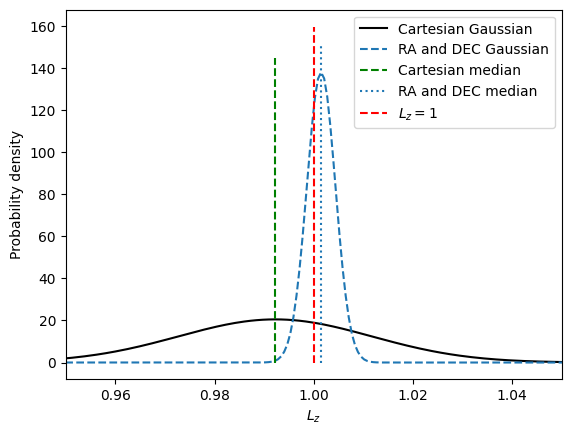

In [38]:
Lz_values_RA_DEC = np.linspace(
    max(0, min(median_Lz_gaussian, median_Lz_RA_DEC) - 0.15),
    max(median_Lz_gaussian, median_Lz_RA_DEC) + 0.15,
    500,
)

plt.plot(Lz_values_RA_DEC, p_Lz_gaussian(Lz_values_RA_DEC), 'k', label='Cartesian Gaussian')
plt.plot(Lz_values_RA_DEC, p_Lz_RA_DEC(Lz_values_RA_DEC), color='tab:blue', linestyle='--', label='RA and DEC Gaussian')
plt.xlabel(r"$L_z$")
plt.ylabel("Probability density")

plt.vlines(median_Lz_gaussian, ymin=0, ymax=plt.gca().get_ylim()[1], color='g', linestyle='--', label='Cartesian median')
plt.vlines(median_Lz_RA_DEC, ymin=0, ymax=plt.gca().get_ylim()[1], color='tab:blue', linestyle=':', label='RA and DEC median')
plt.vlines(np.sqrt(1), ymin=0, ymax=plt.gca().get_ylim()[1], color='r', linestyle='--', label=r"$L_z = 1$")

plt.xlim(0.95,1.05)
plt.legend()
plt.show()

In [39]:
def get_median_Lz_by_number_of_points(probability_xyz, number_of_points):
    """Mediana de Lz para los primeros N puntos de una densidad 3D."""
    number_of_points = np.asarray(number_of_points, dtype=int)
    a_values = np.linspace(0, 2, 1000)

    mu_values, mu_weights = leggauss(64)
    phi_values = np.linspace(0, 2 * np.pi, 128, endpoint=False)
    sin_theta = np.sqrt(1 - mu_values ** 2)[:, None]
    directions_x = (sin_theta * np.cos(phi_values)).ravel()
    directions_y = (sin_theta * np.sin(phi_values)).ravel()
    directions_z = np.broadcast_to(mu_values[:, None], (len(mu_values), len(phi_values))).ravel()
    log_weights = np.repeat(np.log(mu_weights), len(phi_values)) + np.log(2 * np.pi / len(phi_values))

    log_marginals = None
    with np.errstate(divide='ignore'):
        log_jacobian = 2 * np.log(a_values)

    for start in range(0, len(a_values), 8):
        stop = min(start + 8, len(a_values))
        a_block = a_values[start:stop, None]
        x = a_block * directions_x
        y = a_block * directions_y
        z = a_block * directions_z
        probability_values = np.asarray(probability_xyz(x, y, z), dtype=float)

        if probability_values.shape == x.shape:
            probability_values = probability_values[None, ...]
        if log_marginals is None:
            if number_of_points.max() > len(probability_values):
                raise ValueError("probability_xyz no contiene suficientes puntos.")
            log_marginals = np.empty((len(probability_values), len(a_values)))

        with np.errstate(divide='ignore'):
            log_marginals[:, start:stop] = (
                log_jacobian[start:stop]
                + logsumexp(np.log(probability_values) + log_weights, axis=2)
            )

    cumulative_log_likelihood = np.cumsum(log_marginals, axis=0)
    Lz_values = np.sqrt(a_values)
    medians = []

    for N in number_of_points:
        log_posterior = cumulative_log_likelihood[N - 1]
        finite = np.isfinite(log_posterior)
        posterior_a = np.zeros_like(a_values)
        posterior_a[finite] = np.exp(
            log_posterior[finite] - log_posterior[finite].max()
        )
        posterior_a /= np.trapezoid(posterior_a, a_values)

        posterior_Lz = posterior_a * 2 * Lz_values
        posterior_Lz /= np.trapezoid(posterior_Lz, Lz_values)
        cdf = cumulative_trapezoid(posterior_Lz, Lz_values, initial=0.0)
        cdf /= cdf[-1]
        medians.append(np.interp(0.5, cdf, Lz_values))

    return np.asarray(medians)


number_of_points = np.arange(3, 101)
number_of_extra_points = number_of_points.max() - len(xs_obs)
rng_points = np.random.default_rng(seed + 1)
theta_extra = rng_points.uniform(0, 2 * np.pi, number_of_extra_points)

xs_obs_many = np.concatenate([
    xs_obs,
    rng_points.normal(np.cos(theta_extra), sigma_x),
])
ys_obs_many = np.concatenate([
    ys_obs,
    rng_points.normal(np.sin(theta_extra), sigma_y),
])
zs_obs_many = np.concatenate([
    zs_obs,
    rng_points.normal(0, sigma_z, number_of_extra_points),
])


def gaussian_probability_xyz_many(x, y, z):
    return np.array([
        norm.pdf(x, loc=x0, scale=sigma_x)
        * norm.pdf(y, loc=y0, scale=sigma_y)
        * norm.pdf(z, loc=z0, scale=sigma_z)
        for x0, y0, z0 in zip(xs_obs_many, ys_obs_many, zs_obs_many)
    ])


distances_obs_many = np.sqrt(
    xs_obs_many ** 2 + ys_obs_many ** 2 + zs_obs_many ** 2
)
rhos_obs_many = np.sqrt(xs_obs_many ** 2 + ys_obs_many ** 2)
RAs_obs_many = np.arctan2(ys_obs_many, xs_obs_many)
DECs_obs_many = np.arctan2(zs_obs_many, rhos_obs_many)
RA_sigmas_many = np.sqrt(
    ys_obs_many ** 2 * sigma_x ** 2 + xs_obs_many ** 2 * sigma_y ** 2
) / rhos_obs_many ** 2
DEC_sigmas_many = np.sqrt(
    (zs_obs_many * xs_obs_many * sigma_x) ** 2
    + (zs_obs_many * ys_obs_many * sigma_y) ** 2
    + (rhos_obs_many ** 2 * sigma_z) ** 2
) / (distances_obs_many ** 2 * rhos_obs_many)
probability_xyz_RA_DEC_many = get_p_xyz_from_RA_DEC(
    RAs_obs_many,
    DECs_obs_many,
    distances_obs_many,
    RA_sigmas_many,
    DEC_sigmas_many,
    distance_sigma=0.01,
)

median_Lz_cartesian_by_N = get_median_Lz_by_number_of_points(
    gaussian_probability_xyz_many, number_of_points
)
median_Lz_RA_DEC_by_N = get_median_Lz_by_number_of_points(
    probability_xyz_RA_DEC_many, number_of_points
)
Lz_real = np.sqrt(1)

differences_by_N = pd.DataFrame(
    {
        'number_of_points': number_of_points,
        'Cartesian': np.abs(median_Lz_cartesian_by_N - Lz_real),
        'RA and DEC': np.abs(median_Lz_RA_DEC_by_N - Lz_real),
    }
)
differences_by_N

,number_of_points,Cartesian,RA and DEC
0,3,0.007825,0.001478
1,4,0.000679,0.006027
2,5,0.001404,0.003448
3,6,0.004778,0.002772
4,7,0.001410,0.001885
...,...,...,...
93,96,0.002061,0.002916
94,97,0.002204,0.002983
95,98,0.002496,0.003606
96,99,0.002579,0.003796


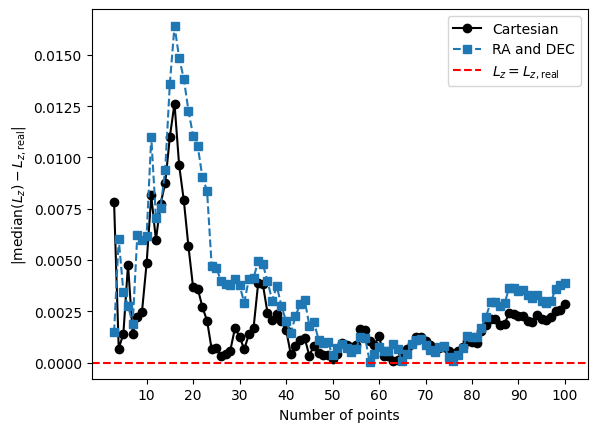

In [40]:
fig, ax = plt.subplots()
ax.plot(
    differences_by_N['number_of_points'],
    differences_by_N['Cartesian'],
    'o-',
    color='k',
    label='Cartesian',
)
ax.plot(
    differences_by_N['number_of_points'],
    differences_by_N['RA and DEC'],
    's--',
    color='tab:blue',
    label='RA and DEC',
)
ax.axhline(0, color='r', linestyle='--', label=r'$L_z = L_{z,\mathrm{real}}$')
ax.set_xlabel('Number of points')
ax.set_ylabel(r'$|\mathrm{median}(L_z) - L_{z,\mathrm{real}}|$')
ax.set_xticks(np.arange(10, 101, 10))
ax.legend()
plt.show()

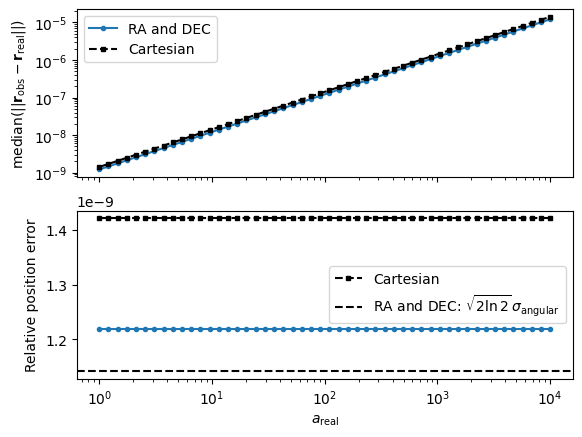

In [41]:
angular_error_mas = 0.20
angular_error_rad = np.deg2rad(angular_error_mas / (1000 * 3600))
a_real_values = np.geomspace(1, 10000, 50)
number_of_points_radius = 100

rng_radius = np.random.default_rng(seed + 2)
RAs_true_radius = rng_radius.uniform(0, 2 * np.pi, number_of_points_radius)
DECs_true_radius = np.zeros(number_of_points_radius)
RA_noise = rng_radius.normal(0, angular_error_rad, number_of_points_radius)
DEC_noise = rng_radius.normal(0, angular_error_rad, number_of_points_radius)
RAs_observed_radius = RAs_true_radius + RA_noise
DECs_observed_radius = DECs_true_radius + DEC_noise

cartesian_noise = rng_radius.normal(size=(number_of_points_radius, 3))
median_position_error_by_a = []
median_cartesian_error_by_a = []

for a_real in a_real_values:
    x_true = a_real * np.cos(DECs_true_radius) * np.cos(RAs_true_radius)
    y_true = a_real * np.cos(DECs_true_radius) * np.sin(RAs_true_radius)
    z_true = a_real * np.sin(DECs_true_radius)

    x_observed = a_real * np.cos(DECs_observed_radius) * np.cos(RAs_observed_radius)
    y_observed = a_real * np.cos(DECs_observed_radius) * np.sin(RAs_observed_radius)
    z_observed = a_real * np.sin(DECs_observed_radius)

    position_error = np.sqrt(
        (x_observed - x_true) ** 2
        + (y_observed - y_true) ** 2
        + (z_observed - z_true) ** 2
    )
    median_position_error_by_a.append(np.median(position_error))

    sigma_cartesian = a_real * angular_error_rad
    x_cartesian = x_true + sigma_cartesian * cartesian_noise[:, 0]
    y_cartesian = y_true + sigma_cartesian * cartesian_noise[:, 1]
    z_cartesian = z_true + sigma_cartesian * cartesian_noise[:, 2]
    cartesian_error = np.sqrt(
        (x_cartesian - x_true) ** 2
        + (y_cartesian - y_true) ** 2
        + (z_cartesian - z_true) ** 2
    )
    median_cartesian_error_by_a.append(np.median(cartesian_error))

median_position_error_by_a = np.asarray(median_position_error_by_a)
median_cartesian_error_by_a = np.asarray(median_cartesian_error_by_a)
relative_position_error_by_a = median_position_error_by_a / a_real_values
relative_cartesian_error_by_a = median_cartesian_error_by_a / a_real_values
expected_relative_error = np.sqrt(2 * np.log(2)) * angular_error_rad

fig, axes = plt.subplots(2, 1, sharex=True)
axes[0].plot(
    a_real_values,
    median_position_error_by_a,
    'o-',
    color='tab:blue',
    markersize=3,
    label='RA and DEC',
)
axes[0].plot(
    a_real_values,
    median_cartesian_error_by_a,
    's--',
    color='k',
    markersize=3,
    label='Cartesian',
)
axes[0].set_yscale('log')
axes[0].set_ylabel(r'$\mathrm{median}(||\mathbf{r}_{\mathrm{obs}}-\mathbf{r}_{\mathrm{real}}||)$')
axes[0].legend()

axes[1].plot(
    a_real_values,
    relative_position_error_by_a,
    'o-',
    color='tab:blue',
    markersize=3,
)
axes[1].plot(
    a_real_values,
    relative_cartesian_error_by_a,
    's--',
    color='k',
    markersize=3,
    label='Cartesian',
)
axes[1].axhline(
    expected_relative_error,
    color='k',
    linestyle='--',
    label=r'RA and DEC: $\sqrt{2\ln 2}\,\sigma_{\mathrm{angular}}$',
)
axes[1].set_xscale('log')
axes[1].set_xlabel(r'$a_{\mathrm{real}}$')
axes[1].set_ylabel('Relative position error')
axes[1].legend()
plt.show()

# Comparación con ajuste

In [42]:
from orbitize import kepler
from scipy.optimize import least_squares


def estimate_Lz_physics(raoff, deoff, parallax=1):
    """Estimador radial para una orbita circular face-on, con G = M = 1."""
    separation = np.hypot(raoff, deoff) / parallax
    a_median = np.median(separation)
    return float(np.sqrt(a_median))


def estimate_Lz_orbitize(epochs, raoff, deoff, errors, parallax=1, mass=1):
    """Ajusta a y fase con el propagador Kepler de orbitize 3.4.0."""
    epochs = np.asarray(epochs, dtype=float)
    raoff = np.asarray(raoff, dtype=float)
    deoff = np.asarray(deoff, dtype=float)
    errors = np.broadcast_to(np.asarray(errors, dtype=float), raoff.shape)

    a_initial = np.median(np.hypot(raoff, deoff)) / parallax
    lower_log_a = np.log(max(a_initial / 100, 1e-8))
    upper_log_a = np.log(a_initial * 100)

    def residuals(parameters):
        a = np.exp(parameters[0])
        tau = parameters[1]
        model_ra, model_dec, _ = kepler.calc_orbit(
            epochs,
            sma=a,
            ecc=0,
            inc=0,
            aop=0,
            pan=0,
            tau=tau,
            plx=parallax,
            mtot=mass,
            tau_ref_epoch=0,
            use_c=False,
        )
        return np.concatenate([
            (model_ra - raoff) / errors,
            (model_dec - deoff) / errors,
        ])

    fits = [
        least_squares(
            residuals,
            x0=[np.log(a_initial), tau_initial],
            bounds=([lower_log_a, 0], [upper_log_a, 1]),
        )
        for tau_initial in [0.01, 0.25, 0.50, 0.75, 0.99]
    ]
    best_fit = min(fits, key=lambda fit: np.sum(fit.fun ** 2))
    a_fit = np.exp(best_fit.x[0])

    # orbitize usa AU, dias, masas solares y mas. En este benchmark controlado,
    # el valor numerico de a_fit se identifica con a geometrico para G = M = 1.
    return float(np.sqrt(a_fit))

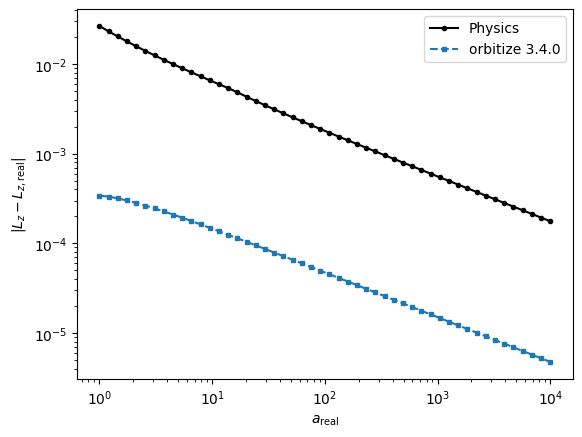

,a_real,Physics,orbitize
0,1.000000,0.026697,0.000341
1,1.206793,0.023264,0.000331
2,1.456348,0.020373,0.000317
3,1.757511,0.017927,0.000301
4,2.120951,0.015844,0.000283
5,2.559548,0.014060,0.000264
6,3.088844,0.012522,0.000245
7,3.727594,0.011189,0.000227
8,4.498433,0.010026,0.000210
9,5.428675,0.009005,0.000193


In [43]:
number_of_fit_points = 20
astrometric_error_mas = 0.20
parallax_mas = 1
mass_solar = 1
a_fit_values = np.geomspace(1, 10000, 50)
rng_fit = np.random.default_rng(seed + 3)
ra_noise_fit = rng_fit.normal(0, astrometric_error_mas, number_of_fit_points)
dec_noise_fit = rng_fit.normal(0, astrometric_error_mas, number_of_fit_points)

Lz_physics_values = []
Lz_orbitize_values = []

for a_real in a_fit_values:
    period_days = 365.25 * np.sqrt(a_real ** 3 / mass_solar)
    epochs_fit = np.linspace(0, period_days, number_of_fit_points, endpoint=False)
    ra_true, dec_true, _ = kepler.calc_orbit(
        epochs_fit,
        sma=a_real,
        ecc=0,
        inc=0,
        aop=0,
        pan=0,
        tau=0.13,
        plx=parallax_mas,
        mtot=mass_solar,
        tau_ref_epoch=0,
        use_c=False,
    )
    ra_observed = ra_true + ra_noise_fit
    dec_observed = dec_true + dec_noise_fit

    Lz_physics_values.append(
        estimate_Lz_physics(ra_observed, dec_observed, parallax=parallax_mas)
    )
    Lz_orbitize_values.append(
        estimate_Lz_orbitize(
            epochs_fit,
            ra_observed,
            dec_observed,
            astrometric_error_mas,
            parallax=parallax_mas,
            mass=mass_solar,
        )
    )

Lz_physics_values = np.asarray(Lz_physics_values)
Lz_orbitize_values = np.asarray(Lz_orbitize_values)
Lz_real_fit = np.sqrt(a_fit_values)
difference_physics_fit = np.abs(Lz_physics_values - Lz_real_fit)
difference_orbitize_fit = np.abs(Lz_orbitize_values - Lz_real_fit)

comparison_fit = pd.DataFrame(
    {
        'a_real': a_fit_values,
        'Physics': difference_physics_fit,
        'orbitize': difference_orbitize_fit,
    }
)

fig, ax = plt.subplots()
ax.plot(a_fit_values, difference_physics_fit, 'o-', markersize=3, color='k', label='Physics')
ax.plot(a_fit_values, difference_orbitize_fit, 's--', markersize=3, color='tab:blue', label='orbitize 3.4.0')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$a_{\mathrm{real}}$')
ax.set_ylabel(r'$|L_z - L_{z,\mathrm{real}}|$')
ax.legend()
plt.show()

comparison_fit

# con tiempo

La idea es definir, a partir de los puntos consecutivos, hallar distribucion del periodo, y por ende la distribución de a, y Lz

$\Delta \theta \rightarrow P \rightarrow a \rightarrow Lz$ 

$$
\mathbf r_1 = \mathbf r(a,\theta_1),
\qquad
\mathbf r_2 = \mathbf r(a,\theta_2)
$$

$$
\theta_2 = \theta_1 + \Delta\theta
$$

$$
\mathbf r_1 = \mathbf r(a,\theta_1),
\qquad
\mathbf r_2 = \mathbf r(a,\theta_1+\Delta\theta)
$$

Para una órbita circular en el plano $xy$:

$$
\mathbf r(a,\theta)
=
\begin{pmatrix}
a\cos\theta\\
a\sin\theta\\
0
\end{pmatrix}
$$

por lo tanto,

$$
\mathbf r_1
=
\begin{pmatrix}
a\cos\theta_1\\
a\sin\theta_1\\
0
\end{pmatrix},
\qquad
\mathbf r_2
=
\begin{pmatrix}
a\cos(\theta_1+\Delta\theta)\\
a\sin(\theta_1+\Delta\theta)\\
0
\end{pmatrix}.
$$

Las posiciones observadas son

$$
\mathbf d_1
=
\begin{pmatrix}
x_{1,\mathrm{obs}}\\
y_{1,\mathrm{obs}}\\
z_{1,\mathrm{obs}}
\end{pmatrix},
\qquad
\mathbf d_2
=
\begin{pmatrix}
x_{2,\mathrm{obs}}\\
y_{2,\mathrm{obs}}\\
z_{2,\mathrm{obs}}
\end{pmatrix}.
$$

Suponiendo errores gaussianos independientes,

$$
p(\mathbf d_i\mid a,\theta_i)
=
\frac{1}
{(2\pi)^{3/2}
\sigma_{x_i}\sigma_{y_i}\sigma_{z_i}}
\exp
\left[
-\frac{1}{2}
\left(
\frac{(x_{i,\mathrm{obs}}-a\cos\theta_i)^2}{\sigma_{x_i}^2}
+
\frac{(y_{i,\mathrm{obs}}-a\sin\theta_i)^2}{\sigma_{y_i}^2}
+
\frac{z_{i,\mathrm{obs}}^2}{\sigma_{z_i}^2}
\right)
\right].
$$

Para los dos puntos,

$$
p(D\mid a,\theta_1,\Delta\theta)
=
p(\mathbf d_1\mid a,\theta_1)\,
p(\mathbf d_2\mid a,\theta_1+\Delta\theta).
$$

El posterior conjunto es

$$
p(a,\theta_1,\Delta\theta\mid D)
\propto
p(D\mid a,\theta_1,\Delta\theta)\,
p(a,\theta_1,\Delta\theta).
$$

Finalmente, la distribución marginal de $\Delta\theta$ se obtiene integrando sobre
$a$ y $\theta_1$:

$$
p(\Delta\theta\mid D)
=
\int_0^{\infty}
\int_0^{2\pi}
p(a,\theta_1,\Delta\theta\mid D)
\,d\theta_1\,da.
$$

Equivalentemente,

$$
p(\Delta\theta\mid D)
\propto
p(\Delta\theta)
\int_0^{\infty}
\int_0^{2\pi}
p(D\mid a,\theta_1,\Delta\theta)\,
p(a)\,
p(\theta_1)
\,d\theta_1\,da.
$$

Imponiendo que el movimiento angular sea positivo,

$$
p(\Delta\theta)=0,
\qquad
\Delta\theta\leq 0,
$$

y, por ejemplo,

$$
0<\Delta\theta<2\pi.
$$

$$
P
=
\frac{2\pi\,\Delta t}{\Delta\theta}.
$$

En unidades geométricas, con

$$
G=M=c=1,
$$

la tercera ley de Kepler queda

$$
P^2
=
4\pi^2a^3.
$$

Por lo tanto,

$$
a
=
\left(
\frac{P}{2\pi}
\right)^{2/3}.
$$

Sustituyendo

$$
P
=
\frac{2\pi\,\Delta t}{\Delta\theta},
$$

se obtiene

$$
\boxed{
a
=
\left(
\frac{\Delta t}{\Delta\theta}
\right)^{2/3}
}.
$$

Para una órbita circular,

$$
v
=
\frac{1}{\sqrt{a}}.
$$

Como $m=1$, el momento angular orbital es

$$
L
=
av,
$$

por lo tanto,

$$
L
=
\sqrt{a}.
$$

La componente sobre el eje $z$ es

$$
L_z
=
L\cos i,
$$

de modo que

$$
\boxed{
L_z
=
\sqrt{a}\cos i
}.
$$

Sustituyendo la expresión para $a$,

$$
\boxed{
L_z
=
\left(
\frac{\Delta t}{\Delta\theta}
\right)^{1/3}
\cos i
}.
$$

Si además la órbita está en el plano ecuatorial, $i=0$, entonces

$$
\boxed{
L_z
=
\sqrt{a}
=
\left(
\frac{\Delta t}{\Delta\theta}
\right)^{1/3}
}.
$$

$$
L_z
=
\left(
\frac{\Delta t}{\Delta\theta}
\right)^{1/3}.
$$

Invirtiendo la transformación,

$$
L_z^3
=
\frac{\Delta t}{\Delta\theta},
$$

por lo tanto,

$$
\boxed{
\Delta\theta
=
\frac{\Delta t}{L_z^3}
}.
$$

El Jacobiano de la transformación es

$$
\frac{d\Delta\theta}{dL_z}
=
-\frac{3\Delta t}{L_z^4},
$$

de modo que

$$
\boxed{
\left|
\frac{d\Delta\theta}{dL_z}
\right|
=
\frac{3\Delta t}{L_z^4}
}.
$$

Aplicando la regla de transformación de variables,

$$
p_{L_z}(L_z\mid D)
=
p_{\Delta\theta}
\left(
\Delta\theta(L_z)\mid D
\right)
\left|
\frac{d\Delta\theta}{dL_z}
\right|.
$$

Finalmente,

$$
\boxed{
p_{L_z}(L_z\mid D)
=
p_{\Delta\theta}
\left(
\frac{\Delta t}{L_z^3}
\middle|D
\right)
\frac{3\Delta t}{L_z^4}
}.
$$

In [44]:
# Delta_theta -> P -> a -> Lz

from scipy.special import ive, logsumexp
from scipy.integrate import cumulative_trapezoid


def log_bessel_i0e(z):
    """log[I_0(z) e^{-z}]. scipy.special.ive devuelve nan cerca de z ~ 1e9."""
    z = np.asarray(z, dtype=float)
    values = np.empty_like(z)
    small = z < 1e3
    values[small] = np.log(ive(0, z[small]))
    z_large = z[~small]
    values[~small] = -0.5 * np.log(2 * np.pi * z_large) + np.log1p(
        1 / (8 * z_large) + 9 / (128 * z_large ** 2) + 225 / (3072 * z_large ** 3)
    )
    return values


def get_posterior_Lz_time(
    xs,
    ys,
    ts,
    sigma_x,
    sigma_y,
    zs=None,
    sigma_z=None,
    number_of_a=256,
    number_of_Lz=400,
    number_of_theta=512,
    refinements=3,
):
    """Posterior p(Lz | D) a partir de pares de puntos consecutivos y sus tiempos.

    Cada par (r_1, r_2) separado por un mismo Delta_t restringe Delta_theta. Se
    marginaliza sobre a y theta_1 con prior uniforme, se impone 0 < Delta_theta < 2 pi
    y se transforma con Lz = (Delta_t / Delta_theta)^(1/3), es decir
    p_Lz(Lz | D) = p_Delta_theta(Delta_t / Lz^3 | D) * 3 Delta_t / Lz^4.

    Los tiempos van en unidades geometricas (G = M = 1), donde P = 2 pi a^(3/2).
    Si el movimiento observado es retrogrado se refleja y -> -y, de modo que el
    posterior corresponde a |Lz|.
    """
    xs = np.asarray(xs, dtype=float)
    ys = np.asarray(ys, dtype=float)
    ts = np.asarray(ts, dtype=float)

    if not (xs.ndim == ys.ndim == ts.ndim == 1 and len(xs) == len(ys) == len(ts)):
        raise ValueError("xs, ys y ts deben ser arreglos unidimensionales de igual longitud.")
    if len(xs) < 2:
        raise ValueError("Se necesitan al menos dos observaciones para formar un par.")
    if sigma_x <= 0 or sigma_y <= 0:
        raise ValueError("Las desviaciones estandar deben ser positivas.")
    if zs is not None:
        zs = np.asarray(zs, dtype=float)
        if len(zs) != len(xs):
            raise ValueError("zs debe tener la misma longitud que xs.")
        if sigma_z is None or sigma_z <= 0:
            raise ValueError("Con zs se necesita sigma_z positivo.")

    order = np.argsort(ts)
    xs, ys, ts = xs[order], ys[order], ts[order]
    zs = None if zs is None else zs[order]

    # El formalismo impone Delta_theta > 0: si el movimiento es retrogrado se
    # refleja y -> -y y el posterior queda sobre |Lz|.
    angles = np.unwrap(np.arctan2(ys, xs))
    if angles[-1] < angles[0]:
        ys = -ys

    # Pares disjuntos: cada observacion entra en un solo par, de modo que los
    # factores de la verosimilitud son independientes.
    first = np.arange(0, len(xs) - 1, 2)
    second = first + 1
    delta_ts = ts[second] - ts[first]
    delta_t = float(np.median(delta_ts))
    if np.any(delta_ts <= 0):
        raise ValueError("Los pares deben estar separados por un Delta_t positivo.")
    if np.ptp(delta_ts) > 1e-6 * delta_t:
        raise ValueError("Este estimador asume el mismo Delta_t en todos los pares.")

    x1, y1 = xs[first], ys[first]
    x2, y2 = xs[second], ys[second]
    squared_radii = x1 ** 2 + y1 ** 2 + x2 ** 2 + y2 ** 2

    isotropic = bool(np.isclose(sigma_x, sigma_y)) and zs is None
    sigma = float(sigma_x)

    # Grilla de a: el radio observado la fija con precision ~ sigma.
    a_center = float(np.median(np.hypot(xs, ys)))
    a_half_width = 10 * max(sigma_x, sigma_y) + 1e-3 * a_center
    a_values = np.linspace(max(a_center - a_half_width, 1e-12), a_center + a_half_width, number_of_a)
    log_prior_a = np.zeros_like(a_values)  # prior uniforme en a

    theta_values = np.linspace(0, 2 * np.pi, number_of_theta, endpoint=False)
    log_theta_weight = np.log(2 * np.pi / number_of_theta)

    def log_pairs_isotropic(cos_delta, sin_delta):
        """Marginal analitica en theta_1 cuando sigma_x = sigma_y y no hay z."""
        # sum_i r_i . u(theta_i) = amplitude * cos(theta_1 - fase)
        amplitude_x = x1[:, None] + x2[:, None] * cos_delta + y2[:, None] * sin_delta
        amplitude_y = y1[:, None] + y2[:, None] * cos_delta - x2[:, None] * sin_delta
        amplitude = np.hypot(amplitude_x, amplitude_y)[None, :, :]
        a_block = a_values[:, None, None]
        # int dtheta_1 exp[(a * amplitude / sigma^2) cos(theta_1 - fase)] = 2 pi I_0(a * amplitude / sigma^2)
        return (
            -((a_block - amplitude / 2) ** 2) / sigma ** 2
            - (squared_radii[None, :, None] / 2 - amplitude ** 2 / 4) / sigma ** 2
            + log_bessel_i0e(a_block * amplitude / sigma ** 2)
        )

    def log_pairs_general(cos_delta, sin_delta):
        """Marginal numerica en theta_1 para sigmas distintas y observaciones en z."""
        log_pairs = np.empty((len(a_values), len(first), cos_delta.shape[1]))
        cos_theta = np.cos(theta_values)[:, None]
        sin_theta = np.sin(theta_values)[:, None]
        cos_theta_2 = cos_theta * cos_delta - sin_theta * sin_delta
        sin_theta_2 = sin_theta * cos_delta + cos_theta * sin_delta
        a_block = a_values[:, None, None]
        for index in range(len(first)):
            chi_squared = (
                ((x1[index] - a_block * cos_theta[None, :, :]) / sigma_x) ** 2
                + ((y1[index] - a_block * sin_theta[None, :, :]) / sigma_y) ** 2
                + ((x2[index] - a_block * cos_theta_2[None, :, :]) / sigma_x) ** 2
                + ((y2[index] - a_block * sin_theta_2[None, :, :]) / sigma_y) ** 2
            )
            if zs is not None:
                chi_squared = chi_squared + (
                    zs[first[index]] ** 2 + zs[second[index]] ** 2
                ) / sigma_z ** 2
            log_pairs[:, index, :] = logsumexp(-chi_squared / 2, axis=1) + log_theta_weight
        return log_pairs

    def log_posterior_delta_theta(delta_theta, block_size=64):
        """log p(Delta_theta | D) sin normalizar, marginalizando a y theta_1."""
        values = np.empty_like(delta_theta)
        for start in range(0, len(delta_theta), block_size):
            stop = min(start + block_size, len(delta_theta))
            cos_delta = np.cos(delta_theta[start:stop])[None, :]
            sin_delta = np.sin(delta_theta[start:stop])[None, :]
            log_pairs = (
                log_pairs_isotropic(cos_delta, sin_delta)
                if isotropic
                else log_pairs_general(cos_delta, sin_delta)
            )
            log_likelihood = np.sum(log_pairs, axis=1) + log_prior_a[:, None]
            shift = np.max(log_likelihood, axis=0)
            integrand = np.exp(log_likelihood - shift[None, :])
            values[start:stop] = shift + np.log(np.trapezoid(integrand, a_values, axis=0))
        return values

    def log_posterior_Lz(Lz_values):
        delta_theta = delta_t / Lz_values ** 3
        # Prior: movimiento angular positivo y menos de una vuelta entre observaciones.
        valid = (delta_theta > 0) & (delta_theta < 2 * np.pi)
        if not np.any(valid):
            raise ValueError("La grilla de Lz cae fuera de 0 < Delta_theta < 2 pi.")
        values = np.full_like(Lz_values, -np.inf)
        # Jacobiano |d Delta_theta / d Lz| = 3 Delta_t / Lz^4.
        values[valid] = log_posterior_delta_theta(delta_theta[valid]) + np.log(
            3 * delta_t / Lz_values[valid] ** 4
        )
        return values

    # La grilla en Lz se refina: el posterior puede ser mucho mas angosto que la
    # escala inicial cuando sigma / a es pequeno.
    Lz_center = np.sqrt(a_center)
    relative_width = float(np.clip(
        10 * np.sqrt(2) * max(sigma_x, sigma_y) * Lz_center ** 3
        / (3 * a_center * delta_t * np.sqrt(len(first))),
        1e-9,
        0.9,
    ))

    for iteration in range(refinements):
        Lz_values = np.linspace(
            max(Lz_center * (1 - relative_width), 1e-12),
            Lz_center * (1 + relative_width),
            number_of_Lz,
        )
        log_values = log_posterior_Lz(Lz_values)
        finite = np.isfinite(log_values)
        if not finite.any():
            raise ValueError("El posterior es nulo en toda la grilla de Lz.")
        posterior = np.exp(log_values - log_values[finite].max())
        posterior /= np.trapezoid(posterior, Lz_values)
        if iteration < refinements - 1:
            mean = np.trapezoid(posterior * Lz_values, Lz_values)
            variance = np.trapezoid(posterior * (Lz_values - mean) ** 2, Lz_values)
            Lz_center = float(mean)
            relative_width = float(np.clip(6 * np.sqrt(variance) / Lz_center, 1e-9, 0.9))

    cdf = cumulative_trapezoid(posterior, Lz_values, initial=0.0)
    cdf /= cdf[-1]
    median_Lz = float(np.interp(0.5, cdf, Lz_values))

    def p_Lz(Lz):
        Lz = np.asarray(Lz, dtype=float)
        values = np.interp(Lz, Lz_values, posterior, left=0.0, right=0.0)
        return float(values) if Lz.ndim == 0 else values

    return p_Lz, median_Lz

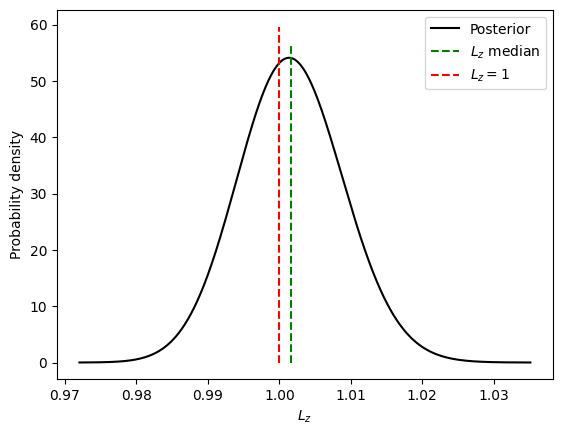

,method,median_Lz
0,Cartesian Gaussian,0.992169
1,RA and DEC Gaussian,1.001478
2,Time,1.001577


In [45]:
p_Lz_time, median_Lz_time = get_posterior_Lz_time(
    xs_obs, ys_obs, ts_obs, sigma_proper, sigma_proper
)

# Rango de graficacion: soporte efectivo del posterior.
Lz_scan = np.linspace(1e-6, 3 * median_Lz_time, 4001)
posterior_scan = p_Lz_time(Lz_scan)
support = Lz_scan[posterior_scan > 1e-4 * posterior_scan.max()]
Lz_values_time = np.linspace(support.min(), support.max(), 500)

plt.plot(Lz_values_time, p_Lz_time(Lz_values_time), 'k', label='Posterior')
plt.xlabel(r"$L_z$")
plt.ylabel("Probability density")

plt.vlines(median_Lz_time, ymin=0, ymax=plt.gca().get_ylim()[1], color='g', linestyle='--', label=r"$L_z$ median")
plt.vlines(np.sqrt(1), ymin=0, ymax=plt.gca().get_ylim()[1], color='r', linestyle='--', label=r"$L_z = 1$")

plt.legend()
plt.show()

pd.DataFrame(
    {
        'method': ['Cartesian Gaussian', 'RA and DEC Gaussian', 'Time'],
        'median_Lz': [median_Lz_gaussian, median_Lz_RA_DEC, median_Lz_time],
    }
)

### Comparación de los tres estimadores

El mismo experimento controlado de la sección anterior, agregando el posterior de $L_z$
construido a partir de $\Delta\theta$ y $\Delta t$.

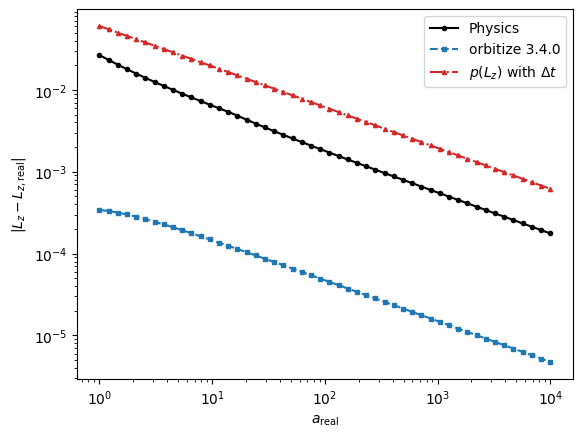

,a_real,Physics,orbitize,Time posterior
0,1.000000,0.026697,0.000341,0.060563
1,1.206793,0.023264,0.000331,0.055087
2,1.456348,0.020373,0.000317,0.050173
3,1.757511,0.017927,0.000301,0.045734
4,2.120951,0.015844,0.000283,0.041703
5,2.559548,0.014060,0.000264,0.038033
6,3.088844,0.012522,0.000245,0.034686
7,3.727594,0.011189,0.000227,0.031631
8,4.498433,0.010026,0.000210,0.028841
9,5.428675,0.009005,0.000193,0.026293


In [46]:
from astropy import constants as consts, units as u

# Periodo de una orbita con a = 1 AU y M = 1 Msun, con las constantes de orbitize.
# Los tiempos geometricos (G = M = 1, P = 2 pi a^(3/2)) son 2 pi t / days_per_orbit_1AU.
days_per_orbit_1AU = float(
    np.sqrt(4 * np.pi ** 2 * (1 * u.AU) ** 3 / (consts.G * (1 * u.Msun))).to(u.day).value
)

Lz_time_fit_values = []

for a_real in a_fit_values:
    period_days = 365.25 * np.sqrt(a_real ** 3 / mass_solar)
    epochs_fit = np.linspace(0, period_days, number_of_fit_points, endpoint=False)
    ra_true, dec_true, _ = kepler.calc_orbit(
        epochs_fit,
        sma=a_real,
        ecc=0,
        inc=0,
        aop=0,
        pan=0,
        tau=0.13,
        plx=parallax_mas,
        mtot=mass_solar,
        tau_ref_epoch=0,
        use_c=False,
    )
    ra_observed = ra_true + ra_noise_fit
    dec_observed = dec_true + dec_noise_fit

    _, median_Lz_time_fit = get_posterior_Lz_time(
        ra_observed / parallax_mas,
        dec_observed / parallax_mas,
        2 * np.pi * epochs_fit / days_per_orbit_1AU,
        astrometric_error_mas / parallax_mas,
        astrometric_error_mas / parallax_mas,
    )
    Lz_time_fit_values.append(median_Lz_time_fit)

Lz_time_fit_values = np.asarray(Lz_time_fit_values)
difference_time_fit = np.abs(Lz_time_fit_values - Lz_real_fit)

comparison_fit_time = pd.DataFrame(
    {
        'a_real': a_fit_values,
        'Physics': difference_physics_fit,
        'orbitize': difference_orbitize_fit,
        'Time posterior': difference_time_fit,
    }
)

fig, ax = plt.subplots()
ax.plot(a_fit_values, difference_physics_fit, 'o-', markersize=3, color='k', label='Physics')
ax.plot(a_fit_values, difference_orbitize_fit, 's--', markersize=3, color='tab:blue', label='orbitize 3.4.0')
ax.plot(a_fit_values, difference_time_fit, '^-.', markersize=3, color='tab:red', label=r'$p(L_z)$ with $\Delta t$')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$a_{\mathrm{real}}$')
ax.set_ylabel(r'$|L_z - L_{z,\mathrm{real}}|$')
ax.legend()
plt.show()

comparison_fit_time

# Con ambos métodos

$$
\mathbf r_{\mathrm{mod}}(t;a,\theta_0)
=
\begin{pmatrix}
a\cos\theta(t)\\
a\sin\theta(t)\\
0
\end{pmatrix}.
$$

Para una órbita circular, con

$$
G=M=c=m=1,
$$

la velocidad angular está relacionada con el radio por

$$
\omega(a)
=
a^{-3/2}.
$$

Por lo tanto,

$$
\theta(t)
=
\theta_0+\omega(a)(t-t_0),
$$

es decir,

$$
\boxed{
\theta(t)
=
\theta_0+
\frac{t-t_0}{a^{3/2}}
}.
$$

Sustituyendo en la posición orbital,

$$
\boxed{
\mathbf r_{\mathrm{mod}}(t;a,\theta_0)
=
\begin{pmatrix}
a\cos\left(
\theta_0+\dfrac{t-t_0}{a^{3/2}}
\right)\\[2mm]
a\sin\left(
\theta_0+\dfrac{t-t_0}{a^{3/2}}
\right)\\[2mm]
0
\end{pmatrix}
}.
$$

De esta forma, el mismo parámetro $a$ determina simultáneamente la
distancia radial,

$$
\|\mathbf r_{\mathrm{mod}}(t)\|=a,
$$

y el desplazamiento angular entre dos tiempos,

$$
\Delta\theta
=
\frac{\Delta t}{a^{3/2}}.
$$

Sean las observaciones

$$
D=
\left\{
x_i,y_i,z_i,t_i
\right\}_{i=1}^{N},
$$

con incertidumbres gaussianas

$$
\sigma_{x_i},
\qquad
\sigma_{y_i},
\qquad
\sigma_{z_i}.
$$

La función de likelihood conjunta puede escribirse como

$$
p(D\mid a,\theta_0)
=
\prod_{i=1}^{N}
\frac{1}
{(2\pi)^{3/2}
\sigma_{x_i}\sigma_{y_i}\sigma_{z_i}}
\exp
\left[
-\frac{1}{2}
\chi_i^2(a,\theta_0)
\right],
$$

donde

$$
\chi_i^2(a,\theta_0)
=
\frac{
\left[
x_i-x_{\mathrm{mod}}(t_i;a,\theta_0)
\right]^2
}{
\sigma_{x_i}^2
}
+
\frac{
\left[
y_i-y_{\mathrm{mod}}(t_i;a,\theta_0)
\right]^2
}{
\sigma_{y_i}^2
}
+
\frac{
\left[
z_i-z_{\mathrm{mod}}(t_i;a,\theta_0)
\right]^2
}{
\sigma_{z_i}^2
}.
$$

Equivalentemente, la log-likelihood es

$$
\ln p(D\mid a,\theta_0)
=
-\frac{1}{2}
\sum_{i=1}^{N}
\left[
\frac{
\left[
x_i-x_{\mathrm{mod}}(t_i;a,\theta_0)
\right]^2
}{
\sigma_{x_i}^2
}
+
\frac{
\left[
y_i-y_{\mathrm{mod}}(t_i;a,\theta_0)
\right]^2
}{
\sigma_{y_i}^2
}
+
\frac{
\left[
z_i-z_{\mathrm{mod}}(t_i;a,\theta_0)
\right]^2
}{
\sigma_{z_i}^2
}
\right]
+\mathrm{const}.
$$

El posterior conjunto es

$$
\boxed{
p(a,\theta_0\mid D)
\propto
p(D\mid a,\theta_0)\,
p(a,\theta_0)
}.
$$

Marginalizando sobre la fase inicial,

$$
\boxed{
p(a\mid D)
=
\int_{0}^{2\pi}
p(a,\theta_0\mid D)\,
d\theta_0
}.
$$

Para una órbita circular ecuatorial, con $m=1$,

$$
\boxed{
L_z=\sqrt{a}
}.
$$

La transformación inversa es

$$
a=L_z^2,
$$

y el Jacobiano correspondiente es

$$
\left|
\frac{da}{dL_z}
\right|
=
2L_z.
$$

Por lo tanto, la distribución de probabilidad de $L_z$ es

$$
p_{L_z}(L_z\mid D)
=
p_a(L_z^2\mid D)
\left|
\frac{da}{dL_z}
\right|,
$$

es decir,

$$
\boxed{
p_{L_z}(L_z\mid D)
=
2L_z\,
p_a(L_z^2\mid D)
}.
$$

In [47]:
# Radios y tiempos a la vez: el mismo a fija ||r|| y omega = a^(-3/2)

def get_posterior_Lz_joint(
    xs,
    ys,
    ts,
    sigma_x,
    sigma_y,
    zs=None,
    sigma_z=None,
    gamma=None,
    number_of_a=20001,
    number_of_theta=512,
    refinements=3,
):
    """Posterior p(Lz | D) con el modelo r_mod(t; a, theta_0) de la seccion anterior.

    El mismo parametro a fija el radio, ||r_mod|| = a, y la velocidad angular,
    omega = a^(-3/2), de modo que theta(t) = theta_0 + (t - t_0) / a^(3/2).
    Se marginaliza la fase inicial theta_0 con prior uniforme (analiticamente si
    sigma_x = sigma_y y no hay z, numericamente en el caso general), el prior en a
    es uniforme, y al final p_Lz(Lz | D) = 2 Lz p_a(Lz^2 | D).

    La profundidad zs puede entrar de dos formas: con sigma_z, como un residuo
    gaussiano respecto de z_mod = 0 (constante en a, no informa), o con gamma,
    como la distribucion del cusp P(z | R, gamma) evaluada en R = a,
    P(z | R, gamma) ~ R^(gamma - 1) / (R^2 + z^2)^(gamma / 2), que si depende de a.

    Los tiempos van en unidades geometricas (G = M = 1), donde P = 2 pi a^(3/2).
    Si el movimiento observado es retrogrado se refleja y -> -y y el posterior
    corresponde a |Lz|.
    """
    xs = np.asarray(xs, dtype=float)
    ys = np.asarray(ys, dtype=float)
    ts = np.asarray(ts, dtype=float)

    if not (xs.ndim == ys.ndim == ts.ndim == 1 and len(xs) == len(ys) == len(ts)):
        raise ValueError("xs, ys y ts deben ser arreglos unidimensionales de igual longitud.")
    if len(xs) < 2:
        raise ValueError("Se necesitan al menos dos observaciones.")
    if sigma_x <= 0 or sigma_y <= 0:
        raise ValueError("Las desviaciones estandar deben ser positivas.")
    if zs is not None:
        zs = np.asarray(zs, dtype=float)
        if len(zs) != len(xs):
            raise ValueError("zs debe tener la misma longitud que xs.")
        if gamma is None and (sigma_z is None or sigma_z <= 0):
            raise ValueError("Con zs se necesita sigma_z positivo o gamma.")
        if gamma is not None and gamma <= 1:
            raise ValueError("La distribucion del cusp necesita gamma > 1.")

    order = np.argsort(ts)
    xs, ys, ts = xs[order], ys[order], ts[order]
    zs = None if zs is None else zs[order]

    # El modelo supone omega > 0: si el movimiento es retrogrado se refleja
    # y -> -y y el posterior queda sobre |Lz|.
    angles = np.unwrap(np.arctan2(ys, xs))
    if angles[-1] < angles[0]:
        ys = -ys

    number_of_points = len(xs)
    elapsed = ts - ts[0]
    squared_radii = float(np.sum(xs ** 2 + ys ** 2))
    use_cusp = zs is not None and gamma is not None
    # El factor del cusp solo depende de a y de z, no de theta_0, asi que no
    # rompe la marginalizacion analitica de la fase.
    isotropic = bool(np.isclose(sigma_x, sigma_y)) and (zs is None or use_cusp)
    sigma = float(sigma_x)
    # z_mod = 0 para una orbita ecuatorial: el termino gaussiano en z no depende de a.
    log_z_penalty = (
        0.0 if zs is None or use_cusp else float(np.sum(zs ** 2)) / (2 * sigma_z ** 2)
    )

    def log_cusp(a_block):
        """sum_i log P(z_i | R = a, gamma), sin la constante de normalizacion."""
        if not use_cusp:
            return 0.0
        return number_of_points * (gamma - 1) * np.log(a_block) - (gamma / 2) * np.sum(
            np.log(a_block[:, None] ** 2 + zs[None, :] ** 2), axis=1
        )

    theta_values = np.linspace(0, 2 * np.pi, number_of_theta, endpoint=False)
    log_theta_weight = np.log(2 * np.pi / number_of_theta)

    def log_posterior_a(a_values, block_size=256):
        """log p(a | D) sin normalizar, con theta_0 marginalizada."""
        values = np.empty_like(a_values)
        for start in range(0, len(a_values), block_size):
            stop = min(start + block_size, len(a_values))
            block = a_values[start:stop][:, None]
            # theta(t_i) - theta_0 = (t_i - t_0) / a^(3/2)
            phases = elapsed[None, :] / block ** 1.5
            cos_phase = np.cos(phases)
            sin_phase = np.sin(phases)

            if isotropic:
                # sum_i r_i . u(theta_i) = amplitude * cos(theta_0 - fase)
                amplitude_x = np.sum(xs[None, :] * cos_phase + ys[None, :] * sin_phase, axis=1)
                amplitude_y = np.sum(ys[None, :] * cos_phase - xs[None, :] * sin_phase, axis=1)
                amplitude = np.hypot(amplitude_x, amplitude_y)
                a_block = block[:, 0]
                # int dtheta_0 exp[(a * amplitude / sigma^2) cos(theta_0 - fase)] = 2 pi I_0(...)
                # -N a^2 / (2 sigma^2) + a * amplitude / sigma^2 se completa a cuadrado para
                # evitar la cancelacion entre terminos de orden a^2 / sigma^2.
                values[start:stop] = (
                    -number_of_points * (a_block - amplitude / number_of_points) ** 2
                    / (2 * sigma ** 2)
                    + (amplitude ** 2 / number_of_points - squared_radii) / (2 * sigma ** 2)
                    + log_bessel_i0e(a_block * amplitude / sigma ** 2)
                    + log_cusp(a_block)
                )
            else:
                cos_theta = np.cos(theta_values)[None, :, None]
                sin_theta = np.sin(theta_values)[None, :, None]
                cos_total = cos_theta * cos_phase[:, None, :] - sin_theta * sin_phase[:, None, :]
                sin_total = sin_theta * cos_phase[:, None, :] + cos_theta * sin_phase[:, None, :]
                model_x = block[:, :, None] * cos_total
                model_y = block[:, :, None] * sin_total
                chi_squared = np.sum(
                    ((xs[None, None, :] - model_x) / sigma_x) ** 2
                    + ((ys[None, None, :] - model_y) / sigma_y) ** 2,
                    axis=2,
                )
                values[start:stop] = (
                    logsumexp(-chi_squared / 2, axis=1)
                    + log_theta_weight
                    - log_z_penalty
                    + log_cusp(block[:, 0])
                )
        return values

    # Grilla inicial: el radio observado fija a con precision ~ sigma / sqrt(N).
    a_center = float(np.median(np.hypot(xs, ys)))
    relative_width = float(np.clip(
        8 * max(sigma_x, sigma_y) / (a_center * np.sqrt(number_of_points)), 1e-9, 0.9
    ))

    for iteration in range(refinements):
        a_values = np.linspace(
            max(a_center * (1 - relative_width), 1e-12),
            a_center * (1 + relative_width),
            number_of_a if iteration == 0 else max(number_of_a // 10, 501),
        )
        log_values = log_posterior_a(a_values)
        posterior_a = np.exp(log_values - log_values.max())
        posterior_a /= np.trapezoid(posterior_a, a_values)
        if iteration < refinements - 1:
            # El maximo global evita los modos alias de la fase acumulada.
            peak = a_values[np.argmax(log_values)]
            mean = np.trapezoid(posterior_a * a_values, a_values)
            variance = np.trapezoid(posterior_a * (a_values - mean) ** 2, a_values)
            a_center = float(peak)
            relative_width = float(np.clip(
                8 * np.sqrt(variance) / a_center, 1e-9, relative_width
            ))

    # Lz = sqrt(a): p_Lz(Lz) = p_a(Lz^2) * |da / dLz| = 2 Lz p_a(Lz^2).
    Lz_values = np.sqrt(a_values)
    posterior_Lz = posterior_a * 2 * Lz_values
    posterior_Lz /= np.trapezoid(posterior_Lz, Lz_values)

    cdf = cumulative_trapezoid(posterior_Lz, Lz_values, initial=0.0)
    cdf /= cdf[-1]
    median_Lz = float(np.interp(0.5, cdf, Lz_values))

    def p_Lz(Lz):
        Lz = np.asarray(Lz, dtype=float)
        values = np.interp(Lz, Lz_values, posterior_Lz, left=0.0, right=0.0)
        return float(values) if Lz.ndim == 0 else values

    return p_Lz, median_Lz

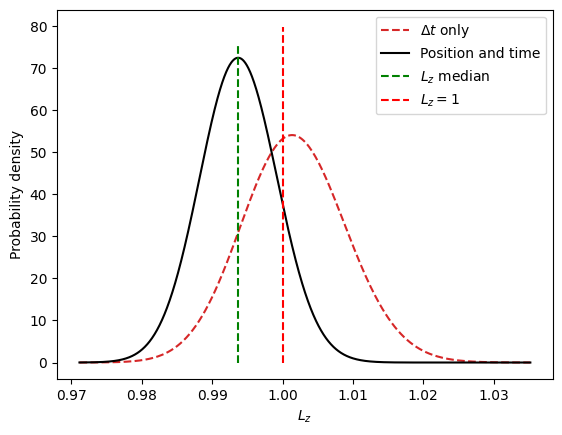

,method,median_Lz
0,Cartesian Gaussian,0.992169
1,RA and DEC Gaussian,1.001478
2,Time,1.001577
3,Position and time,0.993739


In [48]:
p_Lz_joint, median_Lz_joint = get_posterior_Lz_joint(
    xs_obs, ys_obs, ts_obs, sigma_proper, sigma_proper
)

# Rango de graficacion: soporte efectivo de cada posterior.
Lz_scan = np.linspace(1e-6, 3 * median_Lz_joint, 4001)
support = np.concatenate([
    Lz_scan[p_Lz_time(Lz_scan) > 1e-4 * p_Lz_time(Lz_scan).max()],
    Lz_scan[p_Lz_joint(Lz_scan) > 1e-4 * p_Lz_joint(Lz_scan).max()],
])
Lz_values_joint = np.linspace(support.min(), support.max(), 2000)

plt.plot(Lz_values_joint, p_Lz_time(Lz_values_joint), color='tab:red', linestyle='--', label=r'$\Delta t$ only')
plt.plot(Lz_values_joint, p_Lz_joint(Lz_values_joint), 'k', label='Position and time')
plt.xlabel(r"$L_z$")
plt.ylabel("Probability density")

plt.vlines(median_Lz_joint, ymin=0, ymax=plt.gca().get_ylim()[1], color='g', linestyle='--', label=r"$L_z$ median")
plt.vlines(np.sqrt(1), ymin=0, ymax=plt.gca().get_ylim()[1], color='r', linestyle='--', label=r"$L_z = 1$")

plt.legend()
plt.show()

pd.DataFrame(
    {
        'method': ['Cartesian Gaussian', 'RA and DEC Gaussian', 'Time', 'Position and time'],
        'median_Lz': [median_Lz_gaussian, median_Lz_RA_DEC, median_Lz_time, median_Lz_joint],
    }
)

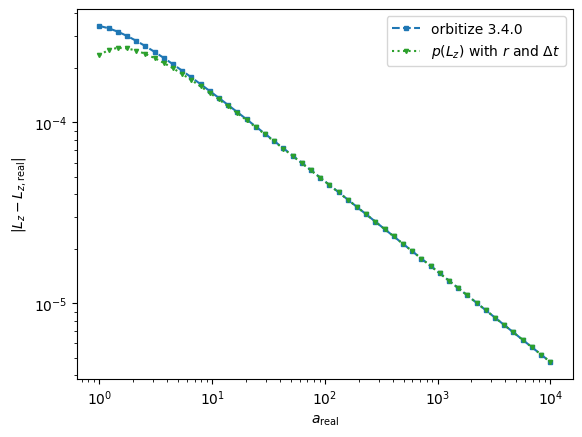

,a_real,Physics,orbitize,Time posterior,Position and time posterior
0,1.000000,0.026697,0.000341,0.060563,0.000234
1,1.206793,0.023264,0.000331,0.055087,0.000252
2,1.456348,0.020373,0.000317,0.050173,0.000258
3,1.757511,0.017927,0.000301,0.045734,0.000256
4,2.120951,0.015844,0.000283,0.041703,0.000249
5,2.559548,0.014060,0.000264,0.038033,0.000239
6,3.088844,0.012522,0.000245,0.034686,0.000227
7,3.727594,0.011189,0.000227,0.031631,0.000213
8,4.498433,0.010026,0.000210,0.028841,0.000199
9,5.428675,0.009005,0.000193,0.026293,0.000185


In [49]:
Lz_joint_fit_values = []

for a_real in a_fit_values:
    period_days = 365.25 * np.sqrt(a_real ** 3 / mass_solar)
    epochs_fit = np.linspace(0, period_days, number_of_fit_points, endpoint=False)
    ra_true, dec_true, _ = kepler.calc_orbit(
        epochs_fit,
        sma=a_real,
        ecc=0,
        inc=0,
        aop=0,
        pan=0,
        tau=0.13,
        plx=parallax_mas,
        mtot=mass_solar,
        tau_ref_epoch=0,
        use_c=False,
    )
    ra_observed = ra_true + ra_noise_fit
    dec_observed = dec_true + dec_noise_fit

    _, median_Lz_joint_fit = get_posterior_Lz_joint(
        ra_observed / parallax_mas,
        dec_observed / parallax_mas,
        2 * np.pi * epochs_fit / days_per_orbit_1AU,
        astrometric_error_mas / parallax_mas,
        astrometric_error_mas / parallax_mas,
    )
    Lz_joint_fit_values.append(median_Lz_joint_fit)

Lz_joint_fit_values = np.asarray(Lz_joint_fit_values)
difference_joint_fit = np.abs(Lz_joint_fit_values - Lz_real_fit)

comparison_fit_joint = pd.DataFrame(
    {
        'a_real': a_fit_values,
        'Physics': difference_physics_fit,
        'orbitize': difference_orbitize_fit,
        'Time posterior': difference_time_fit,
        'Position and time posterior': difference_joint_fit,
    }
)

fig, ax = plt.subplots()
# ax.plot(a_fit_values, difference_physics_fit, 'o-', markersize=3, color='k', label='Physics')
# ax.plot(a_fit_values, difference_time_fit, '^-.', markersize=3, color='tab:red', label=r'$p(L_z)$ with $\Delta t$')
ax.plot(a_fit_values, difference_orbitize_fit, 's--', markersize=3, color='tab:blue', label='orbitize 3.4.0')
ax.plot(a_fit_values, difference_joint_fit, 'v:', markersize=3, color='tab:green', label=r'$p(L_z)$ with $r$ and $\Delta t$')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$a_{\mathrm{real}}$')
ax.set_ylabel(r'$|L_z - L_{z,\mathrm{real}}|$')
ax.legend()
plt.show()

comparison_fit_joint

# Pruebas Sólo entre este último método y el de orbitize 3.4.0

Ahora, haremos las mismas pruebas de la sección anterior, pero comparando únicamente el método de orbitize 3.4.0 y el método que combina la información de la distancia y del tiempo. 

## Pruebas con una distribución de error en la posición.

Hasta ahora habíamos considerado que no había error es z, o sea, la profundidad. AHora, introduzcamos dicho error.

$$
R=\sqrt{x^2+y^2},
\qquad
r=\sqrt{R^2+z^2}
$$

$$
\rho(r)\propto r^{-\gamma}
$$

$$
P(z\mid R,\gamma)
=
\frac{
\rho\!\left(\sqrt{R^2+z^2}\right)
}{
\displaystyle
\int_{-\infty}^{+\infty}
\rho\!\left(\sqrt{R^2+z'^2}\right)\,dz'
}
$$

$$
P(z\mid R,\gamma)
=
\frac{
\Gamma\!\left(\frac{\gamma}{2}\right)
}{
\sqrt{\pi}\,
\Gamma\!\left(\frac{\gamma-1}{2}\right)
}
\frac{
R^{\gamma-1}
}{
\left(R^2+z^2\right)^{\gamma/2}
}
$$

$$
P(z\mid x,y,\gamma)
=
\frac{
\Gamma\!\left(\frac{\gamma}{2}\right)
}{
\sqrt{\pi}\,
\Gamma\!\left(\frac{\gamma-1}{2}\right)
}
\frac{
\left(x^2+y^2\right)^{(\gamma-1)/2}
}{
\left(x^2+y^2+z^2\right)^{\gamma/2}
}
$$

$$
P(x,y,z)
=
P(x,y)\,
P(z\mid x,y,\gamma)
$$

$$
\gamma = 2.06\pm0.13
$$

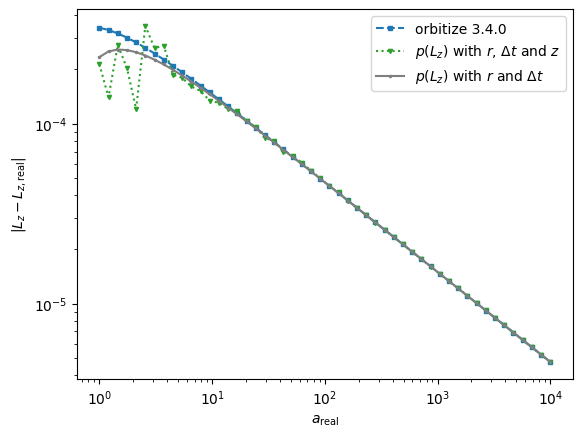

,a_real,orbitize,Position and time with z,Position and time without z
0,1.000000,0.000341,0.000214,0.000234
1,1.206793,0.000331,0.000140,0.000252
2,1.456348,0.000317,0.000273,0.000258
3,1.757511,0.000301,0.000204,0.000256
4,2.120951,0.000283,0.000120,0.000249
5,2.559548,0.000264,0.000349,0.000239
6,3.088844,0.000245,0.000263,0.000227
7,3.727594,0.000227,0.000271,0.000213
8,4.498433,0.000210,0.000187,0.000199
9,5.428675,0.000193,0.000180,0.000185


In [50]:
# Error en la profundidad con el perfil del cusp: rho(r) ~ r^-gamma

from scipy.stats import t as student_t

# rho(r) ~ r^-gamma da P(z | R, gamma) ~ R^(gamma-1) / (R^2 + z^2)^(gamma/2), que es una
# t de Student con nu = gamma - 1 grados de libertad y escala R / sqrt(gamma - 1).
gamma_cusp = 2.06
rng_cusp = np.random.default_rng(seed + 4)

Lz_orbitize_cusp_values = []
Lz_joint_cusp_values = []
Lz_joint_flat_values = []

for a_real in a_fit_values:
    period_days = 365.25 * np.sqrt(a_real ** 3 / mass_solar)
    epochs_fit = np.linspace(0, period_days, number_of_fit_points, endpoint=False)
    ra_true, dec_true, _ = kepler.calc_orbit(
        epochs_fit,
        sma=a_real,
        ecc=0,
        inc=0,
        aop=0,
        pan=0,
        tau=0.13,
        plx=parallax_mas,
        mtot=mass_solar,
        tau_ref_epoch=0,
        use_c=False,
    )
    ra_observed = (ra_true + ra_noise_fit) / parallax_mas
    dec_observed = (dec_true + dec_noise_fit) / parallax_mas
    epochs_geometric = 2 * np.pi * epochs_fit / days_per_orbit_1AU

    projected_radii = np.hypot(ra_observed, dec_observed)
    zs_observed = student_t.rvs(
        df=gamma_cusp - 1,
        scale=projected_radii / np.sqrt(gamma_cusp - 1),
        random_state=rng_cusp,
    )

    Lz_orbitize_cusp_values.append(
        estimate_Lz_orbitize(
            epochs_fit,
            ra_observed * parallax_mas,
            dec_observed * parallax_mas,
            astrometric_error_mas,
            parallax=parallax_mas,
            mass=mass_solar,
        )
    )
    Lz_joint_cusp_values.append(
        get_posterior_Lz_joint(
            ra_observed,
            dec_observed,
            epochs_geometric,
            astrometric_error_mas / parallax_mas,
            astrometric_error_mas / parallax_mas,
            zs=zs_observed,
            gamma=gamma_cusp,
        )[1]
    )
    Lz_joint_flat_values.append(
        get_posterior_Lz_joint(
            ra_observed,
            dec_observed,
            epochs_geometric,
            astrometric_error_mas / parallax_mas,
            astrometric_error_mas / parallax_mas,
        )[1]
    )

Lz_orbitize_cusp_values = np.asarray(Lz_orbitize_cusp_values)
Lz_joint_cusp_values = np.asarray(Lz_joint_cusp_values)
Lz_joint_flat_values = np.asarray(Lz_joint_flat_values)

difference_orbitize_cusp = np.abs(Lz_orbitize_cusp_values - Lz_real_fit)
difference_joint_cusp = np.abs(Lz_joint_cusp_values - Lz_real_fit)
difference_joint_flat = np.abs(Lz_joint_flat_values - Lz_real_fit)

comparison_cusp = pd.DataFrame(
    {
        'a_real': a_fit_values,
        'orbitize': difference_orbitize_cusp,
        'Position and time with z': difference_joint_cusp,
        'Position and time without z': difference_joint_flat,
    }
)

fig, ax = plt.subplots()
ax.plot(a_fit_values, difference_orbitize_cusp, 's--', markersize=3, color='tab:blue', label='orbitize 3.4.0')
ax.plot(a_fit_values, difference_joint_cusp, 'v:', markersize=3, color='tab:green', label=r'$p(L_z)$ with $r$, $\Delta t$ and $z$')
ax.plot(a_fit_values, difference_joint_flat, '.-', markersize=3, color='tab:gray', label=r'$p(L_z)$ with $r$ and $\Delta t$')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$a_{\mathrm{real}}$')
ax.set_ylabel(r'$|L_z - L_{z,\mathrm{real}}|$')
ax.legend()
plt.show()

comparison_cusp

## Pruebas cambiando la inclinación

Para estas pruebas, usaremos la distribución de error anterior, pero cambiando tanbien la inclinación de la orbita respecto a la visual. Esto tambien cambia el alineamiento entre el plano de la orbita y el plano de la visual, lo que hace que la proyección de la orbita en el plano de la visual sea una elipse. 

En lugar de usar las graficas que llevavamos, como ahora variaremos el semieje mayor y la inclinación, vamos a usar un mapa de color. Este mapa estará escalado de modo que rojo sea si la estimación de Lz es mayor que el valor real, azul si es menor y morado si es igual.

En lugar de la gráfica con la que veníamos trabajando, esta vez usaremos una grafica de colores. El rojo indica que la estimación de Lz h

El mapa muestra la diferencia de errores relativos entre el método propio y orbitize 3.4.0: rojo si el método propio queda más lejos del valor real, azul si queda más cerca, y morado si ambos empatan. Se comparan dos versiones del método propio: la que supone la órbita de frente (face-on) y la que deja la inclinación libre.

In [51]:
# Inclinacion libre: orbitize y el metodo propio con cos(i) como parametro

import emcee


def estimate_Lz_orbitize_inclined(epochs, raoff, deoff, errors, parallax=1, mass=1):
    """Ajusta a, fase, inclinacion y nodo con el propagador Kepler de orbitize 3.4.0."""
    epochs = np.asarray(epochs, dtype=float)
    raoff = np.asarray(raoff, dtype=float)
    deoff = np.asarray(deoff, dtype=float)
    errors = np.broadcast_to(np.asarray(errors, dtype=float), raoff.shape)

    a_initial = np.max(np.hypot(raoff, deoff)) / parallax
    lower_log_a = np.log(max(a_initial / 100, 1e-8))
    upper_log_a = np.log(a_initial * 100)

    def residuals(parameters):
        a = np.exp(parameters[0])
        tau, inclination, node = parameters[1], parameters[2], parameters[3]
        model_ra, model_dec, _ = kepler.calc_orbit(
            epochs,
            sma=a,
            ecc=0,
            inc=inclination,
            aop=0,
            pan=node,
            tau=tau,
            plx=parallax,
            mtot=mass,
            tau_ref_epoch=0,
            use_c=False,
        )
        return np.concatenate([
            (model_ra - raoff) / errors,
            (model_dec - deoff) / errors,
        ])

    fits = [
        least_squares(
            residuals,
            x0=[np.log(a_initial), tau_initial, inclination_initial, node_initial],
            bounds=(
                [lower_log_a, 0, 0, 0],
                [upper_log_a, 1, np.pi / 2, 2 * np.pi],
            ),
        )
        for tau_initial in [0.01, 0.35, 0.70, 0.99]
        for inclination_initial in [0.2, 0.7, 1.2]
        for node_initial in [0.5, 3.0, 5.5]
    ]
    best_fit = min(fits, key=lambda fit: np.sum(fit.fun ** 2))
    a_fit = np.exp(best_fit.x[0])
    inclination_fit = best_fit.x[2]

    # Lz = L cos(i) = sqrt(a) cos(i) para una orbita circular con G = M = m = 1.
    return float(np.sqrt(a_fit) * np.cos(inclination_fit))


def get_posterior_Lz_inclined(
    xs,
    ys,
    ts,
    sigma_x,
    sigma_y,
    zs=None,
    gamma=None,
    number_of_walkers=32,
    number_of_steps=2500,
    burn_in=800,
    seed=0,
):
    """Posterior p(Lz | D) para una orbita circular con inclinacion libre.

    Parametros: (a, cos i, Omega, theta_0). La orbita circular de radio a se
    proyecta al plano del cielo como una elipse de semiejes a y a cos(i),

        x = a [cos(Omega) cos(theta) - sin(Omega) sin(theta) cos(i)],
        y = a [sin(Omega) cos(theta) + cos(Omega) sin(theta) cos(i)],

    con theta(t) = theta_0 + (t - t_0) a^(-3/2), de modo que el mismo a fija tamano y
    velocidad angular. El prior es uniforme en a, cos(i), Omega y theta_0, y
    Lz = sqrt(a) cos(i) se obtiene de las cadenas.
    """
    xs = np.asarray(xs, dtype=float)
    ys = np.asarray(ys, dtype=float)
    ts = np.asarray(ts, dtype=float)

    order = np.argsort(ts)
    xs, ys, ts = xs[order], ys[order], ts[order]
    zs = None if zs is None else np.asarray(zs, dtype=float)[order]

    # El modelo tiene cos(i) > 0, es decir sentido directo: si el movimiento
    # observado es retrogrado se refleja y -> -y y el posterior queda sobre |Lz|.
    if np.unwrap(np.arctan2(ys, xs))[-1] < np.unwrap(np.arctan2(ys, xs))[0]:
        ys = -ys

    elapsed = ts - ts[0]
    use_cusp = zs is not None and gamma is not None

    def model_positions(log_a, cos_inclination, node, phase):
        a = np.exp(log_a)[:, None]
        theta = phase[:, None] + elapsed[None, :] / a ** 1.5
        cos_theta, sin_theta = np.cos(theta), np.sin(theta)
        cos_node, sin_node = np.cos(node)[:, None], np.sin(node)[:, None]
        cos_i = cos_inclination[:, None]
        model_x = a * (cos_node * cos_theta - sin_node * sin_theta * cos_i)
        model_y = a * (sin_node * cos_theta + cos_node * sin_theta * cos_i)
        return model_x, model_y

    def log_probability(parameters):
        parameters = np.atleast_2d(parameters)
        log_a, cos_inclination, node, phase = parameters.T
        inside = (cos_inclination > 0) & (cos_inclination <= 1)
        values = np.full(len(parameters), -np.inf)
        if not np.any(inside):
            return values

        model_x, model_y = model_positions(
            log_a[inside], cos_inclination[inside], node[inside], phase[inside]
        )
        chi_squared = np.sum(
            ((xs[None, :] - model_x) / sigma_x) ** 2
            + ((ys[None, :] - model_y) / sigma_y) ** 2,
            axis=1,
        )
        # Prior uniforme en a: p(log a) ~ a. Omega y theta_0 son angulos periodicos.
        log_values = -chi_squared / 2 + log_a[inside]
        if use_cusp:
            projected_radii = np.hypot(model_x, model_y)
            log_values = log_values + np.sum(
                (gamma - 1) * np.log(projected_radii)
                - (gamma / 2) * np.log(projected_radii ** 2 + zs[None, :] ** 2),
                axis=1,
            )
        values[inside] = log_values
        return values

    # Punto de partida: maximo aproximado por minimos cuadrados multi-arranque.
    a_initial = float(np.max(np.hypot(xs, ys)))

    def residuals(parameters):
        model_x, model_y = model_positions(*[np.array([value]) for value in parameters])
        return np.concatenate([
            (model_x[0] - xs) / sigma_x,
            (model_y[0] - ys) / sigma_y,
        ])

    fits = [
        least_squares(
            residuals,
            x0=[np.log(a_initial), cos_initial, node_initial, phase_initial],
            bounds=(
                [np.log(a_initial / 10), 1e-3, 0, 0],
                [np.log(a_initial * 10), 1, 2 * np.pi, 2 * np.pi],
            ),
        )
        for cos_initial in [0.2, 0.6, 0.95]
        for node_initial in [0.5, 3.0, 5.5]
        for phase_initial in [0.5, 3.0, 5.5]
    ]
    best_fit = min(fits, key=lambda fit: np.sum(fit.fun ** 2))

    rng_chain = np.random.default_rng(seed)
    scatter = np.array([1e-4, 1e-3, 1e-3, 1e-3])
    initial_positions = best_fit.x + scatter * rng_chain.normal(
        size=(number_of_walkers, 4)
    )
    initial_positions[:, 1] = np.clip(initial_positions[:, 1], 1e-3, 1.0)

    sampler = emcee.EnsembleSampler(
        number_of_walkers, 4, log_probability, vectorize=True
    )
    sampler.run_mcmc(initial_positions, number_of_steps, progress=False)
    chain = sampler.get_chain(discard=burn_in, flat=True)

    samples_Lz = np.exp(chain[:, 0] / 2) * chain[:, 1]
    return samples_Lz, float(np.median(samples_Lz))

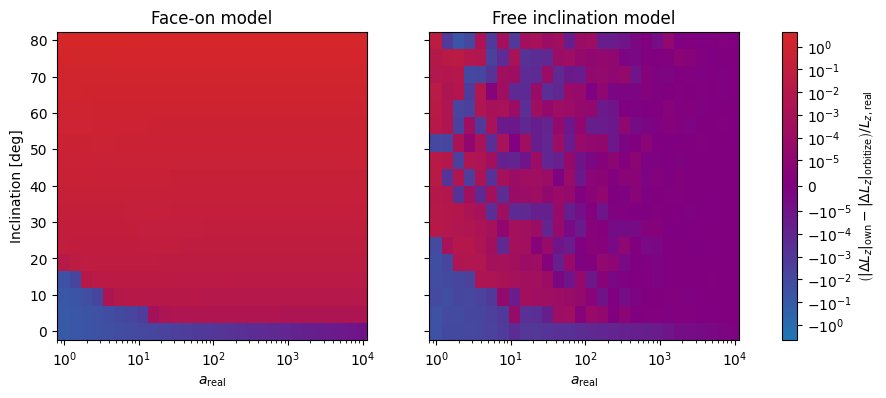

,inclination_deg,"median relative error, face-on","median relative error, free inclination","median relative error, orbitize"
0,0.000000,0.000057,0.000848,0.001042
1,4.705882,0.003367,0.000137,0.000104
2,9.411765,0.011451,0.000134,0.000117
3,14.117647,0.024573,0.000154,0.000151
4,18.823529,0.043676,0.000156,0.000156
5,23.529412,0.069492,0.000165,0.000162
6,28.235294,0.103122,0.000161,0.000170
7,32.941176,0.146132,0.000178,0.000180
8,37.647059,0.200775,0.000197,0.000193
9,42.352941,0.270266,0.000205,0.000210


In [52]:
from joblib import Parallel, delayed
from matplotlib.colors import LinearSegmentedColormap, SymLogNorm

a_map_values = np.geomspace(1, 10000, 28)
inclination_map_values = np.deg2rad(np.linspace(0, 80, 18))

rng_map = np.random.default_rng(seed + 5)
ra_noise_map = rng_map.normal(0, astrometric_error_mas, number_of_fit_points)
dec_noise_map = rng_map.normal(0, astrometric_error_mas, number_of_fit_points)


def estimate_Lz_map_point(row, column):
    """Las tres estimaciones de Lz en un punto (a, i) de la grilla.

    La semilla depende de (row, column), no del orden de ejecucion, de modo que el
    resultado es el mismo en serie o en paralelo.
    """
    inclination = inclination_map_values[row]
    a_real = a_map_values[column]

    period_days = 365.25 * np.sqrt(a_real ** 3 / mass_solar)
    epochs_map = np.linspace(0, period_days, number_of_fit_points, endpoint=False)
    ra_true, dec_true, _ = kepler.calc_orbit(
        epochs_map,
        sma=a_real,
        ecc=0,
        inc=inclination,
        aop=0,
        pan=0.7,
        tau=0.13,
        plx=parallax_mas,
        mtot=mass_solar,
        tau_ref_epoch=0,
        use_c=False,
    )
    ra_observed = ra_true + ra_noise_map
    dec_observed = dec_true + dec_noise_map
    epochs_geometric = 2 * np.pi * epochs_map / days_per_orbit_1AU

    projected_radii = np.hypot(ra_observed, dec_observed) / parallax_mas
    zs_observed = student_t.rvs(
        df=gamma_cusp - 1,
        scale=projected_radii / np.sqrt(gamma_cusp - 1),
        random_state=np.random.default_rng([seed + 5, row, column]),
    )

    Lz_faceon = get_posterior_Lz_joint(
        ra_observed / parallax_mas,
        dec_observed / parallax_mas,
        epochs_geometric,
        astrometric_error_mas / parallax_mas,
        astrometric_error_mas / parallax_mas,
        zs=zs_observed,
        gamma=gamma_cusp,
    )[1]
    Lz_orbitize = estimate_Lz_orbitize_inclined(
        epochs_map,
        ra_observed,
        dec_observed,
        astrometric_error_mas,
        parallax=parallax_mas,
        mass=mass_solar,
    )
    Lz_inclined = get_posterior_Lz_inclined(
        ra_observed / parallax_mas,
        dec_observed / parallax_mas,
        epochs_geometric,
        astrometric_error_mas / parallax_mas,
        astrometric_error_mas / parallax_mas,
        zs=zs_observed,
        gamma=gamma_cusp,
        number_of_steps=4000,
        burn_in=1200,
    )[1]

    # Lz = L cos(i) = sqrt(a) cos(i) para una orbita circular con G = M = m = 1.
    return np.sqrt(a_real) * np.cos(inclination), Lz_faceon, Lz_orbitize, Lz_inclined


map_shape = (len(inclination_map_values), len(a_map_values))
map_results = Parallel(n_jobs=-1)(
    delayed(estimate_Lz_map_point)(row, column)
    for row in range(map_shape[0])
    for column in range(map_shape[1])
)
Lz_real_map, Lz_faceon_map, Lz_orbitize_map, Lz_inclined_map = (
    np.asarray(map_results).reshape(*map_shape, 4).transpose(2, 0, 1)
)

# Diferencia de errores relativos: positiva (rojo) si el metodo propio es peor que
# orbitize, negativa (azul) si es mejor, morada si empatan.
error_faceon_map = np.abs(Lz_faceon_map - Lz_real_map) / Lz_real_map
error_orbitize_map = np.abs(Lz_orbitize_map - Lz_real_map) / Lz_real_map
error_inclined_map = np.abs(Lz_inclined_map - Lz_real_map) / Lz_real_map
difference_faceon_map = error_faceon_map - error_orbitize_map
difference_inclined_map = error_inclined_map - error_orbitize_map

blue_purple_red = LinearSegmentedColormap.from_list(
    'blue_purple_red', ['tab:blue', 'purple', 'tab:red']
)
largest_difference = max(
    np.abs(difference_faceon_map).max(), np.abs(difference_inclined_map).max()
)
color_norm = SymLogNorm(
    linthresh=1e-5, vmin=-largest_difference, vmax=largest_difference
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, difference_map, title in zip(
    axes,
    [difference_faceon_map, difference_inclined_map],
    ['Face-on model', 'Free inclination model'],
):
    mesh = ax.pcolormesh(
        a_map_values,
        np.rad2deg(inclination_map_values),
        difference_map,
        cmap=blue_purple_red,
        norm=color_norm,
        shading='nearest',
    )
    ax.set_xscale('log')
    ax.set_xlabel(r'$a_{\mathrm{real}}$')
    ax.set_title(title)
axes[0].set_ylabel('Inclination [deg]')
fig.colorbar(
    mesh,
    ax=axes,
    label=r'$\left(|\Delta L_z|_{\mathrm{own}}-|\Delta L_z|_{\mathrm{orbitize}}\right)/L_{z,\mathrm{real}}$',
)
plt.show()

comparison_map = pd.DataFrame(
    {
        'inclination_deg': np.rad2deg(inclination_map_values),
        'median relative error, face-on': np.median(error_faceon_map, axis=1),
        'median relative error, free inclination': np.median(error_inclined_map, axis=1),
        'median relative error, orbitize': np.median(error_orbitize_map, axis=1),
    }
)
comparison_map

In [53]:
# Guardado del barrido para no repetir los 4 minutos de computo

from pathlib import Path


def find_project_root(start=None):
    """Raiz del repositorio: el primer directorio con pyproject.toml hacia arriba."""
    path = Path(start or Path.cwd()).resolve()
    for candidate in [path, *path.parents]:
        if (candidate / 'pyproject.toml').exists():
            return candidate
    return path


inclination_map_path = (
    find_project_root()
    / 'data'
    / '011-determinacion_de_parametros_mediante_fisica'
    / 'inclination_map.npz'
)
inclination_map_path.parent.mkdir(parents=True, exist_ok=True)

np.savez_compressed(
    inclination_map_path,
    a_map_values=a_map_values,
    inclination_map_values=inclination_map_values,
    Lz_real_map=Lz_real_map,
    Lz_faceon_map=Lz_faceon_map,
    Lz_orbitize_map=Lz_orbitize_map,
    Lz_inclined_map=Lz_inclined_map,
    ra_noise_map=ra_noise_map,
    dec_noise_map=dec_noise_map,
    number_of_fit_points=number_of_fit_points,
    astrometric_error_mas=astrometric_error_mas,
    parallax_mas=parallax_mas,
    mass_solar=mass_solar,
    gamma_cusp=gamma_cusp,
    seed=seed,
)


def load_inclination_map(path=inclination_map_path):
    """Recupera el barrido guardado sin volver a correrlo.

    Uso: stored = load_inclination_map(); Lz_real_map = stored['Lz_real_map'], etc.
    Con eso basta para rehacer los mapas de la celda anterior.
    """
    with np.load(path) as stored:
        return {name: stored[name] for name in stored.files}


pd.DataFrame(
    {
        'array': [
            'a_map_values',
            'inclination_map_values',
            'Lz_real_map',
            'Lz_faceon_map',
            'Lz_orbitize_map',
            'Lz_inclined_map',
        ],
        'shape': [
            str(np.shape(array))
            for array in [
                a_map_values,
                inclination_map_values,
                Lz_real_map,
                Lz_faceon_map,
                Lz_orbitize_map,
                Lz_inclined_map,
            ]
        ],
        'file': str(inclination_map_path.relative_to(find_project_root())),
        'file_kB': round(inclination_map_path.stat().st_size / 1024, 1),
    }
)

,array,shape,file,file_kB
0,a_map_values,"(28,)",data/011-determinacion_de_parametros_mediante_...,18.6
1,inclination_map_values,"(18,)",data/011-determinacion_de_parametros_mediante_...,18.6
2,Lz_real_map,"(18, 28)",data/011-determinacion_de_parametros_mediante_...,18.6
3,Lz_faceon_map,"(18, 28)",data/011-determinacion_de_parametros_mediante_...,18.6
4,Lz_orbitize_map,"(18, 28)",data/011-determinacion_de_parametros_mediante_...,18.6
5,Lz_inclined_map,"(18, 28)",data/011-determinacion_de_parametros_mediante_...,18.6


# Orbitas elípticas

## 2D

$$
r_i
=
\sqrt{x_i^2+y_i^2},
\qquad
\theta_i
=
\operatorname{atan2}(y_i,x_i).
$$

La ecuación polar de una órbita elíptica kepleriana es

$$
r_i
=
\frac{p}
{
1+e\cos(\theta_i-\omega)
}.
$$

Tomando el inverso,

$$
\frac{1}{r_i}
=
\frac{1}{p}
+
\frac{e}{p}
\cos(\theta_i-\omega).
$$

Usando

$$
\cos(\theta_i-\omega)
=
\cos\theta_i\cos\omega
+
\sin\theta_i\sin\omega,
$$

obtenemos

$$
\frac{1}{r_i}
=
A
+
B\cos\theta_i
+
C\sin\theta_i,
$$

donde

$$
A
=
\frac{1}{p},
$$

$$
B
=
\frac{e}{p}\cos\omega,
$$

$$
C
=
\frac{e}{p}\sin\omega.
$$

Para tres puntos,

$$
\begin{pmatrix}
1 & \cos\theta_1 & \sin\theta_1\\
1 & \cos\theta_2 & \sin\theta_2\\
1 & \cos\theta_3 & \sin\theta_3
\end{pmatrix}
\begin{pmatrix}
A\\
B\\
C
\end{pmatrix}
=
\begin{pmatrix}
1/r_1\\
1/r_2\\
1/r_3
\end{pmatrix}.
$$

Una vez obtenidos \(A\), \(B\) y \(C\),

$$
\boxed{
p
=
\frac{1}{A}
}
$$

y

$$
\boxed{
e
=
\frac{\sqrt{B^2+C^2}}{A}
}.
$$

La orientación del periastro viene dada por

$$
\boxed{
\omega
=
\operatorname{atan2}(C,B)
}.
$$

Como

$$
p
=
a(1-e^2),
$$

y

$$
L_z
=
\sqrt{GMa(1-e^2)},
$$

entonces

$$
\boxed{
L_z
=
\sqrt{GMp}
}.
$$

Usando \(p=1/A\),

$$
\boxed{
L_z
=
\sqrt{\frac{GM}{A}}
}.
$$

En unidades geométricas con \(GM=1\),

$$
\boxed{
L_z
=
\frac{1}{\sqrt{A}} = \sqrt{p}
}.
$$

$$
\mathbf{X}
=
(x_1,y_1,\ldots,x_N,y_N).
$$

Para cada punto,

$$
r_i
=
\sqrt{x_i^2+y_i^2},
\qquad
\theta_i
=
\operatorname{atan2}(y_i,x_i).
$$

A partir de los puntos se ajusta

$$
\frac{1}{r_i}
=
A
+
B\cos\theta_i
+
C\sin\theta_i,
$$

de modo que

$$
A=A(\mathbf{X}).
$$

Si cada punto tiene una distribución observacional

$$
P_i(x_i,y_i),
$$

la distribución inducida de \(A\) es

$$
P_A(A)
=
\int
\left[
\prod_{i=1}^{N}
P_i(x_i,y_i)
\right]
\delta
\left(
A-A(\mathbf{X})
\right)
\prod_{i=1}^{N}
dx_i\,dy_i.
$$

Como

$$
p=\frac{1}{A},
$$

entonces

$$
A=\frac{1}{p},
$$

y el jacobiano del cambio de variable es

$$
\left|
\frac{dA}{dp}
\right|
=
\frac{1}{p^2}.
$$

Por lo tanto,

$$
\boxed{
P_p(p)
=
\frac{1}{p^2}
P_A
\left(
\frac{1}{p}
\right)
}
$$

para

$$
p>0.
$$

Equivalentemente, la distribución de \(p\) puede escribirse directamente a partir de los puntos como

$$
\boxed{
P_p(p)
=
\int
\left[
\prod_{i=1}^{N}
P_i(x_i,y_i)
\right]
\delta
\left(
p-\frac{1}{A(\mathbf{X})}
\right)
\prod_{i=1}^{N}
dx_i\,dy_i
}.
$$

Como

$$
L_z
=
\sqrt{GMp},
$$

tenemos

$$
p
=
\frac{L_z^2}{GM}.
$$

Entonces,

$$
\left|
\frac{dp}{dL_z}
\right|
=
\frac{2L_z}{GM}.
$$

Por lo tanto,

$$
\boxed{
P_{L_z}(L_z)
=
P_p
\left(
\frac{L_z^2}{GM}
\right)
\frac{2L_z}{GM}
}
$$

para

$$
L_z>0.
$$

En unidades geométricas con

$$
GM=1,
$$

se obtiene

$$
\boxed{
P_{L_z}(L_z)
=
2L_z\,P_p(L_z^2)
}.
$$

In [54]:
# Ajuste conico: 1/r = A + B cos(theta) + C sin(theta)


def conic_coefficients(xs, ys):
    """(A, B, C) del ajuste de 1/r = A + B cos(theta) + C sin(theta).

    Acepta arreglos de forma (..., N): la ultima dimension recorre las
    observaciones y las anteriores se resuelven en paralelo. Los residuos se
    pesan con r^2 porque var(1/r) = var(r) / r^4, de modo que el sistema normal
    queda con la matriz de diseno r^2 [1, cos(theta), sin(theta)] y el vector
    objetivo r.
    """
    xs = np.asarray(xs, dtype=float)
    ys = np.asarray(ys, dtype=float)
    # Las coordenadas se reescalan a orden 1 antes de resolver: con r ~ 1e4 el
    # sistema normal lleva r^4 ~ 1e16 y pierde condicionamiento.
    scale = float(np.median(np.hypot(xs, ys)))
    xs, ys = xs / scale, ys / scale
    radii = np.hypot(xs, ys)
    design = np.stack([radii ** 2, xs * radii, ys * radii], axis=-1)
    normal_matrix = np.einsum('...ij,...ik->...jk', design, design)
    normal_vector = np.einsum('...ij,...i->...j', design, radii)
    coefficients = np.linalg.solve(normal_matrix, normal_vector[..., None])[..., 0]
    # 1 / (r / s) = s (A + B cos + C sin): los coeficientes del ajuste reescalado
    # valen s veces los originales.
    return coefficients / scale


def conic_elements(xs, ys):
    """(p, e, omega) a partir de los coeficientes del ajuste conico."""
    A, B, C = np.moveaxis(conic_coefficients(xs, ys), -1, 0)
    return 1 / A, np.hypot(B, C) / A, np.arctan2(C, B)


def estimate_Lz_conic(xs, ys):
    """Lz = sqrt(GM p) = 1 / sqrt(A), con G = M = 1."""
    A = conic_coefficients(xs, ys)[..., 0]
    return np.sqrt(1 / np.where(A > 0, A, np.nan))

In [55]:
# Verificacion algebraica: orbita eliptica sin ruido, vista de frente

a_check = 100.0
ecc_check = 0.3
aop_check = 0.7

period_check = 365.25 * np.sqrt(a_check ** 3 / mass_solar)
epochs_check = np.linspace(0, period_check, number_of_fit_points, endpoint=False)
ra_check, dec_check, _ = kepler.calc_orbit(
    epochs_check,
    sma=a_check,
    ecc=ecc_check,
    inc=0,
    aop=aop_check,
    pan=0,
    tau=0.13,
    plx=parallax_mas,
    mtot=mass_solar,
    tau_ref_epoch=0,
    use_c=False,
)
xs_check = ra_check / parallax_mas
ys_check = dec_check / parallax_mas

p_check, e_check, omega_check = conic_elements(xs_check, ys_check)

# orbitize mide el argumento del periastro desde el norte hacia el este, mientras
# que atan2(dec, ra) lo mide desde el eje de RA: omega_conica = pi / 2 - aop.
pd.DataFrame(
    {
        'quantity': ['p', 'e', 'omega', 'Lz'],
        'fit': [
            p_check,
            e_check,
            omega_check % (2 * np.pi),
            float(estimate_Lz_conic(xs_check, ys_check)),
        ],
        'real': [
            a_check * (1 - ecc_check ** 2),
            ecc_check,
            (np.pi / 2 - aop_check) % (2 * np.pi),
            np.sqrt(a_check * (1 - ecc_check ** 2)),
        ],
    }
)

,quantity,fit,real
0,p,91.000000,91.000000
1,e,0.300000,0.300000
2,omega,0.870796,0.870796
3,Lz,9.539392,9.539392


In [56]:
# P_Lz(Lz) por propagacion de las distribuciones observacionales

from scipy.stats import gaussian_kde


def get_posterior_Lz_conic(
    xs, ys, sigma_x, sigma_y, number_of_samples=20000, rng=None
):
    """Posterior p(Lz | D) para una orbita eliptica vista de frente.

    Implementa la integral con la delta de Dirac de la seccion anterior por
    muestreo: cada realizacion (x_i, y_i) ~ P_i se propaga por el ajuste conico
    A(X), y las muestras de Lz = 1 / sqrt(A) reproducen P_Lz sin necesidad de
    escribir el jacobiano, que ya esta contenido en el cambio de variable.
    """
    xs = np.asarray(xs, dtype=float)
    ys = np.asarray(ys, dtype=float)

    if not (xs.ndim == ys.ndim == 1 and len(xs) == len(ys)):
        raise ValueError("xs y ys deben ser arreglos unidimensionales de igual longitud.")
    if len(xs) < 3:
        raise ValueError("El ajuste conico necesita al menos tres observaciones.")
    if sigma_x <= 0 or sigma_y <= 0:
        raise ValueError("Las desviaciones estandar deben ser positivas.")

    rng = np.random.default_rng() if rng is None else rng
    samples_x = rng.normal(xs, sigma_x, size=(number_of_samples, len(xs)))
    samples_y = rng.normal(ys, sigma_y, size=(number_of_samples, len(ys)))

    Lz_samples = estimate_Lz_conic(samples_x, samples_y)
    Lz_samples = Lz_samples[np.isfinite(Lz_samples)]
    if len(Lz_samples) < number_of_samples // 2:
        raise RuntimeError("Demasiadas realizaciones con A <= 0: el ajuste no es estable.")

    median_Lz = float(np.median(Lz_samples))
    density = gaussian_kde(Lz_samples)

    def p_Lz(Lz):
        Lz = np.asarray(Lz, dtype=float)
        values = density(np.atleast_1d(Lz))
        return float(values[0]) if Lz.ndim == 0 else values

    return p_Lz, median_Lz, Lz_samples

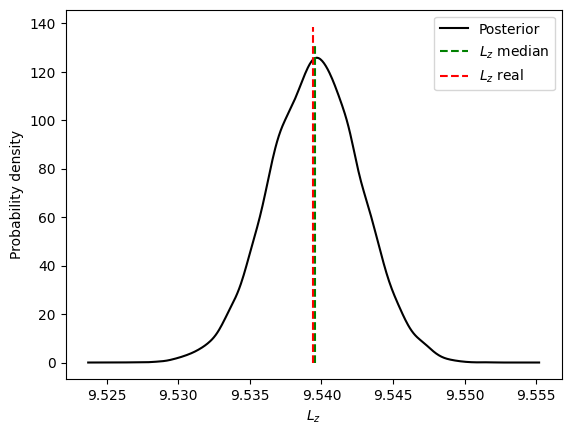

,quantile,Lz
0,0.16,9.536407
1,0.50,9.539579
2,0.84,9.542702


In [57]:
xs_ellipse = xs_check + ra_noise_fit / parallax_mas
ys_ellipse = ys_check + dec_noise_fit / parallax_mas

p_Lz_conic, median_Lz_conic, Lz_samples_conic = get_posterior_Lz_conic(
    xs_ellipse,
    ys_ellipse,
    astrometric_error_mas / parallax_mas,
    astrometric_error_mas / parallax_mas,
    rng=np.random.default_rng(seed + 6),
)

Lz_real_check = np.sqrt(a_check * (1 - ecc_check ** 2))
Lz_low, Lz_high = np.quantile(Lz_samples_conic, [0.16, 0.84])
Lz_values_conic = np.linspace(
    Lz_low - 4 * (median_Lz_conic - Lz_low),
    Lz_high + 4 * (Lz_high - median_Lz_conic),
    500,
)

plt.plot(Lz_values_conic, p_Lz_conic(Lz_values_conic), 'k', label='Posterior')
plt.xlabel(r"$L_z$")
plt.ylabel("Probability density")

plt.vlines(median_Lz_conic, ymin=0, ymax=plt.gca().get_ylim()[1], color='g', linestyle='--', label=r"$L_z$ median")
plt.vlines(Lz_real_check, ymin=0, ymax=plt.gca().get_ylim()[1], color='r', linestyle='--', label=r"$L_z$ real")

plt.legend()
plt.show()

pd.DataFrame(
    {
        'quantile': [0.16, 0.50, 0.84],
        'Lz': [Lz_low, median_Lz_conic, Lz_high],
    }
)

### Comparación con orbitize 3.4.0

El mismo experimento controlado de las secciones anteriores, con órbitas elípticas
vistas de frente: se barre $a_{\mathrm{real}}$ con excentricidad fija y se compara
$|L_z-L_{z,\mathrm{real}}|$ del ajuste cónico, de la mediana de $P_{L_z}$ y del ajuste
kepleriano de orbitize 3.4.0. El valor de referencia ahora es
$L_{z,\mathrm{real}}=\sqrt{GMa(1-e^2)}$.

In [58]:
def estimate_Lz_orbitize_eccentric(epochs, raoff, deoff, errors, parallax=1, mass=1):
    """Ajusta a, e, omega y fase con el propagador Kepler de orbitize 3.4.0."""
    epochs = np.asarray(epochs, dtype=float)
    raoff = np.asarray(raoff, dtype=float)
    deoff = np.asarray(deoff, dtype=float)
    errors = np.broadcast_to(np.asarray(errors, dtype=float), raoff.shape)

    separation = np.hypot(raoff, deoff) / parallax
    a_initial = 0.5 * (separation.min() + separation.max())
    lower_log_a = np.log(max(a_initial / 100, 1e-8))
    upper_log_a = np.log(a_initial * 100)

    def residuals(parameters):
        log_a, ecc, aop, tau = parameters
        model_ra, model_dec, _ = kepler.calc_orbit(
            epochs,
            sma=np.exp(log_a),
            ecc=ecc,
            inc=0,
            aop=aop,
            pan=0,
            tau=tau,
            plx=parallax,
            mtot=mass,
            tau_ref_epoch=0,
            use_c=False,
        )
        return np.concatenate([
            (model_ra - raoff) / errors,
            (model_dec - deoff) / errors,
        ])

    # Con inc = 0 la superficie de chi^2 tiene minimos locales en la fase y en la
    # orientacion del periastro: se arranca desde una rejilla de (tau, aop).
    fits = [
        least_squares(
            residuals,
            x0=[np.log(a_initial), 0.2, aop_initial, tau_initial],
            bounds=([lower_log_a, 0, 0, 0], [upper_log_a, 0.95, 2 * np.pi, 1]),
        )
        for tau_initial in [0.05, 0.30, 0.55, 0.80]
        for aop_initial in [0.5, 2.5, 4.5]
    ]
    best_fit = min(fits, key=lambda fit: np.sum(fit.fun ** 2))
    a_fit = np.exp(best_fit.x[0])
    ecc_fit = best_fit.x[1]

    # Lz = sqrt(GM a (1 - e^2)) = sqrt(GM p), con G = M = 1.
    return float(np.sqrt(a_fit * (1 - ecc_fit ** 2)))

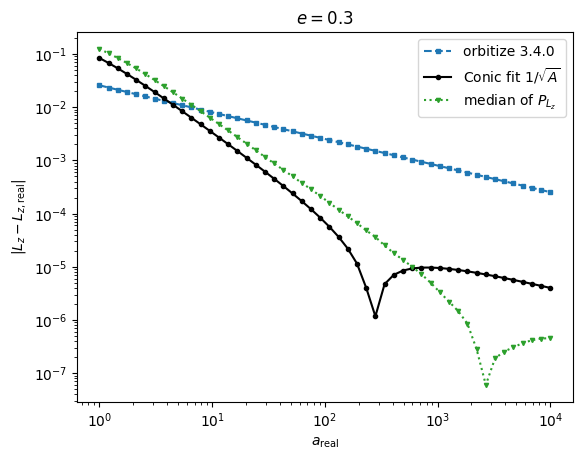

,a_real,Conic fit,Conic posterior,orbitize
0,1.000000,0.084230,1.245734e-01,0.025836
1,1.206793,0.067823,1.032392e-01,0.023435
2,1.456348,0.053828,8.410429e-02,0.021271
3,1.757511,0.042195,6.761951e-02,0.019318
4,2.120951,0.032743,5.359399e-02,0.017551
5,2.559548,0.025204,4.190948e-02,0.015951
6,3.088844,0.019280,3.238621e-02,0.014501
7,3.727594,0.014678,2.497431e-02,0.013186
8,4.498433,0.011133,1.912323e-02,0.011993
9,5.428675,0.008420,1.457098e-02,0.010909


In [59]:
# Barrido en a con excentricidad fija

ecc_sweep = 0.3
aop_sweep = 0.7

Lz_conic_point_values = []
Lz_conic_median_values = []
Lz_orbitize_eccentric_values = []

for a_real in a_fit_values:
    period_days = 365.25 * np.sqrt(a_real ** 3 / mass_solar)
    epochs_fit = np.linspace(0, period_days, number_of_fit_points, endpoint=False)
    ra_true, dec_true, _ = kepler.calc_orbit(
        epochs_fit,
        sma=a_real,
        ecc=ecc_sweep,
        inc=0,
        aop=aop_sweep,
        pan=0,
        tau=0.13,
        plx=parallax_mas,
        mtot=mass_solar,
        tau_ref_epoch=0,
        use_c=False,
    )
    ra_observed = ra_true + ra_noise_fit
    dec_observed = dec_true + dec_noise_fit

    Lz_conic_point_values.append(
        float(estimate_Lz_conic(ra_observed / parallax_mas, dec_observed / parallax_mas))
    )
    _, median_Lz_sweep, _ = get_posterior_Lz_conic(
        ra_observed / parallax_mas,
        dec_observed / parallax_mas,
        astrometric_error_mas / parallax_mas,
        astrometric_error_mas / parallax_mas,
        rng=np.random.default_rng(seed + 6),
    )
    Lz_conic_median_values.append(median_Lz_sweep)
    Lz_orbitize_eccentric_values.append(
        estimate_Lz_orbitize_eccentric(
            epochs_fit,
            ra_observed,
            dec_observed,
            astrometric_error_mas,
            parallax=parallax_mas,
            mass=mass_solar,
        )
    )

Lz_conic_point_values = np.asarray(Lz_conic_point_values)
Lz_conic_median_values = np.asarray(Lz_conic_median_values)
Lz_orbitize_eccentric_values = np.asarray(Lz_orbitize_eccentric_values)
Lz_real_ellipse = np.sqrt(a_fit_values * (1 - ecc_sweep ** 2))

difference_conic_point = np.abs(Lz_conic_point_values - Lz_real_ellipse)
difference_conic_median = np.abs(Lz_conic_median_values - Lz_real_ellipse)
difference_orbitize_eccentric = np.abs(Lz_orbitize_eccentric_values - Lz_real_ellipse)

comparison_ellipse = pd.DataFrame(
    {
        'a_real': a_fit_values,
        'Conic fit': difference_conic_point,
        'Conic posterior': difference_conic_median,
        'orbitize': difference_orbitize_eccentric,
    }
)

fig, ax = plt.subplots()
ax.plot(a_fit_values, difference_orbitize_eccentric, 's--', markersize=3, color='tab:blue', label='orbitize 3.4.0')
ax.plot(a_fit_values, difference_conic_point, 'o-', markersize=3, color='k', label=r'Conic fit $1/\sqrt{A}$')
ax.plot(a_fit_values, difference_conic_median, 'v:', markersize=3, color='tab:green', label=r'median of $P_{L_z}$')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$a_{\mathrm{real}}$')
ax.set_ylabel(r'$|L_z - L_{z,\mathrm{real}}|$')
ax.set_title(f'$e = {ecc_sweep}$')
ax.legend()
plt.show()

comparison_ellipse

### Barrido en excentricidad

Con $a$ fijo se recorre $e$ de $0$ a $0.9$: el ajuste cónico no supone órbita circular,
así que el error no debería crecer con la excentricidad.

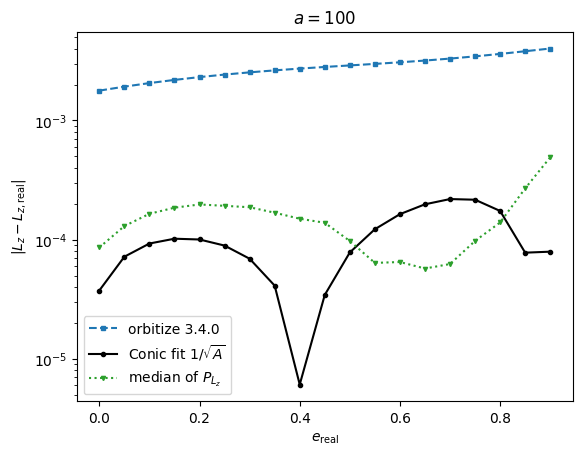

,e_real,Conic fit,Conic posterior,orbitize
0,0.00,0.000037,0.000086,0.001780
1,0.05,0.000072,0.000130,0.001922
2,0.10,0.000093,0.000165,0.002059
3,0.15,0.000102,0.000186,0.002189
4,0.20,0.000100,0.000198,0.002312
5,0.25,0.000089,0.000192,0.002426
6,0.30,0.000069,0.000187,0.002533
7,0.35,0.000041,0.000168,0.002632
8,0.40,0.000006,0.000150,0.002724
9,0.45,0.000034,0.000139,0.002811


In [60]:
# Barrido en excentricidad con a fijo

a_eccentricity_sweep = 100.0
eccentricity_values = np.linspace(0, 0.9, 19)

Lz_conic_point_eccentricity = []
Lz_conic_median_eccentricity = []
Lz_orbitize_eccentricity = []

period_eccentricity = 365.25 * np.sqrt(a_eccentricity_sweep ** 3 / mass_solar)
epochs_eccentricity = np.linspace(
    0, period_eccentricity, number_of_fit_points, endpoint=False
)

for ecc_real in eccentricity_values:
    ra_true, dec_true, _ = kepler.calc_orbit(
        epochs_eccentricity,
        sma=a_eccentricity_sweep,
        ecc=ecc_real,
        inc=0,
        aop=aop_sweep,
        pan=0,
        tau=0.13,
        plx=parallax_mas,
        mtot=mass_solar,
        tau_ref_epoch=0,
        use_c=False,
    )
    ra_observed = ra_true + ra_noise_fit
    dec_observed = dec_true + dec_noise_fit

    Lz_conic_point_eccentricity.append(
        float(estimate_Lz_conic(ra_observed / parallax_mas, dec_observed / parallax_mas))
    )
    _, median_Lz_eccentricity, _ = get_posterior_Lz_conic(
        ra_observed / parallax_mas,
        dec_observed / parallax_mas,
        astrometric_error_mas / parallax_mas,
        astrometric_error_mas / parallax_mas,
        rng=np.random.default_rng(seed + 6),
    )
    Lz_conic_median_eccentricity.append(median_Lz_eccentricity)
    Lz_orbitize_eccentricity.append(
        estimate_Lz_orbitize_eccentric(
            epochs_eccentricity,
            ra_observed,
            dec_observed,
            astrometric_error_mas,
            parallax=parallax_mas,
            mass=mass_solar,
        )
    )

Lz_conic_point_eccentricity = np.asarray(Lz_conic_point_eccentricity)
Lz_conic_median_eccentricity = np.asarray(Lz_conic_median_eccentricity)
Lz_orbitize_eccentricity = np.asarray(Lz_orbitize_eccentricity)
Lz_real_eccentricity = np.sqrt(
    a_eccentricity_sweep * (1 - eccentricity_values ** 2)
)

difference_conic_point_eccentricity = np.abs(
    Lz_conic_point_eccentricity - Lz_real_eccentricity
)
difference_conic_median_eccentricity = np.abs(
    Lz_conic_median_eccentricity - Lz_real_eccentricity
)
difference_orbitize_eccentricity = np.abs(
    Lz_orbitize_eccentricity - Lz_real_eccentricity
)

comparison_eccentricity = pd.DataFrame(
    {
        'e_real': eccentricity_values,
        'Conic fit': difference_conic_point_eccentricity,
        'Conic posterior': difference_conic_median_eccentricity,
        'orbitize': difference_orbitize_eccentricity,
    }
)

fig, ax = plt.subplots()
ax.plot(eccentricity_values, difference_orbitize_eccentricity, 's--', markersize=3, color='tab:blue', label='orbitize 3.4.0')
ax.plot(eccentricity_values, difference_conic_point_eccentricity, 'o-', markersize=3, color='k', label=r'Conic fit $1/\sqrt{A}$')
ax.plot(eccentricity_values, difference_conic_median_eccentricity, 'v:', markersize=3, color='tab:green', label=r'median of $P_{L_z}$')
ax.set_yscale('log')
ax.set_xlabel(r'$e_{\mathrm{real}}$')
ax.set_ylabel(r'$|L_z - L_{z,\mathrm{real}}|$')
ax.set_title(f'$a = {a_eccentricity_sweep:.0f}$')
ax.legend()
plt.show()

comparison_eccentricity

## 3D

$$
\mathbf{X}
=
(x_1,y_1,z_1,\ldots,x_N,y_N,z_N).
$$

Para cada realización de los puntos se obtienen simultáneamente

$$
p
=
p(\mathbf{X}),
$$

y

$$
n_z
=
n_z(\mathbf{X}).
$$

Por lo tanto, la distribución relevante es la distribución conjunta

$$
\boxed{
P(p,n_z)
}.
$$

Si cada punto tiene una distribución observacional

$$
P_i(x_i,y_i,z_i),
$$

entonces

$$
P(p,n_z)
=
\int
\left[
\prod_{i=1}^{N}
P_i(x_i,y_i,z_i)
\right]
\delta
\left(
p-p(\mathbf{X})
\right)
\delta
\left(
n_z-n_z(\mathbf{X})
\right)
\prod_{i=1}^{N}
dx_i\,dy_i\,dz_i.
$$

Las distribuciones marginales se obtienen como

$$
P(p)
=
\int
P(p,n_z)\,dn_z,
$$

y

$$
P(n_z)
=
\int
P(p,n_z)\,dp.
$$

Como

$$
L_z
=
\sqrt{GMp}\,n_z,
$$

la distribución de \(L_z\) viene dada por

$$
\boxed{
P(L_z)
=
\int
P(p,n_z)
\,
\delta
\left(
L_z-\sqrt{GMp}\,n_z
\right)
\,dp\,dn_z
}.
$$

En unidades geométricas con

$$
GM=1,
$$

se obtiene

$$
\boxed{
P(L_z)
=
\int
P(p,n_z)
\,
\delta
\left(
L_z-\sqrt{p}\,n_z
\right)
\,dp\,dn_z
}.
$$

Solo si \(p\) y \(n_z\) fueran independientes podría escribirse

$$
P(p,n_z)
=
P(p)P(n_z),
$$

y entonces

$$
P(L_z)
=
\int
P(p)P(n_z)
\,
\delta
\left(
L_z-\sqrt{GMp}\,n_z
\right)
\,dp\,dn_z.
$$

### Implementación

El plano orbital pasa por el foco, que está en el origen, así que su normal
$\hat{n}$ es el autovector menor de $\sum_i \mathbf r_i\mathbf r_i^{\mathsf T}$, y su
signo se fija con $\sum_i \mathbf r_i\times\mathbf r_{i+1}$, que apunta como el momento
angular. Proyectando los puntos sobre una base ortonormal del plano se recupera el
problema 2D de la sección anterior, de modo que

$$
p=p(\mathbf X),
\qquad
n_z=n_z(\mathbf X)
$$

salen de un solo pase por cada realización de $\mathbf X$, que es lo que exige la
conjunta $P(p,n_z)$.

Los datos que consume cada método no son los mismos: el método propio necesita las
tres coordenadas $(x_i,y_i,z_i)$, mientras que orbitize 3.4.0 solo admite astrometría
proyectada $(\mathrm{RA},\mathrm{DEC})$ y nunca ve la profundidad. El último barrido
mide precisamente cuánto vale esa información extra en función de $\sigma_z$.

In [61]:
# Orbita eliptica en 3D: el mismo modelo kepleriano de orbitize, sin proyectar


def solve_kepler_equation(mean_anomaly, eccentricity, tolerance=1e-13, iterations=60):
    """Resuelve E - e sin(E) = M por Newton-Raphson."""
    E = mean_anomaly + eccentricity * np.sin(mean_anomaly)
    for _ in range(iterations):
        step = (E - eccentricity * np.sin(E) - mean_anomaly) / (
            1 - eccentricity * np.cos(E)
        )
        E = E - step
        if np.max(np.abs(step)) < tolerance:
            break
    return E


def kepler_orbit_3d(epochs, sma, ecc, inc, aop, pan, tau, mass=1, tau_ref_epoch=0):
    """Posiciones (norte, este, profundidad) en AU para los elementos de orbitize.

    Las dos primeras componentes son deoff / plx y raoff / plx de
    orbitize.kepler.calc_orbit, y la profundidad crece alejandose del observador,
    con el mismo signo que la velocidad radial que devuelve orbitize. La terna
    (norte, este, profundidad) es dextrogira, de modo que la normal del plano
    orbital cumple n_z = cos(i) con la misma i de orbitize. La celda siguiente
    verifica las dos cosas.
    """
    epochs = np.asarray(epochs, dtype=float)
    period = days_per_orbit_1AU * np.sqrt(sma ** 3 / mass)
    mean_anomaly = 2 * np.pi * ((epochs - tau_ref_epoch) / period - tau)
    eccentric_anomaly = solve_kepler_equation(mean_anomaly, ecc)

    plane_x = sma * (np.cos(eccentric_anomaly) - ecc)
    plane_y = sma * np.sqrt(1 - ecc ** 2) * np.sin(eccentric_anomaly)

    cos_aop, sin_aop = np.cos(aop), np.sin(aop)
    cos_inc, sin_inc = np.cos(inc), np.sin(inc)
    cos_pan, sin_pan = np.cos(pan), np.sin(pan)

    # R_z(pan) R_x(inc) R_z(aop) aplicada al vector del plano orbital.
    rotated_x = plane_x * cos_aop - plane_y * sin_aop
    rotated_y = plane_x * sin_aop + plane_y * cos_aop
    north = rotated_x * cos_pan - rotated_y * cos_inc * sin_pan
    east = rotated_x * sin_pan + rotated_y * cos_inc * cos_pan
    depth = rotated_y * sin_inc
    return north, east, depth

In [62]:
# Plano orbital y ajuste conico dentro del plano


def orbital_plane_basis(xs, ys, zs):
    """Normal del plano orbital y una base ortonormal dentro del plano.

    El plano pasa por el foco, que esta en el origen, asi que la normal es el
    autovector menor de sum_i r_i r_i^T. El signo se fija con sum_i r_i x r_{i+1},
    que apunta como el momento angular: los puntos deben venir ordenados en el
    tiempo. Acepta arreglos (..., N): la ultima dimension recorre las
    observaciones.
    """
    positions = np.stack([xs, ys, zs], axis=-1)
    scatter_matrix = np.einsum('...ij,...ik->...jk', positions, positions)
    normals = np.linalg.eigh(scatter_matrix)[1][..., 0]

    areal = np.cross(positions[..., :-1, :], positions[..., 1:, :]).sum(axis=-2)
    signs = np.sign(np.einsum('...i,...i->...', areal, normals))
    normals = normals * np.where(signs == 0, 1.0, signs)[..., None]

    # Base del plano: se arranca del eje cartesiano menos alineado con la normal.
    seeds = np.zeros_like(normals)
    np.put_along_axis(
        seeds, np.argmin(np.abs(normals), axis=-1)[..., None], 1.0, axis=-1
    )
    first = np.cross(normals, seeds)
    first = first / np.linalg.norm(first, axis=-1, keepdims=True)
    second = np.cross(normals, first)
    return normals, first, second


def conic_elements_3d(xs, ys, zs):
    """(p, n_z) a partir de los puntos en 3D.

    p sale del mismo ajuste conico de la seccion 2D, hecho sobre las coordenadas
    de los puntos en la base del plano orbital; n_z es la componente z de la
    normal, es decir cos(i). La eleccion de la base dentro del plano solo rota
    omega, de modo que p no depende de ella.
    """
    positions = np.stack([xs, ys, zs], axis=-1)
    normals, first, second = orbital_plane_basis(xs, ys, zs)
    plane_x = np.einsum('...ij,...j->...i', positions, first)
    plane_y = np.einsum('...ij,...j->...i', positions, second)
    A = conic_coefficients(plane_x, plane_y)[..., 0]
    return 1 / np.where(A > 0, A, np.nan), normals[..., 2]


def estimate_Lz_conic_3d(xs, ys, zs):
    """Lz = sqrt(GM p) n_z, con G = M = 1."""
    p, n_z = conic_elements_3d(xs, ys, zs)
    return np.sqrt(p) * n_z

In [63]:
# Verificacion sin ruido

a_check_3d = 100.0
ecc_check_3d = 0.3
inclination_check_3d = np.deg2rad(40)
aop_check_3d = 0.7
pan_check_3d = 1.1

period_check_3d = 365.25 * np.sqrt(a_check_3d ** 3 / mass_solar)
epochs_check_3d = np.linspace(
    0, period_check_3d, number_of_fit_points, endpoint=False
)
xs_check_3d, ys_check_3d, zs_check_3d = kepler_orbit_3d(
    epochs_check_3d,
    a_check_3d,
    ecc_check_3d,
    inclination_check_3d,
    aop_check_3d,
    pan_check_3d,
    tau=0.13,
    mass=mass_solar,
)

# El modelo 3D reproduce la astrometria proyectada y la velocidad radial de orbitize.
ra_check_3d, dec_check_3d, radial_velocity_check_3d = kepler.calc_orbit(
    epochs_check_3d,
    sma=a_check_3d,
    ecc=ecc_check_3d,
    inc=inclination_check_3d,
    aop=aop_check_3d,
    pan=pan_check_3d,
    tau=0.13,
    plx=parallax_mas,
    mtot=mass_solar,
    tau_ref_epoch=0,
    use_c=False,
)

p_check_3d, nz_check_3d = conic_elements_3d(xs_check_3d, ys_check_3d, zs_check_3d)

pd.DataFrame(
    {
        'quantity': [
            'p',
            'n_z',
            'Lz',
            'max |proyeccion - orbitize|',
            'corr(d(profundidad)/dt, RV)',
        ],
        'fit': [
            p_check_3d,
            nz_check_3d,
            float(estimate_Lz_conic_3d(xs_check_3d, ys_check_3d, zs_check_3d)),
            max(
                np.abs(xs_check_3d - dec_check_3d / parallax_mas).max(),
                np.abs(ys_check_3d - ra_check_3d / parallax_mas).max(),
            ),
            np.corrcoef(
                np.gradient(zs_check_3d, epochs_check_3d), radial_velocity_check_3d
            )[0, 1],
        ],
        'real': [
            a_check_3d * (1 - ecc_check_3d ** 2),
            np.cos(inclination_check_3d),
            np.sqrt(a_check_3d * (1 - ecc_check_3d ** 2)) * np.cos(inclination_check_3d),
            0.0,
            1.0,
        ],
    }
)

,quantity,fit,real
0,p,91.0,91.000000
1,n_z,0.7660444431189781,0.766044
2,Lz,7.307598,7.307598
3,max |proyeccion - orbitize|,0.0,0.000000
4,"corr(d(profundidad)/dt, RV)",0.997995,1.000000


In [64]:
# Distribucion conjunta P(p, n_z) y su proyeccion sobre Lz


def get_joint_samples_3d(
    xs, ys, zs, sigma_x, sigma_y, sigma_z, number_of_samples=20000, rng=None
):
    """Muestras de (p, n_z) de la conjunta P(p, n_z) de la seccion anterior.

    Cada realizacion (x_i, y_i, z_i) ~ P_i se propaga por el ajuste del plano y
    por el ajuste conico dentro del plano, de modo que las dos deltas de Dirac se
    resuelven por muestreo. Las muestras conservan la correlacion entre p y n_z,
    que es justamente lo que se pierde al factorizar P(p, n_z) = P(p) P(n_z).
    """
    xs = np.asarray(xs, dtype=float)
    ys = np.asarray(ys, dtype=float)
    zs = np.asarray(zs, dtype=float)

    if not (xs.ndim == ys.ndim == zs.ndim == 1 and len(xs) == len(ys) == len(zs)):
        raise ValueError("xs, ys y zs deben ser arreglos unidimensionales de igual longitud.")
    if len(xs) < 3:
        raise ValueError("El ajuste conico necesita al menos tres observaciones.")
    if min(sigma_x, sigma_y, sigma_z) <= 0:
        raise ValueError("Las desviaciones estandar deben ser positivas.")

    rng = np.random.default_rng() if rng is None else rng
    samples_x = rng.normal(xs, sigma_x, size=(number_of_samples, len(xs)))
    samples_y = rng.normal(ys, sigma_y, size=(number_of_samples, len(ys)))
    samples_z = rng.normal(zs, sigma_z, size=(number_of_samples, len(zs)))

    p_samples, nz_samples = conic_elements_3d(samples_x, samples_y, samples_z)
    valid = np.isfinite(p_samples) & np.isfinite(nz_samples)
    if valid.sum() < number_of_samples // 2:
        raise RuntimeError("Demasiadas realizaciones invalidas: el ajuste no es estable.")
    return p_samples[valid], nz_samples[valid]


def get_posterior_Lz_conic_3d(*args, **kwargs):
    """Posterior p(Lz | D) = int P(p, n_z) delta(Lz - sqrt(p) n_z) dp dn_z."""
    p_samples, nz_samples = get_joint_samples_3d(*args, **kwargs)
    Lz_samples = np.sqrt(p_samples) * nz_samples
    density = gaussian_kde(Lz_samples)

    def p_Lz(Lz):
        Lz = np.asarray(Lz, dtype=float)
        values = density(np.atleast_1d(Lz))
        return float(values[0]) if Lz.ndim == 0 else values

    return p_Lz, float(np.median(Lz_samples)), Lz_samples

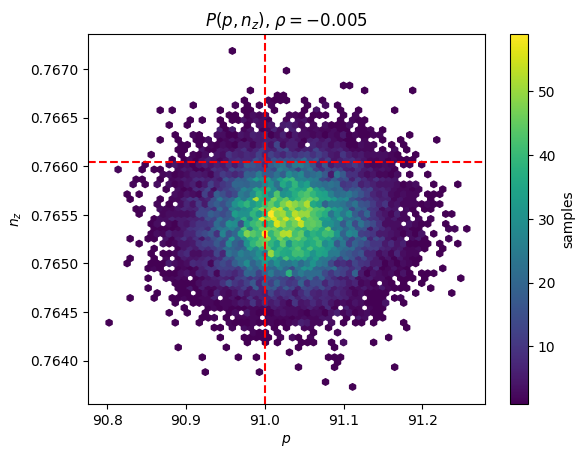

,quantity,median,std,real
0,p,91.030368,0.060407,91.000000
1,n_z,0.765426,0.000398,0.766044


In [65]:
z_noise_fit = np.random.default_rng(seed + 7).normal(
    0, astrometric_error_mas, number_of_fit_points
)

xs_obs_3d = xs_check_3d + dec_noise_fit / parallax_mas
ys_obs_3d = ys_check_3d + ra_noise_fit / parallax_mas
zs_obs_3d = zs_check_3d + z_noise_fit / parallax_mas

p_samples_3d, nz_samples_3d = get_joint_samples_3d(
    xs_obs_3d,
    ys_obs_3d,
    zs_obs_3d,
    astrometric_error_mas / parallax_mas,
    astrometric_error_mas / parallax_mas,
    astrometric_error_mas / parallax_mas,
    rng=np.random.default_rng(seed + 7),
)

correlation_p_nz = float(np.corrcoef(p_samples_3d, nz_samples_3d)[0, 1])

fig, ax = plt.subplots()
histogram = ax.hexbin(p_samples_3d, nz_samples_3d, gridsize=60, cmap='viridis', mincnt=1)
ax.axvline(a_check_3d * (1 - ecc_check_3d ** 2), color='r', linestyle='--')
ax.axhline(np.cos(inclination_check_3d), color='r', linestyle='--')
ax.set_xlabel(r'$p$')
ax.set_ylabel(r'$n_z$')
ax.set_title(rf'$P(p, n_z)$, $\rho = {correlation_p_nz:.3f}$')
fig.colorbar(histogram, ax=ax, label='samples')
plt.show()

pd.DataFrame(
    {
        'quantity': ['p', 'n_z'],
        'median': [np.median(p_samples_3d), np.median(nz_samples_3d)],
        'std': [np.std(p_samples_3d), np.std(nz_samples_3d)],
        'real': [
            a_check_3d * (1 - ecc_check_3d ** 2),
            np.cos(inclination_check_3d),
        ],
    }
)

La correlación entre $p$ y $n_z$ decide si la factorización
$P(p,n_z)=P(p)P(n_z)$ es admisible. Permutar las muestras de $n_z$ deja intactas las
marginales y destruye la correlación, así que comparar $P(L_z)$ antes y después de
permutar mide directamente el error que introduce suponer independencia.

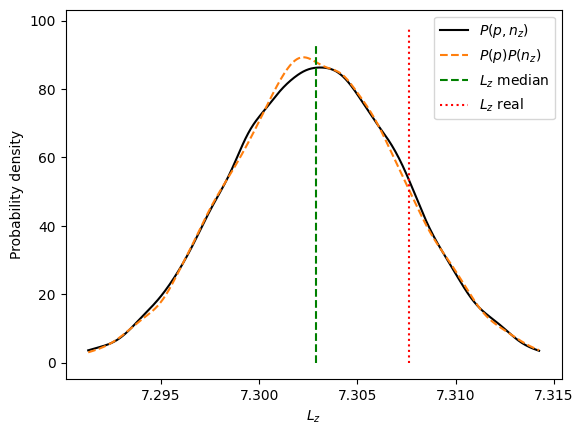

,distribution,median_Lz,std_Lz
0,"P(p, n_z)",7.302909,0.004491
1,P(p) P(n_z),7.302875,0.004468


In [66]:
# P(Lz) de la conjunta frente a P(Lz) suponiendo independencia

Lz_samples_joint_3d = np.sqrt(p_samples_3d) * nz_samples_3d
# Permutar n_z rompe la correlacion sin cambiar las marginales: es exactamente
# muestrear P(p) P(n_z) en lugar de P(p, n_z).
Lz_samples_factorized = np.sqrt(p_samples_3d) * np.random.default_rng(
    seed + 8
).permutation(nz_samples_3d)

median_Lz_3d_joint = float(np.median(Lz_samples_joint_3d))
Lz_real_check_3d = np.sqrt(a_check_3d * (1 - ecc_check_3d ** 2)) * np.cos(
    inclination_check_3d
)

density_joint = gaussian_kde(Lz_samples_joint_3d)
density_factorized = gaussian_kde(Lz_samples_factorized)
Lz_low_3d, Lz_high_3d = np.quantile(Lz_samples_joint_3d, [0.005, 0.995])
Lz_values_3d_conic = np.linspace(Lz_low_3d, Lz_high_3d, 500)

plt.plot(Lz_values_3d_conic, density_joint(Lz_values_3d_conic), 'k', label=r'$P(p, n_z)$')
plt.plot(
    Lz_values_3d_conic,
    density_factorized(Lz_values_3d_conic),
    color='tab:orange',
    linestyle='--',
    label=r'$P(p)P(n_z)$',
)
plt.xlabel(r"$L_z$")
plt.ylabel("Probability density")
plt.vlines(median_Lz_3d_joint, ymin=0, ymax=plt.gca().get_ylim()[1], color='g', linestyle='--', label=r"$L_z$ median")
plt.vlines(Lz_real_check_3d, ymin=0, ymax=plt.gca().get_ylim()[1], color='r', linestyle=':', label=r"$L_z$ real")
plt.legend()
plt.show()

pd.DataFrame(
    {
        'distribution': ['P(p, n_z)', 'P(p) P(n_z)'],
        'median_Lz': [median_Lz_3d_joint, float(np.median(Lz_samples_factorized))],
        'std_Lz': [
            float(np.std(Lz_samples_joint_3d)),
            float(np.std(Lz_samples_factorized)),
        ],
    }
)

### Comparación con orbitize 3.4.0

Mismo experimento controlado que en 2D, ahora con la inclinación libre: se barre
$a_{\mathrm{real}}$ con $e$ e $i$ fijas y la referencia es
$L_{z,\mathrm{real}}=\sqrt{GMa(1-e^2)}\cos i$.

In [67]:
def estimate_Lz_orbitize_3d(epochs, raoff, deoff, errors, parallax=1, mass=1):
    """Ajusta a, e, i, omega, Omega y fase con el propagador de orbitize 3.4.0.

    orbitize solo consume astrometria proyectada: la profundidad no entra.
    """
    epochs = np.asarray(epochs, dtype=float)
    raoff = np.asarray(raoff, dtype=float)
    deoff = np.asarray(deoff, dtype=float)
    errors = np.broadcast_to(np.asarray(errors, dtype=float), raoff.shape)

    separation = np.hypot(raoff, deoff) / parallax
    a_initial = 0.5 * (separation.min() + separation.max())
    lower_log_a = np.log(max(a_initial / 100, 1e-8))
    upper_log_a = np.log(a_initial * 100)

    def residuals(parameters):
        log_a, ecc, inclination, aop, node, tau = parameters
        model_ra, model_dec, _ = kepler.calc_orbit(
            epochs,
            sma=np.exp(log_a),
            ecc=ecc,
            inc=inclination,
            aop=aop,
            pan=node,
            tau=tau,
            plx=parallax,
            mtot=mass,
            tau_ref_epoch=0,
            use_c=False,
        )
        return np.concatenate([
            (model_ra - raoff) / errors,
            (model_dec - deoff) / errors,
        ])

    fits = [
        least_squares(
            residuals,
            x0=[np.log(a_initial), 0.2, inclination_initial, aop_initial, node_initial, tau_initial],
            bounds=(
                [lower_log_a, 0, 0, 0, 0, 0],
                [upper_log_a, 0.95, np.pi / 2, 2 * np.pi, 2 * np.pi, 1],
            ),
        )
        for tau_initial in [0.1, 0.6]
        for inclination_initial in [0.3, 0.9, 1.3]
        for aop_initial in [1.0, 4.0]
        for node_initial in [1.0, 4.0]
    ]
    best_fit = min(fits, key=lambda fit: np.sum(fit.fun ** 2))
    a_fit, ecc_fit, inclination_fit = np.exp(best_fit.x[0]), best_fit.x[1], best_fit.x[2]

    # Lz = sqrt(GM a (1 - e^2)) cos(i) = sqrt(GM p) cos(i), con G = M = 1.
    return float(np.sqrt(a_fit * (1 - ecc_fit ** 2)) * np.cos(inclination_fit))

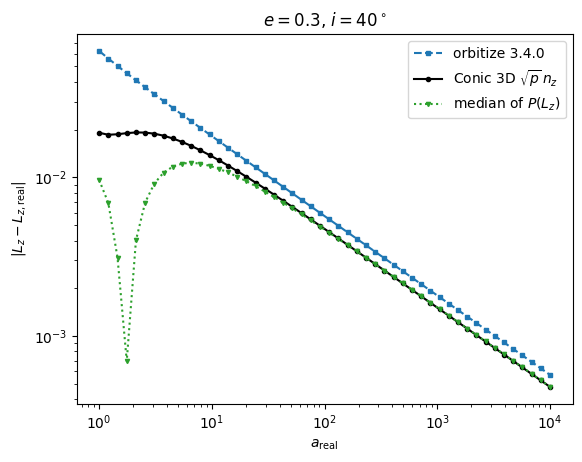

,a_real,Conic 3D fit,Conic 3D posterior,orbitize,"corr(p, n_z)"
0,1.000000,0.019088,0.009646,0.062584,-0.078206
1,1.206793,0.018548,0.006888,0.056042,-0.068306
2,1.456348,0.018685,0.003117,0.050332,-0.057456
3,1.757511,0.018991,0.000695,0.045313,-0.047064
4,2.120951,0.019184,0.004008,0.040874,-0.037909
5,2.559548,0.019142,0.006942,0.036928,-0.030288
6,3.088844,0.018839,0.009146,0.033406,-0.024194
7,3.727594,0.018303,0.010702,0.030252,-0.019464
8,4.498433,0.017582,0.011675,0.027420,-0.015867
9,5.428675,0.016729,0.012196,0.024872,-0.013170


In [68]:
# Barrido en a con e e inclinacion fijas

ecc_sweep_3d = 0.3
inclination_sweep_3d = np.deg2rad(40)
aop_sweep_3d = 0.7
pan_sweep_3d = 1.1


def estimate_Lz_3d_case(a_real, ecc, inclination, sigma_z=None, samples_rng=None):
    """Las tres estimaciones de Lz para una orbita (a, e, i) con el ruido fijo."""
    sigma_z = astrometric_error_mas if sigma_z is None else sigma_z
    period_days = 365.25 * np.sqrt(a_real ** 3 / mass_solar)
    epochs = np.linspace(0, period_days, number_of_fit_points, endpoint=False)
    x_true, y_true, z_true = kepler_orbit_3d(
        epochs, a_real, ecc, inclination, aop_sweep_3d, pan_sweep_3d,
        tau=0.13, mass=mass_solar,
    )
    x_observed = x_true + dec_noise_fit / parallax_mas
    y_observed = y_true + ra_noise_fit / parallax_mas
    z_observed = z_true + (sigma_z / astrometric_error_mas) * z_noise_fit / parallax_mas

    Lz_point = float(estimate_Lz_conic_3d(x_observed, y_observed, z_observed))
    p_samples, nz_samples = get_joint_samples_3d(
        x_observed,
        y_observed,
        z_observed,
        astrometric_error_mas / parallax_mas,
        astrometric_error_mas / parallax_mas,
        sigma_z / parallax_mas,
        rng=np.random.default_rng(seed + 7) if samples_rng is None else samples_rng,
    )
    Lz_median = float(np.median(np.sqrt(p_samples) * nz_samples))
    # orbitize consume (raoff, deoff) = (este, norte): la profundidad no entra.
    Lz_orbitize = estimate_Lz_orbitize_3d(
        epochs,
        y_observed * parallax_mas,
        x_observed * parallax_mas,
        astrometric_error_mas,
        parallax=parallax_mas,
        mass=mass_solar,
    )
    Lz_real = np.sqrt(a_real * (1 - ecc ** 2)) * np.cos(inclination)
    correlation = float(np.corrcoef(p_samples, nz_samples)[0, 1])
    return Lz_real, Lz_point, Lz_median, Lz_orbitize, correlation


results_a_3d = np.array([
    estimate_Lz_3d_case(a_real, ecc_sweep_3d, inclination_sweep_3d)
    for a_real in a_fit_values
])
(
    Lz_real_a_3d,
    Lz_point_a_3d,
    Lz_median_a_3d,
    Lz_orbitize_a_3d,
    correlation_a_3d,
) = results_a_3d.T

difference_point_a_3d = np.abs(Lz_point_a_3d - Lz_real_a_3d)
difference_median_a_3d = np.abs(Lz_median_a_3d - Lz_real_a_3d)
difference_orbitize_a_3d = np.abs(Lz_orbitize_a_3d - Lz_real_a_3d)

comparison_a_3d = pd.DataFrame(
    {
        'a_real': a_fit_values,
        'Conic 3D fit': difference_point_a_3d,
        'Conic 3D posterior': difference_median_a_3d,
        'orbitize': difference_orbitize_a_3d,
        'corr(p, n_z)': correlation_a_3d,
    }
)

fig, ax = plt.subplots()
ax.plot(a_fit_values, difference_orbitize_a_3d, 's--', markersize=3, color='tab:blue', label='orbitize 3.4.0')
ax.plot(a_fit_values, difference_point_a_3d, 'o-', markersize=3, color='k', label=r'Conic 3D $\sqrt{p}\,n_z$')
ax.plot(a_fit_values, difference_median_a_3d, 'v:', markersize=3, color='tab:green', label=r'median of $P(L_z)$')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$a_{\mathrm{real}}$')
ax.set_ylabel(r'$|L_z - L_{z,\mathrm{real}}|$')
ax.set_title(rf'$e = {ecc_sweep_3d}$, $i = {np.rad2deg(inclination_sweep_3d):.0f}^\circ$')
ax.legend()
plt.show()

comparison_a_3d

### Barrido en inclinación

Con $a$ y $e$ fijos se recorre $i$ de $0^\circ$ a $80^\circ$. El panel derecho sigue
$\rho(p,n_z)$ a lo largo del barrido.

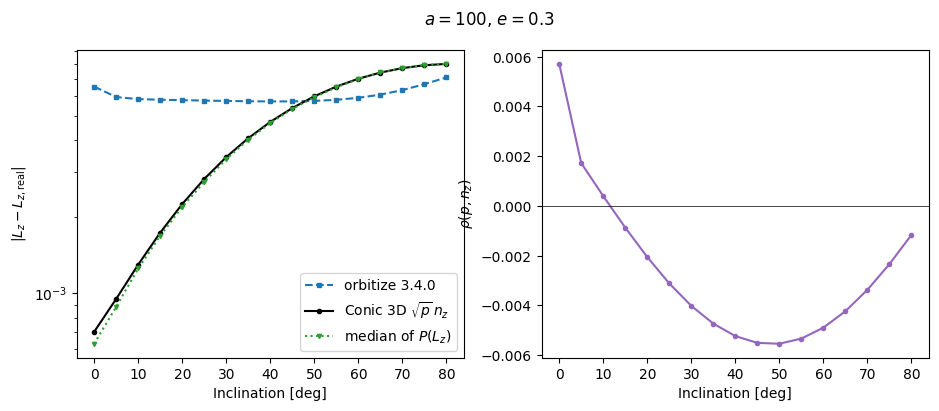

,inclination_deg,Conic 3D fit,Conic 3D posterior,orbitize,"corr(p, n_z)"
0,0.0,0.000703,0.000631,0.006522,0.005719
1,5.0,0.000948,0.000882,0.005934,0.001724
2,10.0,0.001295,0.001251,0.005824,0.000400
3,15.0,0.001731,0.001683,0.005790,-0.000870
4,20.0,0.002245,0.002187,0.005767,-0.002053
5,25.0,0.002820,0.002745,0.005746,-0.003113
6,30.0,0.003439,0.003378,0.005727,-0.004015
7,35.0,0.004083,0.004029,0.005710,-0.004729
8,40.0,0.004733,0.004689,0.005701,-0.005230
9,45.0,0.005370,0.005331,0.005704,-0.005503


In [69]:
# Barrido en inclinacion con a y e fijos

a_inclination_3d = 100.0
inclination_values_3d = np.deg2rad(np.linspace(0, 80, 17))

results_inclination_3d = np.array([
    estimate_Lz_3d_case(a_inclination_3d, ecc_sweep_3d, inclination)
    for inclination in inclination_values_3d
])
(
    Lz_real_inclination_3d,
    Lz_point_inclination_3d,
    Lz_median_inclination_3d,
    Lz_orbitize_inclination_3d,
    correlation_inclination_3d,
) = results_inclination_3d.T

difference_point_inclination_3d = np.abs(
    Lz_point_inclination_3d - Lz_real_inclination_3d
)
difference_median_inclination_3d = np.abs(
    Lz_median_inclination_3d - Lz_real_inclination_3d
)
difference_orbitize_inclination_3d = np.abs(
    Lz_orbitize_inclination_3d - Lz_real_inclination_3d
)

comparison_inclination_3d = pd.DataFrame(
    {
        'inclination_deg': np.rad2deg(inclination_values_3d),
        'Conic 3D fit': difference_point_inclination_3d,
        'Conic 3D posterior': difference_median_inclination_3d,
        'orbitize': difference_orbitize_inclination_3d,
        'corr(p, n_z)': correlation_inclination_3d,
    }
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(np.rad2deg(inclination_values_3d), difference_orbitize_inclination_3d, 's--', markersize=3, color='tab:blue', label='orbitize 3.4.0')
axes[0].plot(np.rad2deg(inclination_values_3d), difference_point_inclination_3d, 'o-', markersize=3, color='k', label=r'Conic 3D $\sqrt{p}\,n_z$')
axes[0].plot(np.rad2deg(inclination_values_3d), difference_median_inclination_3d, 'v:', markersize=3, color='tab:green', label=r'median of $P(L_z)$')
axes[0].set_yscale('log')
axes[0].set_xlabel('Inclination [deg]')
axes[0].set_ylabel(r'$|L_z - L_{z,\mathrm{real}}|$')
axes[0].legend()

axes[1].plot(np.rad2deg(inclination_values_3d), correlation_inclination_3d, 'o-', markersize=3, color='tab:purple')
axes[1].axhline(0, color='k', linewidth=0.5)
axes[1].set_xlabel('Inclination [deg]')
axes[1].set_ylabel(r'$\rho(p, n_z)$')
fig.suptitle(rf'$a = {a_inclination_3d:.0f}$, $e = {ecc_sweep_3d}$')
plt.show()

comparison_inclination_3d

### Barrido en el error de profundidad

orbitize no usa $z$, así que su error es plano en $\sigma_z$: el cruce marca hasta
dónde la profundidad aporta información y desde dónde solo agrega ruido.

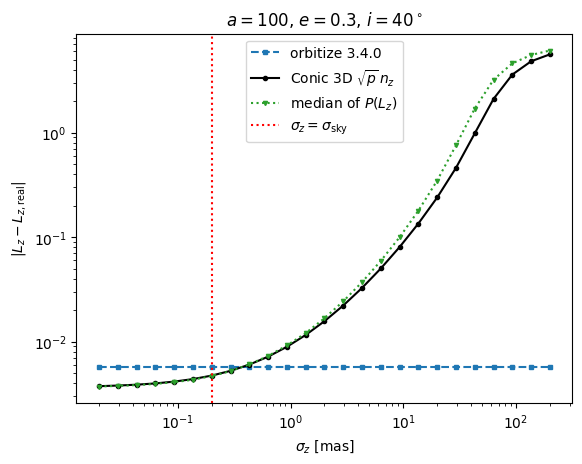

,sigma_z_mas,Conic 3D fit,Conic 3D posterior,orbitize,"corr(p, n_z)"
0,0.020000,0.003748,0.003719,0.005701,0.445551
1,0.029356,0.003799,0.003773,0.005701,0.436096
2,0.043089,0.003873,0.003837,0.005701,0.416293
3,0.063246,0.003983,0.003940,0.005701,0.376332
4,0.092832,0.004144,0.004094,0.005701,0.301019
5,0.136258,0.004382,0.004315,0.005701,0.174531
6,0.200000,0.004733,0.004689,0.005701,-0.005230
7,0.293560,0.005253,0.005223,0.005701,-0.213515
8,0.430887,0.006027,0.006058,0.005701,-0.407373
9,0.632456,0.007183,0.007296,0.005701,-0.553231


In [70]:
# Barrido en el error de profundidad: orbitize no usa z, el metodo propio si

sigma_z_values = np.geomspace(
    astrometric_error_mas / 10, astrometric_error_mas * 1000, 25
)

results_sigma_z = np.array([
    estimate_Lz_3d_case(
        a_inclination_3d, ecc_sweep_3d, inclination_sweep_3d, sigma_z=sigma_z
    )
    for sigma_z in sigma_z_values
])
(
    Lz_real_sigma_z,
    Lz_point_sigma_z,
    Lz_median_sigma_z,
    Lz_orbitize_sigma_z,
    correlation_sigma_z,
) = results_sigma_z.T

difference_point_sigma_z = np.abs(Lz_point_sigma_z - Lz_real_sigma_z)
difference_median_sigma_z = np.abs(Lz_median_sigma_z - Lz_real_sigma_z)
difference_orbitize_sigma_z = np.abs(Lz_orbitize_sigma_z - Lz_real_sigma_z)

comparison_sigma_z = pd.DataFrame(
    {
        'sigma_z_mas': sigma_z_values,
        'Conic 3D fit': difference_point_sigma_z,
        'Conic 3D posterior': difference_median_sigma_z,
        'orbitize': difference_orbitize_sigma_z,
        'corr(p, n_z)': correlation_sigma_z,
    }
)

fig, ax = plt.subplots()
ax.plot(sigma_z_values, difference_orbitize_sigma_z, 's--', markersize=3, color='tab:blue', label='orbitize 3.4.0')
ax.plot(sigma_z_values, difference_point_sigma_z, 'o-', markersize=3, color='k', label=r'Conic 3D $\sqrt{p}\,n_z$')
ax.plot(sigma_z_values, difference_median_sigma_z, 'v:', markersize=3, color='tab:green', label=r'median of $P(L_z)$')
ax.axvline(astrometric_error_mas, color='r', linestyle=':', label=r'$\sigma_z = \sigma_{\mathrm{sky}}$')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$\sigma_z$ [mas]')
ax.set_ylabel(r'$|L_z - L_{z,\mathrm{real}}|$')
ax.set_title(rf'$a = {a_inclination_3d:.0f}$, $e = {ecc_sweep_3d}$, $i = {np.rad2deg(inclination_sweep_3d):.0f}^\circ$')
ax.legend()
plt.show()

comparison_sigma_z

### tomando a, e para agregar la info temporal.

$$
\mathbf{X}
=
(x_1,y_1,z_1,\ldots,x_N,y_N,z_N).
$$

A partir de cada realización de los puntos se obtiene la información geométrica de la órbita,

$$
p
=
p(\mathbf{X}),
$$

y la orientación del plano orbital,

$$
n_z
=
n_z(\mathbf{X}).
$$

Por otra parte, la información temporal permite estimar el período orbital \(P\), y mediante la tercera ley de Kepler,

$$
P^2
=
\frac{4\pi^2a^3}{GM},
$$

se obtiene

$$
\boxed{
a
=
\left(
\frac{GM P^2}{4\pi^2}
\right)^{1/3}
}.
$$

Como

$$
p
=
a(1-e^2),
$$

la excentricidad puede obtenerse como

$$
\boxed{
e
=
\sqrt{
1-\frac{p}{a}
}
}.
$$

Por lo tanto, para cada realización \(k\) de los datos,

$$
p^{(k)}
=
p\left(\mathbf{X}^{(k)}\right),
$$

$$
a^{(k)}
=
a\left(\mathbf{X}^{(k)},\mathbf{t}\right),
$$

y

$$
\boxed{
e^{(k)}
=
\sqrt{
1-\frac{p^{(k)}}{a^{(k)}}
}
}.
$$

De esta manera, las realizaciones

$$
\left(
a^{(k)},
e^{(k)},
n_z^{(k)}
\right)
$$

inducen una distribución conjunta

$$
\boxed{
P(a,e,n_z)
}.
$$

El momento angular específico en una órbita elíptica es

$$
L
=
\sqrt{
GMa(1-e^2)
}.
$$

La componente sobre el eje \(z\) es

$$
\boxed{
L_z
=
\sqrt{
GMa(1-e^2)
}\,n_z
}.
$$

Por lo tanto, la distribución de \(L_z\) viene dada por

$$
\boxed{
P(L_z)
=
\iiint
P(a,e,n_z)
\,
\delta
\left[
L_z
-
\sqrt{
GMa(1-e^2)
}\,n_z
\right]
\,da\,de\,dn_z
}.
$$

En unidades geométricas con

$$
GM=1,
$$

se obtiene

$$
\boxed{
L_z
=
\sqrt{
a(1-e^2)
}\,n_z
}
$$

y

$$
\boxed{
P(L_z)
=
\iiint
P(a,e,n_z)
\,
\delta
\left[
L_z
-
\sqrt{
a(1-e^2)
}\,n_z
\right]
\,da\,de\,dn_z
}.
$$

#### Implementación

El período sale de la propia órbita: con $p$, $e$ y $\omega$ del ajuste cónico, cada
punto tiene anomalía verdadera $\nu_i=\theta_i-\omega$ en el plano orbital, de ahí la
anomalía excéntrica $E_i$ y la anomalía media

$$
M_i=E_i-e\sin E_i=\frac{2\pi}{P}\left(t_i-t_p\right),
$$

que avanza uniformemente. La pendiente de la regresión de $M_i$ contra $t_i$ da
$2\pi/P$, y de ahí $a=(P/2\pi)^{2/3}$ con $GM=1$.

**La ruta del texto es degenerada.** Si $e=\sqrt{1-p/a}$, entonces

$$
a\left(1-e^2\right)
=
a\left[1-\left(1-\frac{p}{a}\right)\right]
=
p,
$$

de modo que

$$
L_z=\sqrt{a(1-e^2)}\,n_z\equiv\sqrt{p}\,n_z
$$

**exactamente**, y el período se cancela: la información temporal no cambia $L_z$
aunque sí determine $a$ y $e$ por separado. Para que el tiempo entre de verdad hay
que romper la circularidad, y la forma natural es tomar $a$ del período y $e$ de los
coeficientes cónicos, $e=\sqrt{B^2+C^2}/A$, que es una estimación independiente. Las
celdas siguientes implementan las dos y comparan.

In [71]:
# Informacion temporal: periodo -> a, y e a partir de a y p


def conic_elements_3d_full(xs, ys, zs):
    """(p, e, omega, n_z) y las coordenadas de los puntos en el plano orbital.

    Es el mismo ajuste conico de la seccion anterior, pero devolviendo tambien e,
    omega y las coordenadas en el plano, que hacen falta para leer las anomalias.
    """
    positions = np.stack([xs, ys, zs], axis=-1)
    normals, first, second = orbital_plane_basis(xs, ys, zs)
    plane_x = np.einsum('...ij,...j->...i', positions, first)
    plane_y = np.einsum('...ij,...j->...i', positions, second)
    A, B, C = np.moveaxis(conic_coefficients(plane_x, plane_y), -1, 0)
    p = 1 / np.where(A > 0, A, np.nan)
    return p, np.hypot(B, C) / A, np.arctan2(C, B), normals[..., 2], plane_x, plane_y


def estimate_period(plane_x, plane_y, eccentricity, omega, times):
    """Periodo geometrico por regresion de la anomalia media contra el tiempo.

    La anomalia verdadera es nu = theta - omega en el plano orbital, de ahi salen
    la anomalia excentrica E y la anomalia media M = E - e sin(E), que avanza
    uniformemente: M = 2 pi (t - t_p) / P. La pendiente del ajuste lineal de M
    contra t da 2 pi / P. La base del plano es dextrogira respecto de la normal,
    de modo que theta crece con el tiempo.
    """
    true_anomaly = np.arctan2(plane_y, plane_x) - omega[..., None]
    e = np.clip(eccentricity, 0, 0.999)[..., None]
    eccentric_anomaly = 2 * np.arctan(
        np.sqrt((1 - e) / (1 + e)) * np.tan(true_anomaly / 2)
    )
    mean_anomaly = np.unwrap(
        eccentric_anomaly - e * np.sin(eccentric_anomaly), axis=-1
    )
    centered_times = times - times.mean()
    centered_anomaly = mean_anomaly - mean_anomaly.mean(axis=-1, keepdims=True)
    slope = np.sum(centered_anomaly * centered_times, axis=-1) / np.sum(
        centered_times ** 2
    )
    return 2 * np.pi / slope


def get_joint_samples_time_3d(
    xs, ys, zs, times, sigma_x, sigma_y, sigma_z, number_of_samples=20000, rng=None
):
    """Muestras de (a, e, n_z) de la conjunta P(a, e, n_z), y tambien p y e_conica.

    Cada realizacion de los puntos da p y n_z como antes; los tiempos dan el
    periodo y con el la tercera ley de Kepler, a = (P / 2 pi)^(2/3) con GM = 1.
    La excentricidad se devuelve en las dos versiones que aparecen en el texto:
    la que sale de a y p, e = sqrt(1 - p / a), y la que sale directamente de los
    coeficientes del ajuste conico, e = sqrt(B^2 + C^2) / A.
    """
    xs = np.asarray(xs, dtype=float)
    ys = np.asarray(ys, dtype=float)
    zs = np.asarray(zs, dtype=float)
    times = np.asarray(times, dtype=float)

    if not (xs.ndim == ys.ndim == zs.ndim == times.ndim == 1):
        raise ValueError("xs, ys, zs y times deben ser unidimensionales.")
    if not (len(xs) == len(ys) == len(zs) == len(times)):
        raise ValueError("xs, ys, zs y times deben tener la misma longitud.")
    if len(xs) < 3:
        raise ValueError("El ajuste conico necesita al menos tres observaciones.")
    if min(sigma_x, sigma_y, sigma_z) <= 0:
        raise ValueError("Las desviaciones estandar deben ser positivas.")

    order = np.argsort(times)
    xs, ys, zs, times = xs[order], ys[order], zs[order], times[order]

    rng = np.random.default_rng() if rng is None else rng
    samples_x = rng.normal(xs, sigma_x, size=(number_of_samples, len(xs)))
    samples_y = rng.normal(ys, sigma_y, size=(number_of_samples, len(ys)))
    samples_z = rng.normal(zs, sigma_z, size=(number_of_samples, len(zs)))

    p, eccentricity_conic, omega, n_z, plane_x, plane_y = conic_elements_3d_full(
        samples_x, samples_y, samples_z
    )
    period = estimate_period(plane_x, plane_y, eccentricity_conic, omega, times)
    a = np.where(period > 0, np.abs(period) / (2 * np.pi), np.nan) ** (2 / 3)
    eccentricity_from_a = np.sqrt(np.clip(1 - p / a, 0, None))

    valid = np.isfinite(a) & np.isfinite(p) & np.isfinite(n_z)
    if valid.sum() < number_of_samples // 2:
        raise RuntimeError("Demasiadas realizaciones invalidas: el ajuste no es estable.")
    return (
        a[valid],
        eccentricity_from_a[valid],
        n_z[valid],
        p[valid],
        eccentricity_conic[valid],
    )

In [72]:
# Verificacion sin ruido de la cadena P -> a -> e

times_check_3d = 2 * np.pi * epochs_check_3d / days_per_orbit_1AU

(
    p_check_full,
    ecc_conic_check,
    omega_check_full,
    nz_check_full,
    plane_x_check,
    plane_y_check,
) = conic_elements_3d_full(xs_check_3d, ys_check_3d, zs_check_3d)

period_check = float(
    estimate_period(
        plane_x_check[None, :],
        plane_y_check[None, :],
        np.array([ecc_conic_check]),
        np.array([omega_check_full]),
        times_check_3d,
    )[0]
)
a_check_from_time = (period_check / (2 * np.pi)) ** (2 / 3)
ecc_check_from_a = np.sqrt(max(1 - p_check_full / a_check_from_time, 0))

pd.DataFrame(
    {
        'quantity': ['P', 'a', 'e (de a y p)', 'e (conica)', 'n_z', 'Lz'],
        'fit': [
            period_check,
            a_check_from_time,
            ecc_check_from_a,
            ecc_conic_check,
            nz_check_full,
            np.sqrt(a_check_from_time * (1 - ecc_check_from_a ** 2)) * nz_check_full,
        ],
        'real': [
            2 * np.pi * a_check_3d ** 1.5,
            a_check_3d,
            ecc_check_3d,
            ecc_check_3d,
            np.cos(inclination_check_3d),
            np.sqrt(a_check_3d * (1 - ecc_check_3d ** 2)) * np.cos(inclination_check_3d),
        ],
    }
)

,quantity,fit,real
0,P,6283.185307,6283.185307
1,a,100.0,100.000000
2,e (de a y p),0.3,0.300000
3,e (conica),0.3,0.300000
4,n_z,0.7660444431189781,0.766044
5,Lz,7.307598,7.307598


La tabla verifica la identidad numéricamente: la columna
`max |Lz - sqrt(p) n_z|` da exactamente $0$ para la ruta del texto, y no para la
versión con $e$ cónica.

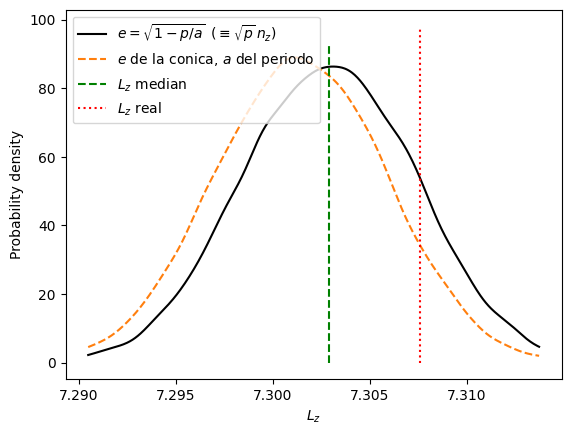

,estimator,median_Lz,std_Lz,max |Lz - sqrt(p) n_z|
0,sqrt(p) n_z,7.302909,0.004491,0.000000
1,"sqrt(a(1-e^2)) n_z, e = sqrt(1-p/a)",7.302909,0.004491,0.000000
2,"sqrt(a(1-e^2)) n_z, e conica",7.301431,0.004432,0.009381


In [73]:
# La ruta del texto es algebraicamente identica a sqrt(p) n_z

a_samples_time, ecc_samples_time, nz_samples_time, p_samples_time, ecc_samples_conic = (
    get_joint_samples_time_3d(
        xs_obs_3d,
        ys_obs_3d,
        zs_obs_3d,
        times_check_3d,
        astrometric_error_mas / parallax_mas,
        astrometric_error_mas / parallax_mas,
        astrometric_error_mas / parallax_mas,
        rng=np.random.default_rng(seed + 7),
    )
)

# e = sqrt(1 - p / a) implica a (1 - e^2) = p, de modo que sqrt(a (1 - e^2)) n_z
# devuelve exactamente sqrt(p) n_z: la informacion temporal se cancela.
Lz_samples_text = np.sqrt(a_samples_time * (1 - ecc_samples_time ** 2)) * nz_samples_time
Lz_samples_geometric = np.sqrt(p_samples_time) * nz_samples_time
# Version no degenerada: a viene del periodo y e de los coeficientes conicos.
# Las realizaciones con e >= 1 (conica no cerrada) se descartan como no validas.
Lz_samples_time_all = (
    np.sqrt(
        np.where(
            ecc_samples_conic < 1,
            a_samples_time * (1 - ecc_samples_conic ** 2),
            np.nan,
        )
    )
    * nz_samples_time
)
Lz_samples_time_informed = Lz_samples_time_all[np.isfinite(Lz_samples_time_all)]

density_text = gaussian_kde(Lz_samples_text)
density_time_informed = gaussian_kde(Lz_samples_time_informed)
Lz_low_time, Lz_high_time = np.quantile(
    np.concatenate([Lz_samples_text, Lz_samples_time_informed]), [0.005, 0.995]
)
Lz_values_time_3d = np.linspace(Lz_low_time, Lz_high_time, 500)

plt.plot(Lz_values_time_3d, density_text(Lz_values_time_3d), 'k', label=r'$e=\sqrt{1-p/a}\;\;(\equiv\sqrt{p}\,n_z)$')
plt.plot(Lz_values_time_3d, density_time_informed(Lz_values_time_3d), color='tab:orange', linestyle='--', label=r'$e$ de la conica, $a$ del periodo')
plt.xlabel(r"$L_z$")
plt.ylabel("Probability density")
plt.vlines(np.median(Lz_samples_text), ymin=0, ymax=plt.gca().get_ylim()[1], color='g', linestyle='--', label=r"$L_z$ median")
plt.vlines(Lz_real_check_3d, ymin=0, ymax=plt.gca().get_ylim()[1], color='r', linestyle=':', label=r"$L_z$ real")
plt.legend(loc='upper left')
plt.show()

pd.DataFrame(
    {
        'estimator': [
            'sqrt(p) n_z',
            'sqrt(a(1-e^2)) n_z, e = sqrt(1-p/a)',
            'sqrt(a(1-e^2)) n_z, e conica',
        ],
        'median_Lz': [
            np.median(Lz_samples_geometric),
            np.median(Lz_samples_text),
            np.median(Lz_samples_time_informed),
        ],
        'std_Lz': [
            np.std(Lz_samples_geometric),
            np.std(Lz_samples_text),
            np.std(Lz_samples_time_informed),
        ],
        'max |Lz - sqrt(p) n_z|': [
            0.0,
            np.nanmax(np.abs(Lz_samples_text - Lz_samples_geometric)),
            np.nanmax(np.abs(Lz_samples_time_all - Lz_samples_geometric)),
        ],
    }
)

#### Comparación con orbitize 3.4.0

Mismos barridos que en la sección anterior, ahora con tres estimadores: el puramente
geométrico $\sqrt{p}\,n_z$, el que usa el período para $a$ y la cónica para $e$, y
orbitize 3.4.0.

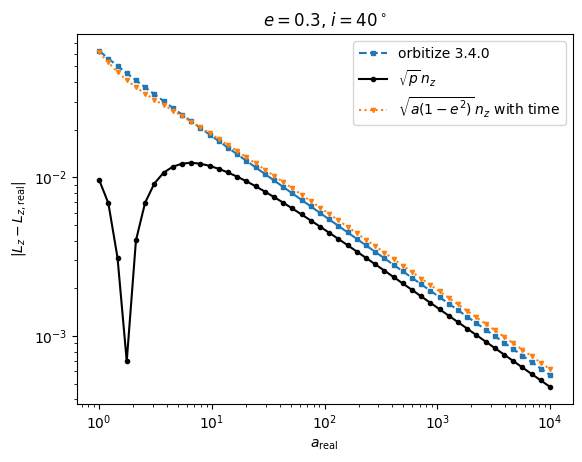

,a_real,Geometric,With time,orbitize,"corr(a, e)"
0,1.000000,0.009646,0.061285,0.062584,-0.339303
1,1.206793,0.006888,0.052928,0.056042,-0.465119
2,1.456348,0.003117,0.046118,0.050332,-0.488666
3,1.757511,0.000695,0.040980,0.045313,-0.508757
4,2.120951,0.004008,0.036995,0.040874,-0.505625
5,2.559548,0.006942,0.033685,0.036928,-0.500610
6,3.088844,0.009146,0.030906,0.033406,-0.495452
7,3.727594,0.010702,0.028572,0.030252,-0.491110
8,4.498433,0.011675,0.026381,0.027420,-0.487933
9,5.428675,0.012196,0.024316,0.024872,-0.485882


In [74]:
# Barrido en a: geometrico, con informacion temporal y orbitize


def estimate_Lz_time_case(a_real, ecc, inclination, sigma_z=None):
    """Estimaciones de Lz con y sin informacion temporal, y la de orbitize."""
    sigma_z = astrometric_error_mas if sigma_z is None else sigma_z
    period_days = 365.25 * np.sqrt(a_real ** 3 / mass_solar)
    epochs = np.linspace(0, period_days, number_of_fit_points, endpoint=False)
    x_true, y_true, z_true = kepler_orbit_3d(
        epochs, a_real, ecc, inclination, aop_sweep_3d, pan_sweep_3d,
        tau=0.13, mass=mass_solar,
    )
    x_observed = x_true + dec_noise_fit / parallax_mas
    y_observed = y_true + ra_noise_fit / parallax_mas
    z_observed = z_true + (sigma_z / astrometric_error_mas) * z_noise_fit / parallax_mas
    times = 2 * np.pi * epochs / days_per_orbit_1AU

    a_samples, _, nz_samples, p_samples, ecc_conic_samples = get_joint_samples_time_3d(
        x_observed,
        y_observed,
        z_observed,
        times,
        astrometric_error_mas / parallax_mas,
        astrometric_error_mas / parallax_mas,
        sigma_z / parallax_mas,
        rng=np.random.default_rng(seed + 7),
    )
    Lz_geometric = float(np.median(np.sqrt(p_samples) * nz_samples))
    # Las realizaciones con e >= 1 no describen una elipse y se descartan.
    Lz_time_informed = float(
        np.nanmedian(
            np.sqrt(
                np.where(
                    ecc_conic_samples < 1,
                    a_samples * (1 - ecc_conic_samples ** 2),
                    np.nan,
                )
            )
            * nz_samples
        )
    )
    # orbitize consume (raoff, deoff) = (este, norte): la profundidad no entra.
    Lz_orbitize = estimate_Lz_orbitize_3d(
        epochs,
        y_observed * parallax_mas,
        x_observed * parallax_mas,
        astrometric_error_mas,
        parallax=parallax_mas,
        mass=mass_solar,
    )
    Lz_real = np.sqrt(a_real * (1 - ecc ** 2)) * np.cos(inclination)
    correlation = float(np.corrcoef(a_samples, ecc_conic_samples)[0, 1])
    return Lz_real, Lz_geometric, Lz_time_informed, Lz_orbitize, correlation


results_a_time = np.array([
    estimate_Lz_time_case(a_real, ecc_sweep_3d, inclination_sweep_3d)
    for a_real in a_fit_values
])
(
    Lz_real_a_time,
    Lz_geometric_a_time,
    Lz_time_a_time,
    Lz_orbitize_a_time,
    correlation_a_time,
) = results_a_time.T

difference_geometric_a_time = np.abs(Lz_geometric_a_time - Lz_real_a_time)
difference_time_a_time = np.abs(Lz_time_a_time - Lz_real_a_time)
difference_orbitize_a_time = np.abs(Lz_orbitize_a_time - Lz_real_a_time)

comparison_a_time = pd.DataFrame(
    {
        'a_real': a_fit_values,
        'Geometric': difference_geometric_a_time,
        'With time': difference_time_a_time,
        'orbitize': difference_orbitize_a_time,
        'corr(a, e)': correlation_a_time,
    }
)

fig, ax = plt.subplots()
ax.plot(a_fit_values, difference_orbitize_a_time, 's--', markersize=3, color='tab:blue', label='orbitize 3.4.0')
ax.plot(a_fit_values, difference_geometric_a_time, 'o-', markersize=3, color='k', label=r'$\sqrt{p}\,n_z$')
ax.plot(a_fit_values, difference_time_a_time, 'v:', markersize=3, color='tab:orange', label=r'$\sqrt{a(1-e^2)}\,n_z$ with time')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$a_{\mathrm{real}}$')
ax.set_ylabel(r'$|L_z - L_{z,\mathrm{real}}|$')
ax.set_title(rf'$e = {ecc_sweep_3d}$, $i = {np.rad2deg(inclination_sweep_3d):.0f}^\circ$')
ax.legend()
plt.show()

comparison_a_time

#### Barrido en inclinación

El panel derecho sigue $\rho(a,e)$, la correlación entre el $a$ del período y la $e$
de la cónica.

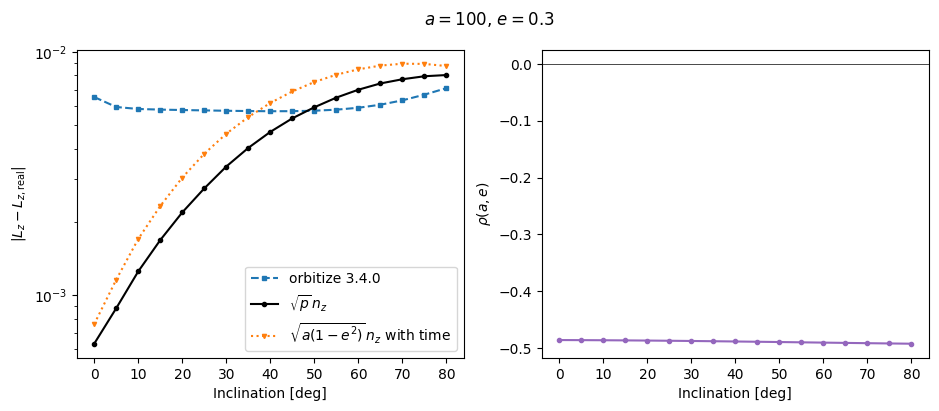

,inclination_deg,Geometric,With time,orbitize,"corr(a, e)"
0,0.0,0.000631,0.000759,0.006522,-0.485527
1,5.0,0.000882,0.001156,0.005934,-0.485664
2,10.0,0.001251,0.001700,0.005824,-0.485859
3,15.0,0.001683,0.002323,0.005790,-0.486110
4,20.0,0.002187,0.003041,0.005767,-0.486413
5,25.0,0.002745,0.003811,0.005746,-0.486762
6,30.0,0.003378,0.004608,0.005727,-0.487153
7,35.0,0.004029,0.005395,0.005710,-0.487579
8,40.0,0.004689,0.006168,0.005701,-0.488035
9,45.0,0.005331,0.006878,0.005704,-0.488514


In [75]:
# Barrido en inclinacion

results_inclination_time = np.array([
    estimate_Lz_time_case(a_inclination_3d, ecc_sweep_3d, inclination)
    for inclination in inclination_values_3d
])
(
    Lz_real_inclination_time,
    Lz_geometric_inclination_time,
    Lz_time_inclination_time,
    Lz_orbitize_inclination_time,
    correlation_inclination_time,
) = results_inclination_time.T

difference_geometric_inclination_time = np.abs(
    Lz_geometric_inclination_time - Lz_real_inclination_time
)
difference_time_inclination_time = np.abs(
    Lz_time_inclination_time - Lz_real_inclination_time
)
difference_orbitize_inclination_time = np.abs(
    Lz_orbitize_inclination_time - Lz_real_inclination_time
)

comparison_inclination_time = pd.DataFrame(
    {
        'inclination_deg': np.rad2deg(inclination_values_3d),
        'Geometric': difference_geometric_inclination_time,
        'With time': difference_time_inclination_time,
        'orbitize': difference_orbitize_inclination_time,
        'corr(a, e)': correlation_inclination_time,
    }
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(np.rad2deg(inclination_values_3d), difference_orbitize_inclination_time, 's--', markersize=3, color='tab:blue', label='orbitize 3.4.0')
axes[0].plot(np.rad2deg(inclination_values_3d), difference_geometric_inclination_time, 'o-', markersize=3, color='k', label=r'$\sqrt{p}\,n_z$')
axes[0].plot(np.rad2deg(inclination_values_3d), difference_time_inclination_time, 'v:', markersize=3, color='tab:orange', label=r'$\sqrt{a(1-e^2)}\,n_z$ with time')
axes[0].set_yscale('log')
axes[0].set_xlabel('Inclination [deg]')
axes[0].set_ylabel(r'$|L_z - L_{z,\mathrm{real}}|$')
axes[0].legend()

axes[1].plot(np.rad2deg(inclination_values_3d), correlation_inclination_time, 'o-', markersize=3, color='tab:purple')
axes[1].axhline(0, color='k', linewidth=0.5)
axes[1].set_xlabel('Inclination [deg]')
axes[1].set_ylabel(r'$\rho(a, e)$')
fig.suptitle(rf'$a = {a_inclination_3d:.0f}$, $e = {ecc_sweep_3d}$')
plt.show()

comparison_inclination_time

#### Barrido en el error de profundidad

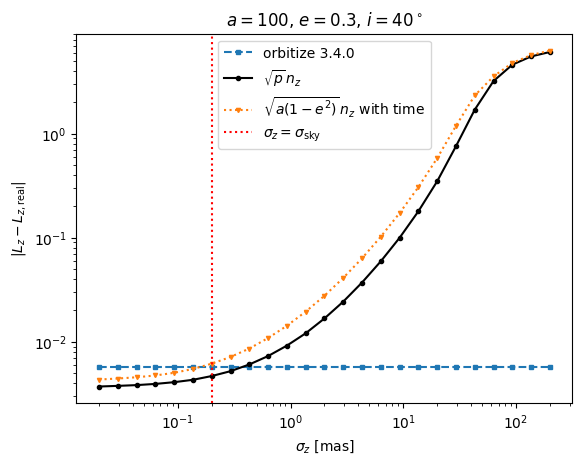

,sigma_z_mas,Geometric,With time,orbitize,"corr(a, e)"
0,0.020000,0.003719,0.004342,0.005701,-0.522008
1,0.029356,0.003773,0.004438,0.005701,-0.521556
2,0.043089,0.003837,0.004565,0.005701,-0.520560
3,0.063246,0.003940,0.004749,0.005701,-0.518406
4,0.092832,0.004094,0.005038,0.005701,-0.513875
5,0.136258,0.004315,0.005484,0.005701,-0.504783
6,0.200000,0.004689,0.006168,0.005701,-0.488035
7,0.293560,0.005223,0.007151,0.005701,-0.461403
8,0.430887,0.006058,0.008617,0.005701,-0.427417
9,0.632456,0.007296,0.010868,0.005701,-0.394163


In [76]:
# Barrido en el error de profundidad

results_sigma_z_time = np.array([
    estimate_Lz_time_case(
        a_inclination_3d, ecc_sweep_3d, inclination_sweep_3d, sigma_z=sigma_z
    )
    for sigma_z in sigma_z_values
])
(
    Lz_real_sigma_z_time,
    Lz_geometric_sigma_z_time,
    Lz_time_sigma_z_time,
    Lz_orbitize_sigma_z_time,
    correlation_sigma_z_time,
) = results_sigma_z_time.T

difference_geometric_sigma_z_time = np.abs(
    Lz_geometric_sigma_z_time - Lz_real_sigma_z_time
)
difference_time_sigma_z_time = np.abs(Lz_time_sigma_z_time - Lz_real_sigma_z_time)
difference_orbitize_sigma_z_time = np.abs(
    Lz_orbitize_sigma_z_time - Lz_real_sigma_z_time
)

comparison_sigma_z_time = pd.DataFrame(
    {
        'sigma_z_mas': sigma_z_values,
        'Geometric': difference_geometric_sigma_z_time,
        'With time': difference_time_sigma_z_time,
        'orbitize': difference_orbitize_sigma_z_time,
        'corr(a, e)': correlation_sigma_z_time,
    }
)

fig, ax = plt.subplots()
ax.plot(sigma_z_values, difference_orbitize_sigma_z_time, 's--', markersize=3, color='tab:blue', label='orbitize 3.4.0')
ax.plot(sigma_z_values, difference_geometric_sigma_z_time, 'o-', markersize=3, color='k', label=r'$\sqrt{p}\,n_z$')
ax.plot(sigma_z_values, difference_time_sigma_z_time, 'v:', markersize=3, color='tab:orange', label=r'$\sqrt{a(1-e^2)}\,n_z$ with time')
ax.axvline(astrometric_error_mas, color='r', linestyle=':', label=r'$\sigma_z = \sigma_{\mathrm{sky}}$')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$\sigma_z$ [mas]')
ax.set_ylabel(r'$|L_z - L_{z,\mathrm{real}}|$')
ax.set_title(rf'$a = {a_inclination_3d:.0f}$, $e = {ecc_sweep_3d}$, $i = {np.rad2deg(inclination_sweep_3d):.0f}^\circ$')
ax.legend()
plt.show()

comparison_sigma_z_time

# Schwartzchild

$$
\textbf{Estimación de }L_z\textbf{ en Schwarzschild}
$$

Sea el conjunto de observaciones astrométricas

$$
\mathcal{D}
=
\left\{
t_i,
x_i,
y_i,
\sigma_{x_i},
\sigma_{y_i}
\right\}_{i=1}^{N}.
$$

La órbita se describe mediante los parámetros

$$
\boldsymbol{\theta}
=
\left(
a,e,i,\Omega,\omega,t_p
\right),
$$

donde $a$ es el semieje mayor, $e$ la excentricidad, $i$ la
inclinación del plano orbital, $\Omega$ la longitud del nodo
ascendente, $\omega$ el argumento del periastro y $t_p$ el tiempo
de paso por el periastro.

Para un conjunto dado de parámetros $\boldsymbol{\theta}$, la
integración de la geodésica temporal en la métrica de Schwarzschild
produce las posiciones predichas

$$
x_{\mathrm{mod}}(t_i;\boldsymbol{\theta}),
\qquad
y_{\mathrm{mod}}(t_i;\boldsymbol{\theta}).
$$

Suponiendo errores gaussianos independientes en las dos coordenadas,
la verosimilitud astrométrica está dada por

$$
\mathcal{L}
\left(
\mathcal{D}\mid\boldsymbol{\theta}
\right)
=
\prod_{i=1}^{N}
\frac{1}{2\pi\sigma_{x_i}\sigma_{y_i}}
\exp
\left[
-\frac{1}{2}
\left(
\frac{
x_i-x_{\mathrm{mod}}(t_i;\boldsymbol{\theta})
}{
\sigma_{x_i}
}
\right)^2
-\frac{1}{2}
\left(
\frac{
y_i-y_{\mathrm{mod}}(t_i;\boldsymbol{\theta})
}{
\sigma_{y_i}
}
\right)^2
\right].
$$

Equivalentemente,

$$
\ln\mathcal{L}
=
-\frac{1}{2}
\sum_{i=1}^{N}
\left[
\frac{
\left(
x_i-x_{\mathrm{mod}}(t_i;\boldsymbol{\theta})
\right)^2
}{
\sigma_{x_i}^{2}
}
+
\frac{
\left(
y_i-y_{\mathrm{mod}}(t_i;\boldsymbol{\theta})
\right)^2
}{
\sigma_{y_i}^{2}
}
\right]
+\mathrm{const}.
$$

Aplicando el teorema de Bayes,

$$
P(\boldsymbol{\theta}\mid\mathcal{D})
=
\frac{
\mathcal{L}(\mathcal{D}\mid\boldsymbol{\theta})
P(\boldsymbol{\theta})
}{
P(\mathcal{D})
}.
$$

Por tanto, el ajuste relativista proporciona muestras del posterior

$$
P
\left(
a,e,i,\Omega,\omega,t_p
\mid
\mathcal{D}
\right).
$$

Si únicamente se requieren los parámetros relevantes para el momento
angular, se marginalizan los restantes parámetros,

$$
P(a,e,i\mid\mathcal{D})
=
\int
P
\left(
a,e,i,\Omega,\omega,t_p
\mid
\mathcal{D}
\right)
\,d\Omega\,d\omega\,dt_p.
$$

En la parametrización de Darwin,

$$
r(\chi)
=
\frac{p}{1+e\cos\chi},
$$

y la relación entre el semilatus rectum $p$ y el semieje mayor $a$ es

$$
p=a(1-e^2),
$$

cuando $a$ está expresado en unidades de $M$.

Para una geodésica ligada de Schwarzschild, el momento angular
específico satisface

$$
L^2
=
\frac{p^2}
{p-3-e^2}.
$$

Por tanto,

$$
L(a,e)
=
\frac{
a(1-e^2)
}{
\sqrt{
a(1-e^2)-3-e^2
}
}.
$$

Si el eje $z$ se escoge de modo que la componente de la normal orbital
en esa dirección sea

$$
n_z=\cos i,
$$

entonces

$$
L_z
=
L\cos i,
$$

y, por consiguiente,

$$
\boxed{
L_z(a,e,i)
=
\cos i\,
\frac{
a(1-e^2)
}{
\sqrt{
a(1-e^2)-3-e^2
}
}
}.
$$

La distribución posterior de $L_z$ se obtiene propagando el posterior
orbital:

$$
P(L_z\mid\mathcal{D})
=
\iiint
P(a,e,i\mid\mathcal{D})
\,
\delta
\left[
L_z
-
\cos i\,
\frac{
a(1-e^2)
}{
\sqrt{
a(1-e^2)-3-e^2
}
}
\right]
\,da\,de\,di.
$$

En la práctica, si el ajuste mediante MCMC produce muestras

$$
\left\{
a^{(k)},e^{(k)},i^{(k)}
\right\}_{k=1}^{N_s},
$$

no es necesario evaluar explícitamente la integral anterior. Para
cada muestra del posterior se calcula

$$
\boxed{
L_z^{(k)}
=
\cos i^{(k)}
\frac{
a^{(k)}
\left[
1-\left(e^{(k)}\right)^2
\right]
}{
\sqrt{
a^{(k)}
\left[
1-\left(e^{(k)}\right)^2
\right]
-3-\left(e^{(k)}\right)^2
}
}
}.
$$

El conjunto

$$
\left\{
L_z^{(k)}
\right\}_{k=1}^{N_s}
$$

$$

## Implementación

El modelo $x_{\mathrm{mod}}(t_i;\boldsymbol\theta)$ se obtiene integrando la geodésica
temporal con **pygro 1.0.3**. La métrica se declara por su elemento de línea,

$$
ds^2=-\left(1-\frac{2M}{r}\right)dt^2+\left(1-\frac{2M}{r}\right)^{-1}dr^2
+r^2\left(d\theta^2+\sin^2\theta\,d\varphi^2\right),
$$

y `pygro.Orbit.set_orbital_parameters` acepta exactamente
$(t_P,a,e,i,\omega,\Omega)$, el mismo vector $\boldsymbol\theta$ del planteamiento.
Todo va en unidades geométricas $G=M=c=1$: los radios en unidades de $M$ y los
tiempos en $M/c$.

Dos detalles de la integración. pygro avanza en **tiempo propio** y devuelve
$(t,r,\theta,\varphi)$, mientras que los datos están etiquetados por el **tiempo
coordenado**, así que hay que interpolar contra la columna $t$; el error de esa
interpolación es $4\times10^{-5}\,M$, muy por debajo de $\sigma$. Y como la
integración arranca en el pericentro con $t=0$, el parámetro $t_P$ entra
simplemente desplazando los tiempos pedidos, sin reintegrar.

El plano del cielo es $(x,y)$ y la línea de visión es $z$, de modo que $i=0$ deja la
órbita de frente y la normal del plano orbital cumple $n_z=\cos i$, igual que en la
sección anterior. Los datos son solo la astrometría proyectada $(x_i,y_i,\sigma)$:
la profundidad no entra, tal como está escrita la verosimilitud.

La comparación es contra el ajuste kepleriano de orbitize 3.4.0 sobre **los mismos
datos**, lo que mide directamente cuánto sesga ajustar una elipse a una geodésica que
precesa. En este marco los elementos de orbitize `(inc, aop, pan)` coinciden con
$(i,\omega,\Omega)$ de pygro, así que el ajuste kepleriano sirve además de semilla
del relativista.

In [77]:
# Metrica de Schwarzschild y modelo de orbita en pygro

import logging
import warnings

import pygro

# pygro llama a logging.basicConfig al importarse: sin esto cada integracion
# escribe en el notebook, y durante los ajustes son decenas de miles de lineas.
logging.getLogger().setLevel(logging.ERROR)
warnings.filterwarnings('ignore')

# Unidades geometricas G = M = c = 1: los radios van en unidades de M y los
# tiempos en unidades de M / c.
schwarzschild_metric = pygro.Metric(
    name='schwarzschild',
    coordinates=['t', 'r', 'theta', 'phi'],
    line_element=(
        '-(1-2*M/r)*dt**2 + 1/(1-2*M/r)*dr**2 '
        '+ r**2*(dtheta**2 + sin(theta)**2*dphi**2)'
    ),
    transform=['t', 'r*sin(theta)*cos(phi)', 'r*sin(theta)*sin(phi)', 'r*cos(theta)'],
    M=1,
)
geodesic_engine = pygro.GeodesicEngine(schwarzschild_metric, backend='lambdify')


def schwarzschild_orbit(a, e, i, omega, Omega, times, number_of_nodes=4000):
    """Posiciones cartesianas de la geodesica temporal en los tiempos pedidos.

    pygro integra en tiempo propio y devuelve (t, r, theta, phi); aqui se
    interpola contra el tiempo coordenado t, que es el que aparece en los datos.
    La integracion arranca en el pericentro con t = 0, de modo que el tiempo de
    paso por pericentro t_P entra simplemente desplazando los tiempos pedidos.

    El plano del cielo es (x, y) y la linea de vision es z, con lo cual una
    orbita con i = 0 queda de frente y la normal del plano orbital cumple
    n_z = cos(i).
    """
    times = np.atleast_1d(np.asarray(times, dtype=float))
    orbit = pygro.Orbit(geodesic_engine)
    orbit.set_orbital_parameters(t_P=0.0, a=a, e=e, i=i, omega=omega, Omega=Omega)

    proper_time_end = 1.3 * (times.max() - min(times.min(), 0.0)) + 10.0
    orbit.integrate(proper_time_end, max(proper_time_end / 5000, 1e-3), verbose=False)

    nodes = np.linspace(0, orbit.geo.tau[-1], number_of_nodes)
    coordinate_time, radius, latitude, longitude = orbit.geo.x_int(nodes).T

    r = np.interp(times, coordinate_time, radius)
    theta = np.interp(times, coordinate_time, np.unwrap(latitude))
    phi = np.interp(times, coordinate_time, np.unwrap(longitude))

    return (
        r * np.sin(theta) * np.cos(phi),
        r * np.sin(theta) * np.sin(phi),
        r * np.cos(theta),
        orbit,
    )


def angular_momentum(a, e):
    """L = p / sqrt(p - 3 - e^2), con p = a (1 - e^2) en unidades de M."""
    p = a * (1 - e ** 2)
    return p / np.sqrt(p - 3 - e ** 2)


def Lz_schwarzschild(a, e, i):
    """L_z = L(a, e) cos(i), la formula recuadrada de la seccion."""
    return angular_momentum(a, e) * np.cos(i)

In [78]:
# Verificacion sin ruido

a_schw = 100.0
ecc_schw = 0.3
inclination_schw = np.deg2rad(40)
omega_schw = 0.7
Omega_schw = 1.1
number_of_schw_points = 20
sigma_schw = 0.2

radial_period_schw = 2 * np.pi * a_schw ** 1.5
times_schw = np.linspace(
    0, radial_period_schw, number_of_schw_points, endpoint=False
)

x_schw, y_schw, z_schw, orbit_schw = schwarzschild_orbit(
    a_schw, ecc_schw, inclination_schw, omega_schw, Omega_schw, times_schw
)

# n_z medido sobre el plano orbital, igual que en la seccion anterior.
positions_schw = np.stack([x_schw, y_schw, z_schw], axis=-1)
normal_schw = np.linalg.eigh(positions_schw.T @ positions_schw)[1][:, 0]
areal_schw = np.cross(positions_schw[:-1], positions_schw[1:]).sum(axis=0)
normal_schw = normal_schw * np.sign(normal_schw @ areal_schw)

radii_schw = np.linalg.norm(positions_schw, axis=1)
# Precesion del periastro por orbita radial: 6 pi M / p en el limite debil.
precession_schw = 6 * np.pi / (a_schw * (1 - ecc_schw ** 2))

pd.DataFrame(
    {
        'quantity': [
            'L (pygro)',
            'r_p',
            'n_z',
            'L_z',
            'precesion por orbita [rad]',
        ],
        'fit': [
            orbit_schw.L,
            radii_schw.min(),
            normal_schw[2],
            orbit_schw.L * normal_schw[2],
            precession_schw,
        ],
        'formula': [
            angular_momentum(a_schw, ecc_schw),
            a_schw * (1 - ecc_schw),
            np.cos(inclination_schw),
            Lz_schwarzschild(a_schw, ecc_schw, inclination_schw),
            precession_schw,
        ],
    }
)

,quantity,fit,formula
0,L (pygro),9.705597,9.705597
1,r_p,70.000000,70.000000
2,n_z,0.766045,0.766044
3,L_z,7.434919,7.434919
4,precesion por orbita [rad],0.207138,0.207138


In [79]:
# Ajuste kepleriano (semilla) y ajuste relativista con pygro

GEOMETRIC_TIME_TO_DAYS = days_per_orbit_1AU / (2 * np.pi)


def fit_kepler_elements(times, sky_x, sky_y, sigma):
    """Ajuste kepleriano con orbitize 3.4.0 sobre (deoff, raoff) = (x, y).

    Sirve para dos cosas: es el estimador newtoniano con el que se compara, y da
    la semilla del ajuste relativista. En este marco los elementos de orbitize
    (inc, aop, pan) coinciden con (i, omega, Omega) de pygro.
    """
    epochs = np.asarray(times, dtype=float) * GEOMETRIC_TIME_TO_DAYS
    separation = np.hypot(sky_x, sky_y)
    a_initial = 0.5 * (separation.min() + separation.max())

    def residuals(parameters):
        log_a, e, inclination, aop, node, tau = parameters
        model_ra, model_dec, _ = kepler.calc_orbit(
            epochs, sma=np.exp(log_a), ecc=e, inc=inclination, aop=aop, pan=node,
            tau=tau, plx=1, mtot=1, tau_ref_epoch=0, use_c=False,
        )
        return np.concatenate([
            (model_dec - sky_x) / sigma,
            (model_ra - sky_y) / sigma,
        ])

    fits = [
        least_squares(
            residuals,
            x0=[np.log(a_initial), 0.3, inclination_initial, aop_initial, node_initial, tau_initial],
            bounds=(
                [np.log(a_initial / 10), 0, 0, 0, 0, 0],
                [np.log(a_initial * 10), 0.95, np.pi / 2, 2 * np.pi, 2 * np.pi, 1],
            ),
        )
        for tau_initial in [0.1, 0.6]
        for inclination_initial in [0.3, 0.9, 1.3]
        for aop_initial in [1.0, 4.0]
        for node_initial in [1.0, 4.0]
    ]
    best_fit = min(fits, key=lambda fit: np.sum(fit.fun ** 2))
    log_a, e, inclination, aop, node, tau = best_fit.x
    return np.exp(log_a), e, inclination, aop, node, tau


def relativistic_residuals(parameters, times, sky_x, sky_y, sigma):
    """Residuos normalizados de la verosimilitud astrometrica de la seccion."""
    log_a, e, i, omega, Omega, t_P = parameters
    model_x, model_y, _, _ = schwarzschild_orbit(
        np.exp(log_a), e, i, omega, Omega, times - t_P
    )
    return np.concatenate([
        (model_x - sky_x) / sigma,
        (model_y - sky_y) / sigma,
    ])


def fit_relativistic(times, sky_x, sky_y, sigma, seed_parameters):
    """Minimos cuadrados sobre (a, e, i, omega, Omega, t_P) con el modelo de pygro.

    Se arranca desde la solucion kepleriana y desde su version con
    (omega, Omega) -> (omega + pi, Omega + pi), que es la rama degenerada que
    aparece cuando la precesion relativista es grande.
    """
    a_seed, e_seed, i_seed, omega_seed, Omega_seed, t_P_seed = seed_parameters
    period = 2 * np.pi * a_seed ** 1.5

    fits = []
    for angle_shift in [0.0, np.pi]:
        try:
            fits.append(least_squares(
                relativistic_residuals,
                x0=[
                    np.log(a_seed),
                    min(max(e_seed, 1e-3), 0.94),
                    i_seed,
                    (omega_seed + angle_shift) % (2 * np.pi),
                    (Omega_seed + angle_shift) % (2 * np.pi),
                    t_P_seed,
                ],
                bounds=(
                    [np.log(a_seed / 3), 0, 0, -np.inf, -np.inf, t_P_seed - period],
                    [np.log(a_seed * 3), 0.95, np.pi / 2, np.inf, np.inf, t_P_seed + period],
                ),
                args=(times, sky_x, sky_y, sigma),
                xtol=1e-10,
                ftol=1e-10,
            ))
        except Exception:
            continue
    if not fits:
        raise RuntimeError("Ningun arranque del ajuste relativista converge.")
    return min(fits, key=lambda fit: np.sum(fit.fun ** 2))


def generate_schwarzschild_data(a, e, i, omega, Omega, sigma, rng):
    """Astrometria proyectada de una geodesica de Schwarzschild con ruido gaussiano."""
    period = 2 * np.pi * a ** 1.5
    times = np.linspace(0, period, number_of_schw_points, endpoint=False)
    x_true, y_true, _, orbit = schwarzschild_orbit(a, e, i, omega, Omega, times)
    sky_x = x_true + rng.normal(0, sigma, len(x_true))
    sky_y = y_true + rng.normal(0, sigma, len(y_true))
    return times, sky_x, sky_y, orbit


def estimate_Lz_schwarzschild_case(a, e, i, omega=0.7, Omega=1.1, sigma=None):
    """L_z real, relativista ajustado y newtoniano ajustado para una orbita."""
    sigma = sigma_schw if sigma is None else sigma
    times, sky_x, sky_y, orbit = generate_schwarzschild_data(
        a, e, i, omega, Omega, sigma, np.random.default_rng(seed + 9)
    )

    a_kepler, e_kepler, i_kepler, omega_kepler, Omega_kepler, tau_kepler = (
        fit_kepler_elements(times, sky_x, sky_y, sigma)
    )
    Lz_newtonian = np.sqrt(a_kepler * (1 - e_kepler ** 2)) * np.cos(i_kepler)

    seed_parameters = (
        a_kepler, e_kepler, i_kepler, omega_kepler, Omega_kepler,
        tau_kepler * 2 * np.pi * a_kepler ** 1.5,
    )
    best_fit = fit_relativistic(times, sky_x, sky_y, sigma, seed_parameters)
    a_fit, e_fit, i_fit = np.exp(best_fit.x[0]), best_fit.x[1], best_fit.x[2]

    return (
        orbit.L * np.cos(i),
        Lz_schwarzschild(a_fit, e_fit, i_fit),
        Lz_newtonian,
    )

## Posterior por MCMC

Cada evaluación de la verosimilitud cuesta una integración de geodésica (~0.14 s), así
que el muestreo se corta por **tiempo de reloj** y no por número de pasos: se itera
`emcee` y se detiene al agotar el presupuesto de 35 minutos. Las cadenas arrancan en
una bola estrecha alrededor del óptimo de mínimos cuadrados, con prior uniforme en
$a$, en $\cos i$ y en los ángulos, y descartando las órbitas no ligadas
($p\leq 6+2e$).

De cada muestra $\left(a^{(k)},e^{(k)},i^{(k)}\right)$ sale $L_z^{(k)}$ por la
fórmula recuadrada, sin evaluar la integral triple.

In [80]:
# Posterior P(L_z | D) por MCMC, con presupuesto de reloj

import multiprocessing
import time

import emcee

MCMC_TIME_BUDGET_SECONDS = 35 * 60

times_mcmc, sky_x_mcmc, sky_y_mcmc, orbit_mcmc = generate_schwarzschild_data(
    a_schw, ecc_schw, inclination_schw, omega_schw, Omega_schw,
    sigma_schw, np.random.default_rng(seed + 9),
)
Lz_real_schw = orbit_mcmc.L * np.cos(inclination_schw)


def log_probability_schwarzschild(parameters):
    """log P(theta | D) con priors uniformes en a, e, cos(i) y los angulos."""
    log_a, e, i, omega, Omega, t_P = parameters
    a = np.exp(log_a)
    if not (0 <= e < 0.95 and 0 <= i <= np.pi / 2 and 10 < a < 1e5):
        return -np.inf
    # p > 6 + 2 e es la condicion de orbita ligada estable en Schwarzschild.
    if a * (1 - e ** 2) <= 6 + 2 * e:
        return -np.inf
    try:
        model_x, model_y, _, _ = schwarzschild_orbit(
            a, e, i, omega, Omega, times_mcmc - t_P
        )
    except Exception:
        return -np.inf
    chi_squared = np.sum(
        ((model_x - sky_x_mcmc) / sigma_schw) ** 2
        + ((model_y - sky_y_mcmc) / sigma_schw) ** 2
    )
    # Prior uniforme en a y en cos(i): p(log a) ~ a, p(i) ~ sin(i).
    return -chi_squared / 2 + log_a + np.log(max(np.sin(i), 1e-300))


a_seed_mcmc, e_seed_mcmc, i_seed_mcmc, omega_seed_mcmc, Omega_seed_mcmc, tau_seed_mcmc = (
    fit_kepler_elements(times_mcmc, sky_x_mcmc, sky_y_mcmc, sigma_schw)
)
best_fit_mcmc = fit_relativistic(
    times_mcmc, sky_x_mcmc, sky_y_mcmc, sigma_schw,
    (a_seed_mcmc, e_seed_mcmc, i_seed_mcmc, omega_seed_mcmc, Omega_seed_mcmc,
     tau_seed_mcmc * 2 * np.pi * a_seed_mcmc ** 1.5),
)

number_of_walkers = 32
number_of_parameters = 6
scatter_mcmc = np.array([1e-5, 1e-5, 1e-5, 1e-4, 1e-4, 1e-2])
initial_positions = best_fit_mcmc.x + scatter_mcmc * np.random.default_rng(
    seed + 10
).normal(size=(number_of_walkers, number_of_parameters))
initial_positions[:, 1] = np.clip(initial_positions[:, 1], 1e-4, 0.94)
initial_positions[:, 2] = np.clip(initial_positions[:, 2], 1e-4, np.pi / 2 - 1e-4)

# El corte es por tiempo de reloj, no por numero de pasos: se itera el sampler y
# se detiene al agotar el presupuesto.
start_time = time.time()
number_of_steps = 0
with multiprocessing.get_context('fork').Pool() as pool:
    sampler = emcee.EnsembleSampler(
        number_of_walkers,
        number_of_parameters,
        log_probability_schwarzschild,
        pool=pool,
    )
    for _ in sampler.sample(initial_positions, iterations=1_000_000):
        number_of_steps += 1
        if time.time() - start_time > MCMC_TIME_BUDGET_SECONDS:
            break
elapsed_mcmc = time.time() - start_time

burn_in = number_of_steps // 4
chain_mcmc = sampler.get_chain(discard=burn_in, flat=True)
Lz_samples_mcmc = Lz_schwarzschild(
    np.exp(chain_mcmc[:, 0]), chain_mcmc[:, 1], chain_mcmc[:, 2]
)

pd.DataFrame(
    {
        'quantity': [
            'pasos',
            'tiempo [s]',
            'burn-in',
            'muestras',
            'tasa de aceptacion',
        ],
        'value': [
            number_of_steps,
            elapsed_mcmc,
            burn_in,
            len(Lz_samples_mcmc),
            float(np.mean(sampler.acceptance_fraction)),
        ],
    }
)

,quantity,value
0,pasos,4530.000000
1,tiempo [s],2100.435655
2,burn-in,1132.000000
3,muestras,108736.000000
4,tasa de aceptacion,0.508175


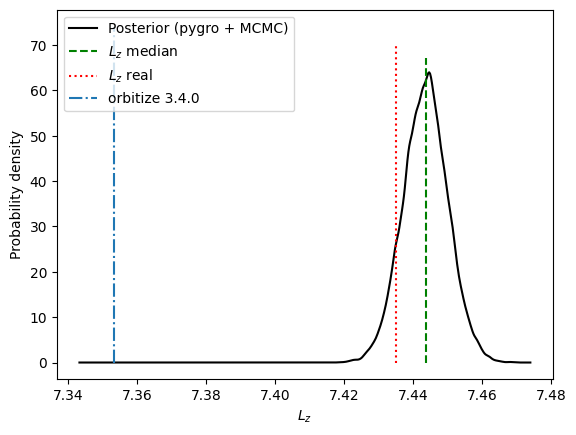

,quantile,Lz,Lz real,orbitize
0,0.16,7.437124,7.434919,7.353193
1,0.50,7.443651,7.434919,7.353193
2,0.84,7.449981,7.434919,7.353193


In [81]:
Lz_low_mcmc, Lz_median_mcmc, Lz_high_mcmc = np.quantile(
    Lz_samples_mcmc, [0.16, 0.50, 0.84]
)
Lz_newtonian_mcmc = np.sqrt(
    a_seed_mcmc * (1 - e_seed_mcmc ** 2)
) * np.cos(i_seed_mcmc)

density_mcmc = gaussian_kde(Lz_samples_mcmc)
Lz_plot_low, Lz_plot_high = np.quantile(Lz_samples_mcmc, [0.001, 0.999])
Lz_values_mcmc = np.linspace(
    min(Lz_plot_low, Lz_newtonian_mcmc) - 0.01,
    max(Lz_plot_high, Lz_newtonian_mcmc) + 0.01,
    500,
)

plt.plot(Lz_values_mcmc, density_mcmc(Lz_values_mcmc), 'k', label='Posterior (pygro + MCMC)')
plt.xlabel(r"$L_z$")
plt.ylabel("Probability density")
plt.vlines(Lz_median_mcmc, ymin=0, ymax=plt.gca().get_ylim()[1], color='g', linestyle='--', label=r"$L_z$ median")
plt.vlines(Lz_real_schw, ymin=0, ymax=plt.gca().get_ylim()[1], color='r', linestyle=':', label=r"$L_z$ real")
plt.vlines(Lz_newtonian_mcmc, ymin=0, ymax=plt.gca().get_ylim()[1], color='tab:blue', linestyle='-.', label='orbitize 3.4.0')
plt.legend()
plt.show()

pd.DataFrame(
    {
        'quantile': [0.16, 0.50, 0.84],
        'Lz': [Lz_low_mcmc, Lz_median_mcmc, Lz_high_mcmc],
        'Lz real': [Lz_real_schw] * 3,
        'orbitize': [Lz_newtonian_mcmc] * 3,
    }
)

## Comparación con orbitize 3.4.0

Mismos barridos que en las secciones anteriores. La línea punteada es el sesgo
esperado del estimador kepleriano: como

$$
\frac{L_{\mathrm{Schw}}}{L_{\mathrm{Kepler}}}
=
\sqrt{\frac{p}{p-3-e^2}}
\simeq
1+\frac{3+e^2}{2p},
$$

el error de ignorar la relatividad debería ir como
$\left|\Delta L_z\right|\simeq L_z\left(3+e^2\right)/2p$.

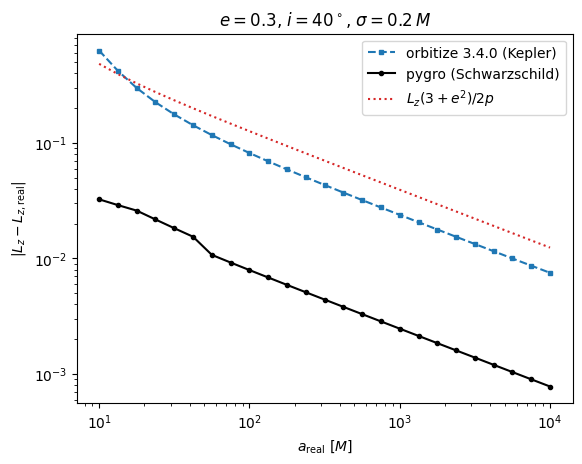

,a_real,Schwarzschild (pygro),Kepler (orbitize),sesgo predicho
0,10.000000,0.032462,0.629498,0.482775
1,13.335214,0.028939,0.419602,0.393529
2,17.782794,0.025931,0.298381,0.327095
3,23.713737,0.021738,0.224694,0.275245
4,31.622777,0.018264,0.176230,0.233522
5,42.169650,0.015409,0.142091,0.199247
6,56.234133,0.010734,0.116746,0.170681
7,74.989421,0.009214,0.097206,0.146630
8,100.000000,0.007934,0.081725,0.126230
9,133.352143,0.006841,0.069207,0.108834


In [82]:
# Barrido en a: ajuste relativista contra ajuste kepleriano

a_schw_values = np.geomspace(10, 10_000, 25)


def sweep_point(arguments):
    a, e, i = arguments
    return estimate_Lz_schwarzschild_case(a, e, i)


with multiprocessing.get_context('fork').Pool() as pool:
    results_a_schw = np.array(pool.map(
        sweep_point, [(a, ecc_schw, inclination_schw) for a in a_schw_values]
    ))

Lz_real_a_schw, Lz_relativistic_a_schw, Lz_newtonian_a_schw = results_a_schw.T
difference_relativistic_a = np.abs(Lz_relativistic_a_schw - Lz_real_a_schw)
difference_newtonian_a = np.abs(Lz_newtonian_a_schw - Lz_real_a_schw)

# Sesgo esperado del estimador newtoniano: L_rel / L_newt = sqrt(p / (p - 3 - e^2)),
# de modo que |Delta L_z| ~ L_z (3 + e^2) / (2 p).
p_schw_values = a_schw_values * (1 - ecc_schw ** 2)
predicted_bias = (
    Lz_real_a_schw * (3 + ecc_schw ** 2) / (2 * p_schw_values)
)

comparison_a_schw = pd.DataFrame(
    {
        'a_real': a_schw_values,
        'Schwarzschild (pygro)': difference_relativistic_a,
        'Kepler (orbitize)': difference_newtonian_a,
        'sesgo predicho': predicted_bias,
    }
)

fig, ax = plt.subplots()
ax.plot(a_schw_values, difference_newtonian_a, 's--', markersize=3, color='tab:blue', label='orbitize 3.4.0 (Kepler)')
ax.plot(a_schw_values, difference_relativistic_a, 'o-', markersize=3, color='k', label='pygro (Schwarzschild)')
ax.plot(a_schw_values, predicted_bias, ':', color='tab:red', label=r'$L_z(3+e^2)/2p$')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$a_{\mathrm{real}}\ [M]$')
ax.set_ylabel(r'$|L_z - L_{z,\mathrm{real}}|$')
ax.set_title(rf'$e = {ecc_schw}$, $i = {np.rad2deg(inclination_schw):.0f}^\circ$, $\sigma = {sigma_schw}\,M$')
ax.legend()
plt.show()

comparison_a_schw

## Barrido en excentricidad

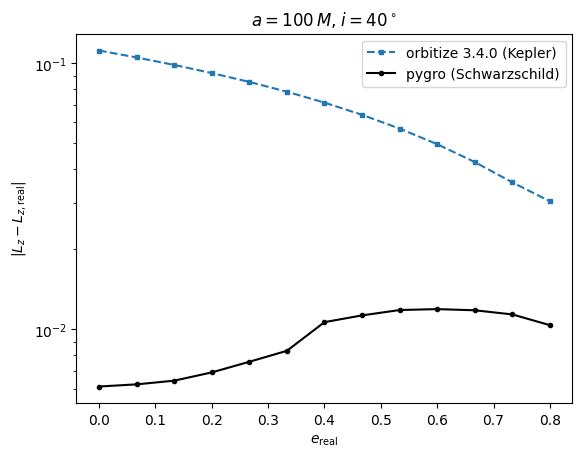

,e_real,Schwarzschild (pygro),Kepler (orbitize)
0,0.000000,0.006104,0.111760
1,0.066667,0.006219,0.105252
2,0.133333,0.006421,0.098656
3,0.200000,0.006896,0.091965
4,0.266667,0.007561,0.085167
5,0.333333,0.008314,0.078252
6,0.400000,0.010654,0.071216
7,0.466667,0.011296,0.064075
8,0.533333,0.011832,0.056880
9,0.600000,0.011925,0.049692


In [83]:
# Barrido en excentricidad

ecc_schw_values = np.linspace(0, 0.8, 13)

with multiprocessing.get_context('fork').Pool() as pool:
    results_e_schw = np.array(pool.map(
        sweep_point, [(a_schw, e, inclination_schw) for e in ecc_schw_values]
    ))

Lz_real_e_schw, Lz_relativistic_e_schw, Lz_newtonian_e_schw = results_e_schw.T
difference_relativistic_e = np.abs(Lz_relativistic_e_schw - Lz_real_e_schw)
difference_newtonian_e = np.abs(Lz_newtonian_e_schw - Lz_real_e_schw)

comparison_e_schw = pd.DataFrame(
    {
        'e_real': ecc_schw_values,
        'Schwarzschild (pygro)': difference_relativistic_e,
        'Kepler (orbitize)': difference_newtonian_e,
    }
)

fig, ax = plt.subplots()
ax.plot(ecc_schw_values, difference_newtonian_e, 's--', markersize=3, color='tab:blue', label='orbitize 3.4.0 (Kepler)')
ax.plot(ecc_schw_values, difference_relativistic_e, 'o-', markersize=3, color='k', label='pygro (Schwarzschild)')
ax.set_yscale('log')
ax.set_xlabel(r'$e_{\mathrm{real}}$')
ax.set_ylabel(r'$|L_z - L_{z,\mathrm{real}}|$')
ax.set_title(rf'$a = {a_schw:.0f}\,M$, $i = {np.rad2deg(inclination_schw):.0f}^\circ$')
ax.legend()
plt.show()

comparison_e_schw

## Barrido en inclinación

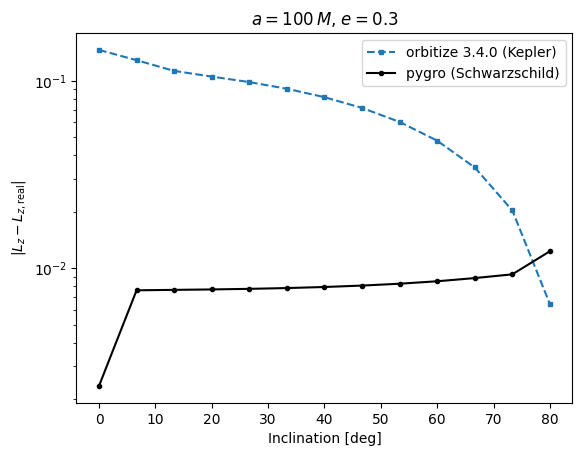

,inclination_deg,Schwarzschild (pygro),Kepler (orbitize)
0,0.000000,0.002353,0.146044
1,6.666667,0.007617,0.128705
2,13.333333,0.007658,0.112859
3,20.000000,0.007698,0.105241
4,26.666667,0.007754,0.098354
5,33.333333,0.007830,0.090624
6,40.000000,0.007934,0.081725
7,46.666667,0.008072,0.071603
8,53.333333,0.008260,0.060295
9,60.000000,0.008512,0.047870


In [84]:
# Barrido en inclinacion

inclination_schw_values = np.deg2rad(np.linspace(0, 80, 13))

with multiprocessing.get_context('fork').Pool() as pool:
    results_i_schw = np.array(pool.map(
        sweep_point, [(a_schw, ecc_schw, i) for i in inclination_schw_values]
    ))

Lz_real_i_schw, Lz_relativistic_i_schw, Lz_newtonian_i_schw = results_i_schw.T
difference_relativistic_i = np.abs(Lz_relativistic_i_schw - Lz_real_i_schw)
difference_newtonian_i = np.abs(Lz_newtonian_i_schw - Lz_real_i_schw)

comparison_i_schw = pd.DataFrame(
    {
        'inclination_deg': np.rad2deg(inclination_schw_values),
        'Schwarzschild (pygro)': difference_relativistic_i,
        'Kepler (orbitize)': difference_newtonian_i,
    }
)

fig, ax = plt.subplots()
ax.plot(np.rad2deg(inclination_schw_values), difference_newtonian_i, 's--', markersize=3, color='tab:blue', label='orbitize 3.4.0 (Kepler)')
ax.plot(np.rad2deg(inclination_schw_values), difference_relativistic_i, 'o-', markersize=3, color='k', label='pygro (Schwarzschild)')
ax.set_yscale('log')
ax.set_xlabel('Inclination [deg]')
ax.set_ylabel(r'$|L_z - L_{z,\mathrm{real}}|$')
ax.set_title(rf'$a = {a_schw:.0f}\,M$, $e = {ecc_schw}$')
ax.legend()
plt.show()

comparison_i_schw